# 01 — Ispezione dataset Emerging Jets (HDF5)

**Obiettivo del notebook:** fare la prima "fotografia" del dataset HDF5 fornito da ATLAS.
Capire la struttura, le shape, i dtype, vedere qualche valore concreto e calcolare statistiche di base sulle feature critiche.

**Cosa NON fa** (lo faremo nei notebook successivi):
- non disegna istogrammi (lo faremo in `02_eda_distribuzioni.ipynb`)
- non applica nessuna trasformazione ai dati
- non salva nulla su disco

**Pipeline** (8 sezioni):
1. Apertura del file e mappatura della struttura
2. Lettura degli attributi/metadata
3. Preview dei `jets`
4. Preview dei `tracks`
5. Statistiche di base sulle feature di jet
6. Verifica della maschera `valid` sulle tracce
7. Conteggio delle label (QCD vs EJ)
8. Statistiche sulle feature di traccia piu critiche

## 0. Setup

Importiamo le librerie e definiamo i parametri.

In [107]:
import subprocess
subprocess.run(["pip", "install", "h5py"])

CompletedProcess(args=['pip', 'install', 'h5py'], returncode=0)

In [108]:
import os
import numpy as np
import h5py

# Mostra tutto senza troncamenti quando stampiamo array piccoli
np.set_printoptions(precision=4, suppress=True, linewidth=120)

In [109]:
import os, platform, subprocess

print("Sistema:", platform.system(), platform.release())
print("Cartella corrente:", os.getcwd())
print()
print("Contenuto della cartella corrente:")
for item in sorted(os.listdir(".")):
    full = os.path.join(os.getcwd(), item)
    print(f"  [{'D' if os.path.isdir(full) else 'F'}] {item}")

print()
print("Vediamo se /mnt/c esiste (sintomo di WSL):")
print("  /mnt/c esiste:", os.path.exists("/mnt/c"))
if os.path.exists("/mnt/c/Users/delco/Desktop"):
    print("  Desktop trovato!")
    print("  Contenuto Desktop:")
    for x in sorted(os.listdir("/mnt/c/Users/delco/Desktop"))[:20]:
        print(f"    {x}")

Sistema: Windows 11
Cartella corrente: c:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs

Contenuto della cartella corrente:
  [D] .claude
  [D] .git
  [F] .gitignore
  [D] .venv
  [F] 00_cumulative.ipynb
  [F] 00_preprocessing_unificato.ipynb
  [F] 00_preprocessing_unificato_profiling.ipynb
  [F] 01_inspect_h5.ipynb
  [F] 02_eda_distribuzioni.ipynb
  [F] 03_cleaning.ipynb
  [F] 04_pytorch_dataset.ipynb
  [F] 04_pytorch_dataset_corr.ipynb
  [F] 05_normalizzazione.ipynb
  [F] README.md
  [F] autoencoder_mimal.ipynb
  [F] class_dict.yaml
  [D] cleaning_out
  [F] ejs_test.yaml
  [F] ejs_train.yaml
  [F] ejs_val.yaml
  [D] figs
  [F] norm_before_after.png
  [F] norm_dict.yaml
  [F] norm_stats.npz
  [F] pp_output_test_background.h5
  [F] pp_output_test_signal.h5
  [F] pp_output_val.h5
  [D] preprocessed
  [F] preprocessing.ipynb
  [F] requirements.txt

Vediamo se /mnt/c esiste (sintomo di WSL):
  /mnt/c esiste: False


In [110]:
# --- CONFIG -----------------------------------------------------------
# Partiamo dal file piu piccolo (signal di test, ~510 MB) per andare veloci.
# Per esplorare il file di validation cambia il path.
FILE_PATH = r"C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_signal.h5"
#FILE_PATH = "/mnt/c/Users/delco/Desktop/Università/Ad_M/dataset/pp_output_test_signal.h5"

N_PREVIEW = 5             # righe da mostrare in preview
N_SAMPLE  = 200_000       # n. jets da usare per statistiche (None = tutti)

# Verifica che il file esista
assert os.path.exists(FILE_PATH), f"File non trovato: {FILE_PATH}"
print(f"File: {FILE_PATH}")
print(f"Dimensione: {os.path.getsize(FILE_PATH)/1e9:.2f} GB")

File: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_signal.h5
Dimensione: 0.51 GB


## 1. Struttura del file

Un file HDF5 e organizzato come un filesystem gerarchico: contiene **gruppi** (cartelle) e **dataset** (tensori). Vediamo cosa c'e dentro.

In [111]:
f = h5py.File(FILE_PATH, "r")   # NB: lo lasciamo aperto per tutto il notebook

def visit(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"  [GROUP]   {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"  [DATASET] {name:30s} shape={obj.shape}  dtype={obj.dtype}")

print("STRUTTURA DEL FILE")
print("-" * 70)
f.visititems(visit)

STRUTTURA DEL FILE
----------------------------------------------------------------------
  [DATASET] jets                           shape=(61966,)  dtype=[('pt', '<f4'), ('eta', '<f4'), ('energy', '<f4'), ('mass', '<f4'), ('salt_pdisp', '<f4'), ('displacedPtFraction', '<f4'), ('Qw_clusterSoftDrop', '<f4'), ('C2_clusterSoftDrop', '<f4'), ('D2_clusterSoftDrop', '<f4'), ('Tau1_clusterSoftDrop', '<f4'), ('Tau2_clusterSoftDrop', '<f4'), ('Tau3_clusterSoftDrop', '<f4'), ('Tau4_clusterSoftDrop', '<f4'), ('Tau21_clusterSoftDrop', '<f4'), ('Tau32_clusterSoftDrop', '<f4'), ('ECF1_clusterSoftDrop', '<f4'), ('ECF2_clusterSoftDrop', '<f4'), ('ECF3_clusterSoftDrop', '<f4'), ('ECF4_clusterSoftDrop', '<f4'), ('Split12_clusterSoftDrop', '<f4'), ('Split23_clusterSoftDrop', '<f4'), ('Split34_clusterSoftDrop', '<f4'), ('timing_clusterSoftDrop', '<f4'), ('isTagged', '<i4'), ('isDisplaced', '<i4'), ('mcEventWeight', '<f4'), ('eventNumber', '<i8'), ('averageInteractionsPerCrossing', '<f4'), ('actualInteract

## 2. Attributi (metadata)

In HDF5 i dataset e i gruppi possono avere **attributi** (chiave-valore) che descrivono i dati (unita di misura, autore, versione del preprocessing, ...).

In [112]:
print("Attributi a livello ROOT:")
if len(f.attrs) == 0:
    print("  (nessuno)")
for k, v in f.attrs.items():
    print(f"  {k} = {v}")

for gname in f.keys():
    g = f[gname]
    if hasattr(g, "attrs") and len(g.attrs) > 0:
        print(f"\nAttributi di '{gname}':")
        for k, v in g.attrs.items():
            print(f"  {k} = {v}")

Attributi a livello ROOT:
  (nessuno)


## 3. Preview dei `jets`

Stampiamo le prime `N_PREVIEW` righe del dataset `jets`. Se e uno *structured array* (con campi nominati tipo `pt`, `eta`, ...) lo stampiamo in modo leggibile riga per riga.

In [113]:
jets = f["jets"]
print(f"Dataset 'jets': shape={jets.shape}, dtype={jets.dtype}")
field_names = jets.dtype.names
print(f"Campi disponibili: {field_names}")

Dataset 'jets': shape=(61966,), dtype=[('pt', '<f4'), ('eta', '<f4'), ('energy', '<f4'), ('mass', '<f4'), ('salt_pdisp', '<f4'), ('displacedPtFraction', '<f4'), ('Qw_clusterSoftDrop', '<f4'), ('C2_clusterSoftDrop', '<f4'), ('D2_clusterSoftDrop', '<f4'), ('Tau1_clusterSoftDrop', '<f4'), ('Tau2_clusterSoftDrop', '<f4'), ('Tau3_clusterSoftDrop', '<f4'), ('Tau4_clusterSoftDrop', '<f4'), ('Tau21_clusterSoftDrop', '<f4'), ('Tau32_clusterSoftDrop', '<f4'), ('ECF1_clusterSoftDrop', '<f4'), ('ECF2_clusterSoftDrop', '<f4'), ('ECF3_clusterSoftDrop', '<f4'), ('ECF4_clusterSoftDrop', '<f4'), ('Split12_clusterSoftDrop', '<f4'), ('Split23_clusterSoftDrop', '<f4'), ('Split34_clusterSoftDrop', '<f4'), ('timing_clusterSoftDrop', '<f4'), ('isTagged', '<i4'), ('isDisplaced', '<i4'), ('mcEventWeight', '<f4'), ('eventNumber', '<i8'), ('averageInteractionsPerCrossing', '<f4'), ('actualInteractionsPerCrossing', '<f4'), ('nPrimaryVertices', '<i4'), ('isRun3', 'i1')]
Campi disponibili: ('pt', 'eta', 'energy', '

In [114]:
preview = jets[:N_PREVIEW]
if field_names:
    for i, row in enumerate(preview):
        print(f"--- jet {i} ---")
        for name in field_names:
            print(f"  {name:30s} = {row[name]}")
else:
    print(preview)

--- jet 0 ---
  pt                             = 391629.6875
  eta                            = 1.1941876411437988
  energy                         = 711230.1875
  mass                           = 88660.3671875
  salt_pdisp                     = 1.0
  displacedPtFraction            = 0.9661736488342285
  Qw_clusterSoftDrop             = 35867.60546875
  C2_clusterSoftDrop             = 0.22978074848651886
  D2_clusterSoftDrop             = 1.7265828847885132
  Tau1_clusterSoftDrop           = 0.18716448545455933
  Tau2_clusterSoftDrop           = 0.11527643352746964
  Tau3_clusterSoftDrop           = 0.06391561776399612
  Tau4_clusterSoftDrop           = 0.04038872569799423
  Tau21_clusterSoftDrop          = 0.61590975522995
  Tau32_clusterSoftDrop          = 0.5544552206993103
  ECF1_clusterSoftDrop           = 399034.9375
  ECF2_clusterSoftDrop           = 21190834176.0
  ECF3_clusterSoftDrop           = 258582314483712.0
  ECF4_clusterSoftDrop           = 9.237531135280415e+17
  Spl

## 4. Preview dei `tracks`

Le tracce sono organizzate in un array 2D: `(N_jets, N_tracks_max)` con padding. Vediamo le prime 5 tracce del primo jet.

In [115]:
tracks = f["tracks"]
print(f"Dataset 'tracks': shape={tracks.shape}, dtype={tracks.dtype}")
track_fields = tracks.dtype.names
print(f"Numero di feature per traccia: {len(track_fields) if track_fields else 'array semplice'}")
print(f"Campi: {track_fields}")

Dataset 'tracks': shape=(61966, 200), dtype=[('numberOfInnermostPixelLayerHits', 'u1'), ('numberOfPixelHits', 'u1'), ('numberOfPixelHoles', 'u1'), ('numberOfPixelSharedHits', 'u1'), ('numberOfSCTHits', 'u1'), ('numberOfSCTHoles', 'u1'), ('numberOfSCTSharedHits', 'u1'), ('truthOriginLabel', '<i4'), ('truthVertexIndex', '<i4'), ('VSIVertexIndex', '<i4'), ('numberDoF', '<f2'), ('theta', '<f2'), ('qOverP', '<f4'), ('chiSquared', '<f4'), ('radiusOfFirstHit', '<f4'), ('pt_log1p', '<f4'), ('d0_log1p', '<f4'), ('pt', '<f4'), ('deta', '<f4'), ('z0RelativeToBeamspot', '<f4'), ('qOverPUncertainty', '<f4'), ('d0', '<f2'), ('z0SinTheta', '<f2'), ('eta', '<f2'), ('d0Uncertainty', '<f2'), ('z0SinThetaUncertainty', '<f2'), ('phiUncertainty', '<f2'), ('thetaUncertainty', '<f2'), ('dphi', '<f2'), ('dr', '<f2'), ('ptfrac', '<f2'), ('z0RelativeToBeamspotUncertainty', '<f2'), ('IP3D_signed_d0', '<f2'), ('IP2D_signed_d0', '<f2'), ('IP3D_signed_z0', '<f2'), ('IP3D_signed_d0_significance', '<f2'), ('IP3D_sign

In [116]:
# Prime 5 tracce del primo jet
if tracks.ndim == 2:
    first_jet_tracks = tracks[0, :5]
else:
    first_jet_tracks = tracks[:5]

if track_fields:
    for i, row in enumerate(first_jet_tracks):
        print(f"--- track {i} del primo jet ---")
        for name in track_fields:
            print(f"  {name:35s} = {row[name]}")
else:
    print(first_jet_tracks)

--- track 0 del primo jet ---
  numberOfInnermostPixelLayerHits     = 0
  numberOfPixelHits                   = 1
  numberOfPixelHoles                  = 0
  numberOfPixelSharedHits             = 0
  numberOfSCTHits                     = 8
  numberOfSCTHoles                    = 0
  numberOfSCTSharedHits               = 0
  truthOriginLabel                    = 8
  truthVertexIndex                    = 1
  VSIVertexIndex                      = -2
  numberDoF                           = 33.0
  theta                               = 0.88037109375
  qOverP                              = -0.00024995143758133054
  chiSquared                          = 28.760211944580078
  radiusOfFirstHit                    = 124.29618835449219
  pt_log1p                            = 8.034462928771973
  d0_log1p                            = 4.058089256286621
  pt                                  = 3084.4814453125
  deta                                = -0.44129636883735657
  z0RelativeToBeamspot             

## 5. Statistiche di base sui jets

Per ogni feature numerica dei jet (sample da `N_SAMPLE` esempi) calcoliamo:
- min, max, mean, std
- frazione di NaN e Inf (red flag se diversa da 0%)

In [117]:
n_jets_total = jets.shape[0]
n_sample = min(N_SAMPLE, n_jets_total) if N_SAMPLE else n_jets_total
print(f"N jet totali nel file: {n_jets_total}")
print(f"Sample usato: {n_sample}")

jets_sample = jets[:n_sample]

N jet totali nel file: 61966
Sample usato: 61966


In [118]:
print(f"{'feature':30s} {'min':>10s} {'max':>10s} {'mean':>10s} {'std':>10s}  NaN%   Inf%")
print("-" * 90)
for name in field_names:
    arr = jets_sample[name]
    if not np.issubdtype(arr.dtype, np.number):
        print(f"{name:30s}  (non numerica, dtype={arr.dtype})")
        continue
    nan_frac = np.isnan(arr).mean() if np.issubdtype(arr.dtype, np.floating) else 0.0
    inf_frac = np.isinf(arr).mean() if np.issubdtype(arr.dtype, np.floating) else 0.0
    print(f"{name:30s} {arr.min():10.3g} {arr.max():10.3g} "
          f"{arr.mean():10.3g} {arr.std():10.3g}  "
          f"{nan_frac:5.2%}  {inf_frac:5.2%}")

feature                               min        max       mean        std  NaN%   Inf%
------------------------------------------------------------------------------------------
pt                                  2e+05   1.62e+06   4.54e+05   1.48e+05  0.00%  0.00%
eta                                  -2.5        2.5    0.00863      0.996  0.00%  0.00%


energy                           2.05e+05   3.76e+06   7.25e+05    3.5e+05  0.00%  0.00%
mass                                  765   7.04e+05   1.59e+05   6.62e+04  0.00%  0.00%
salt_pdisp                       1.67e-05          1       0.96      0.181  0.00%  0.00%
displacedPtFraction                     0        5.6        1.2      0.427  0.00%  0.00%
Qw_clusterSoftDrop                      0      3e+05   6.68e+04   3.51e+04  0.00%  0.00%
C2_clusterSoftDrop                   -999      0.647     -0.423       27.2  0.00%  0.00%
D2_clusterSoftDrop                   -999       9.99       1.01       27.3  0.00%  0.00%
Tau1_clusterSoftDrop                    0      0.934      0.278      0.134  0.00%  0.00%
Tau2_clusterSoftDrop                    0      0.536      0.174     0.0864  0.00%  0.00%
Tau3_clusterSoftDrop                    0      0.388      0.125     0.0666  0.00%  0.00%
Tau4_clusterSoftDrop                    0      0.316     0.0974     0.0546  0.00%  0.00%
Tau21_clusterSoftDrop

## 6. Maschera `valid` sulle tracce

Nel dataset ogni jet ha fino a `N_tracks_max` tracce, ma la maggior parte sono **padding**. Il campo `valid` (booleano) dice quali tracce sono reali. Vediamo la distribuzione del numero di tracce reali per jet.

In [119]:
if "valid" in track_fields:
    valid_sample = tracks["valid"][:n_sample]   # (n_sample, N_tracks_max)
    n_valid_per_jet = valid_sample.sum(axis=1)
    
    print(f"Padding (tracce max per jet): {tracks.shape[1]}")
    print(f"Tracce valide per jet:")
    print(f"  min     = {n_valid_per_jet.min()}")
    print(f"  max     = {n_valid_per_jet.max()}")
    print(f"  mean    = {n_valid_per_jet.mean():.1f}")
    print(f"  median  = {np.median(n_valid_per_jet):.0f}")
    print(f"  P95     = {np.percentile(n_valid_per_jet, 95):.0f}")
    print(f"  P99     = {np.percentile(n_valid_per_jet, 99):.0f}")
    print()
    print(f"Jet con 0 tracce valide: {(n_valid_per_jet == 0).sum()} "
          f"({(n_valid_per_jet == 0).mean():.2%})")
else:
    print("Campo 'valid' non trovato nel gruppo tracks")

Padding (tracce max per jet): 200
Tracce valide per jet:
  min     = 0
  max     = 200
  mean    = 50.4
  median  = 46
  P95     = 96
  P99     = 125

Jet con 0 tracce valide: 1 (0.00%)


## 7. Bilanciamento delle label

Contiamo quanti jet QCD (label 0) e quanti EJ (label 1) ci sono nel file. Le label da controllare sono `isDisplaced` e `flavour_label`.

In [120]:
for lab in ["isDisplaced", "flavour_label"]:
    if lab in field_names:
        arr = jets_sample[lab]
        vals, counts = np.unique(arr, return_counts=True)
        print(f"Label '{lab}':")
        for v, c in zip(vals, counts):
            print(f"  {v}: {c}  ({c/len(arr):.2%})")
        print()
    else:
        print(f"Label '{lab}' non presente nel dataset 'jets'")

Label 'isDisplaced':
  0: 2322  (3.75%)
  1: 59644  (96.25%)

Label 'flavour_label' non presente nel dataset 'jets'


## 8. Statistiche sulle feature di traccia critiche

Per le 8 feature di traccia piu importanti calcoliamo statistiche **solo sulle tracce valide** (non sul padding). Includiamo anche i percentili 1% e 99% per vedere quanto sono "estreme" le code.

In [121]:
CRITICAL_TRACK_FEATURES = [
    "d0",
    "z0SinTheta",
    "qOverP",
    "pt",
    "IP3D_signed_d0_significance",
    "numberOfInnermostPixelLayerHits",
    "pt_log1p",
    "d0_log1p",
]

N_TRACK_SAMPLE = min(20_000, n_jets_total)
print(f"Sample: primi {N_TRACK_SAMPLE} jets (~ {N_TRACK_SAMPLE * tracks.shape[1]:.0e} tracce con padding)")
print()

tracks_sample = tracks[:N_TRACK_SAMPLE]
valid_mask = tracks_sample["valid"].astype(bool) if "valid" in track_fields else None

Sample: primi 20000 jets (~ 4e+06 tracce con padding)



In [122]:
print(f"{'feature':40s} {'min':>10s} {'max':>10s} {'p1':>10s} {'p99':>10s} {'mean':>10s} {'std':>10s}")
print("-" * 100)
for name in CRITICAL_TRACK_FEATURES:
    if name not in track_fields:
        print(f"{name:40s}  (non presente)")
        continue
    arr = tracks_sample[name]
    if valid_mask is not None:
        arr = arr[valid_mask]
    if np.issubdtype(arr.dtype, np.floating):
        arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        print(f"{name:40s}  (vuoto)")
        continue
    p1, p99 = np.percentile(arr, [1, 99])
    print(f"{name:40s} {arr.min():10.3g} {arr.max():10.3g} "
          f"{p1:10.3g} {p99:10.3g} {arr.mean():10.3g} {arr.std():10.3g}")

feature                                         min        max         p1        p99       mean        std
----------------------------------------------------------------------------------------------------
d0                                             -300        300       -201        186     -0.688        inf
z0SinTheta                                     -500        498       -270        271     -0.124        inf
qOverP                                       -0.001      0.001  -0.000907    0.00091   6.03e-06   0.000442
pt                                            1e+03   7.25e+08   1.01e+03   7.01e+04   1.03e+04   8.45e+05
IP3D_signed_d0_significance                -1.5e+04   1.36e+04       -640        719       10.4        inf
numberOfInnermostPixelLayerHits                   0          2          0          2      0.444      0.547
pt_log1p                                       6.91       20.4       6.92       11.2        7.9      0.961
d0_log1p                                   

## Chiusura del file

Importante: HDF5 tiene il file aperto, ricordiamoci sempre di chiuderlo a fine sessione.

In [123]:
f.close()
print("File chiuso.")

File chiuso.


---

## Cosa fare ora con l'output di questo notebook

1. Verifica che le **shape** dei dataset siano coerenti (n. jet uguale in `jets` e `tracks`)
2. Controlla la **distribuzione del numero di tracce per jet**: il P99 ti dice il padding sensato
3. Controlla **NaN e Inf**: se diversi da 0% bisogna gestirli
4. Controlla che `isDisplaced` abbia valori sensati (0 per QCD, 1 per EJ) e che il file di signal contenga effettivamente solo segnale (o anche un po' di QCD per controllo)
5. Confronta le statistiche delle feature di traccia con i valori di `norm_dict.yaml`: devono essere coerenti

Quando hai l'output, condividilo e passiamo al notebook successivo (**02 — distribuzioni e istogrammi**) dove vedremo finalmente la forma vera delle feature.

# 02 — EDA: distribuzioni e confronto QCD vs EJ

**Obiettivo:** disegnare le distribuzioni delle feature di jet e di traccia, sovrapponendo QCD (background) ed Emerging Jets (signal). Validare visivamente le scelte di cleaning che abbiamo deciso nel notebook 01.

**Strategia di caricamento:** carichiamo **50.000 jet per file** (background + signal = 100k totali) per avere statistiche robuste senza sforare i 16 GB di RAM.

**Cosa NON fa** (lo faremo dopo):
- non applica il cleaning vero (questo va in `03_cleaning.ipynb`)
- non scrive il dataset clean su disco
- non costruisce il `Dataset` PyTorch (notebook 04)

**Sezioni:**
1. Setup e caricamento dati
2. Distribuzione del numero di tracce per jet
3. Feature di jet (alto livello)
4. Feature di traccia (basso livello)
5. Correlazioni e scatter plot 2D
6. Diagnostiche speciali (sentinel -999, overflow, outlier)
7. Salvataggio figure

## 0. Setup

Carichiamo le librerie e definiamo lo stile dei plot.

In [124]:
import os
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)  # silenzia warning di overflow durante i plot

# Stile dei plot
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

# Colori standard (sempre gli stessi nel resto del notebook)
COLOR_QCD = '#1f77b4'   # blu
COLOR_EJ  = '#d62728'   # rosso

print('Setup completato.')

Setup completato.


In [125]:
# --- CONFIG ---------------------------------------------------
#PATH_BKG = 'pp_output_test_background.h5'  # QCD
#PATH_SIG = 'pp_output_test_signal.h5'      # Emerging Jets
# --- CONFIG ---------------------------------------------------

#PATH_BKG = ("C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_background.h5")  # QCD
#PATH_SIG = ("C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_signal.h5")      # Emerging Jets
PATH_BKG = r"C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_background.h5"
PATH_SIG = r"C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_signal.h5"

N_SAMPLE = 50_000  # quanti jet caricare per file

FIGS_DIR = Path('figs')
FIGS_DIR.mkdir(exist_ok=True)

assert os.path.exists(PATH_BKG), f'File non trovato: {PATH_BKG}'
assert os.path.exists(PATH_SIG), f'File non trovato: {PATH_SIG}'
print(f'Background: {PATH_BKG} ({os.path.getsize(PATH_BKG)/1e9:.2f} GB)')
print(f'Signal:     {PATH_SIG} ({os.path.getsize(PATH_SIG)/1e9:.2f} GB)')
print(f'Sample per file: {N_SAMPLE:,}')
print(f'Le figure verranno salvate in: {FIGS_DIR.resolve()}')

Background: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_background.h5 (8.93 GB)
Signal:     C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_signal.h5 (0.51 GB)
Sample per file: 50,000
Le figure verranno salvate in: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\figs


## 1. Caricamento dei dati

Carichiamo i primi `N_SAMPLE` jet (e le rispettive tracce) da entrambi i file. Convertiamo a `float32` ovunque per evitare gli overflow di `float16` che abbiamo visto nel notebook 01.

In [126]:
def load_jets_and_tracks(path, n_sample):
    """Carica jets e tracks da un file H5, primi n_sample esempi."""
    with h5py.File(path, 'r') as f:
        n = min(n_sample, f['jets'].shape[0])
        jets = f['jets'][:n]
        tracks = f['tracks'][:n]
    return jets, tracks

print('Caricamento background QCD...')
jets_bkg, tracks_bkg = load_jets_and_tracks(PATH_BKG, N_SAMPLE)
print(f'  jets:   {jets_bkg.shape}')
print(f'  tracks: {tracks_bkg.shape}')

print('\nCaricamento signal EJ...')
jets_sig, tracks_sig = load_jets_and_tracks(PATH_SIG, N_SAMPLE)
print(f'  jets:   {jets_sig.shape}')
print(f'  tracks: {tracks_sig.shape}')

# Memoria usata (approssimativa)
mem_mb = (jets_bkg.nbytes + tracks_bkg.nbytes + jets_sig.nbytes + tracks_sig.nbytes) / 1e6
print(f'\nMemoria totale usata: ~{mem_mb:.0f} MB')

Caricamento background QCD...
  jets:   (50000,)
  tracks: (50000, 200)

Caricamento signal EJ...
  jets:   (50000,)
  tracks: (50000, 200)

Memoria totale usata: ~2213 MB


In [127]:
# Helper: estrae una feature da uno structured array convertendola a float32
# (fondamentale per evitare gli overflow di float16 sui valori grandi)
def get_feat(structured_arr, name):
    """Estrae una feature come array float32."""
    return structured_arr[name].astype(np.float32)

# Maschere booleane delle tracce valide (True dove la traccia esiste)
mask_bkg = tracks_bkg['valid']
mask_sig = tracks_sig['valid']

print(f'Tracce valide BKG: {mask_bkg.sum():,} / {mask_bkg.size:,} '
      f'({mask_bkg.mean():.1%})')
print(f'Tracce valide SIG: {mask_sig.sum():,} / {mask_sig.size:,} '
      f'({mask_sig.mean():.1%})')

Tracce valide BKG: 3,238,940 / 10,000,000 (32.4%)
Tracce valide SIG: 2,560,752 / 10,000,000 (25.6%)


## 2. Distribuzione del numero di tracce per jet

Il numero di tracce per jet e una delle feature piu **discriminanti** tra QCD ed EJ: gli EJ hanno tipicamente piu tracce perche provengono da molti decay vertex displaced.

Questo plot ci dice anche il **padding ottimale** per il modello: se il P99 e ~125, possiamo tagliare a 128 senza perdere informazione.

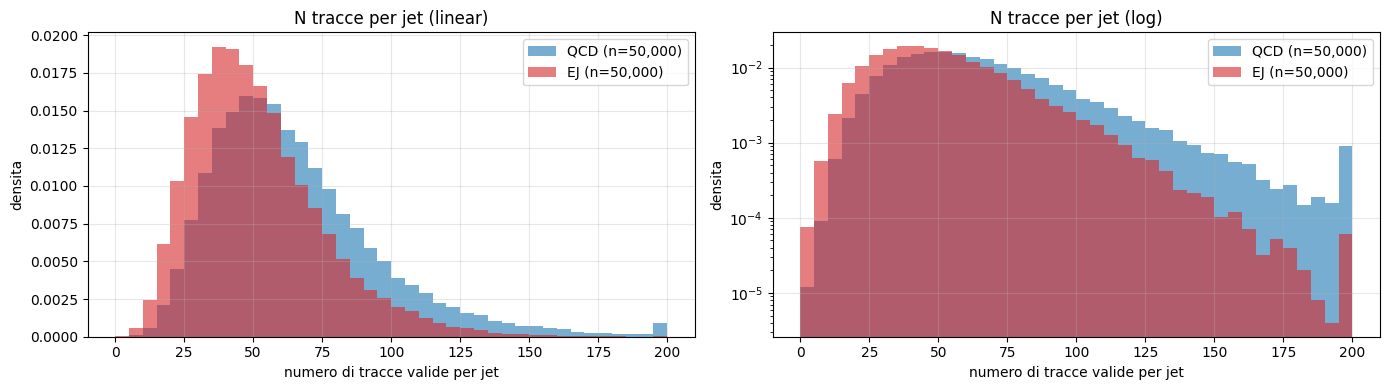


Statistiche QCD:  mean=64.8  median=59  P99=168
Statistiche EJ:   mean=51.2  median=47  P99=126


In [128]:
n_tracks_bkg = mask_bkg.sum(axis=1)
n_tracks_sig = mask_sig.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bins = np.arange(0, 201, 5)
for ax, scale in zip(axes, ['linear', 'log']):
    ax.hist(n_tracks_bkg, bins=bins, alpha=0.6, density=True,
            color=COLOR_QCD, label=f'QCD (n={len(n_tracks_bkg):,})')
    ax.hist(n_tracks_sig, bins=bins, alpha=0.6, density=True,
            color=COLOR_EJ, label=f'EJ (n={len(n_tracks_sig):,})')
    ax.set_xlabel('numero di tracce valide per jet')
    ax.set_ylabel('densita')
    ax.set_yscale(scale)
    ax.set_title(f'N tracce per jet ({scale})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'n_tracks_per_jet.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nStatistiche QCD:  mean={n_tracks_bkg.mean():.1f}  median={np.median(n_tracks_bkg):.0f}  P99={np.percentile(n_tracks_bkg, 99):.0f}')
print(f'Statistiche EJ:   mean={n_tracks_sig.mean():.1f}  median={np.median(n_tracks_sig):.0f}  P99={np.percentile(n_tracks_sig, 99):.0f}')

## 3. Feature di jet (alto livello)

Disegniamo gli istogrammi sovrapposti QCD vs EJ delle feature di jet piu importanti. Definiamo una funzione `compare_hist` che ci permette di farlo in modo uniforme.

In [129]:
def compare_hist(values_bkg, values_sig, name, bins=60, log_y=False,
                 clip=None, save=True, show=True):
    """Disegna istogrammi sovrapposti QCD vs EJ per una feature.
    
    Args:
        values_bkg, values_sig: array delle feature (gia filtrati e float32)
        name: nome della feature (per titolo e file)
        bins: numero di bin o array di bin edges
        log_y: scala log sull'asse y
        clip: tupla (low, high) per clippare gli outlier prima del plot
    """
    bkg = values_bkg[np.isfinite(values_bkg)]
    sig = values_sig[np.isfinite(values_sig)]
    
    if clip is not None:
        bkg = np.clip(bkg, clip[0], clip[1])
        sig = np.clip(sig, clip[0], clip[1])
    
    # range comune basato sui percentili (per non farsi rovinare dagli outlier)
    if isinstance(bins, int):
        combined = np.concatenate([bkg, sig])
        lo, hi = np.percentile(combined, [0.5, 99.5])
        if lo == hi:
            lo, hi = combined.min(), combined.max() + 1
        bins = np.linspace(lo, hi, bins)
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(bkg, bins=bins, alpha=0.6, density=True,
            color=COLOR_QCD, label=f'QCD (n={len(bkg):,})')
    ax.hist(sig, bins=bins, alpha=0.6, density=True,
            color=COLOR_EJ, label=f'EJ  (n={len(sig):,})')
    ax.set_xlabel(name)
    ax.set_ylabel('densita' + (' (log)' if log_y else ''))
    if log_y:
        ax.set_yscale('log')
    ax.set_title(f'Distribuzione {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    if save:
        suffix = '_log' if log_y else ''
        fig.savefig(FIGS_DIR / f'jet_{name}{suffix}.png', dpi=120, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

print('Funzione compare_hist pronta.')

Funzione compare_hist pronta.


### 3.1 Feature cinematiche (pt, eta, mass, energy)

Aspettative: pt ed energy molto simili tra QCD ed EJ (entrambi sono jet di alto pT). Mass piu spostata verso valori piu alti per EJ (jet con sottostruttura).

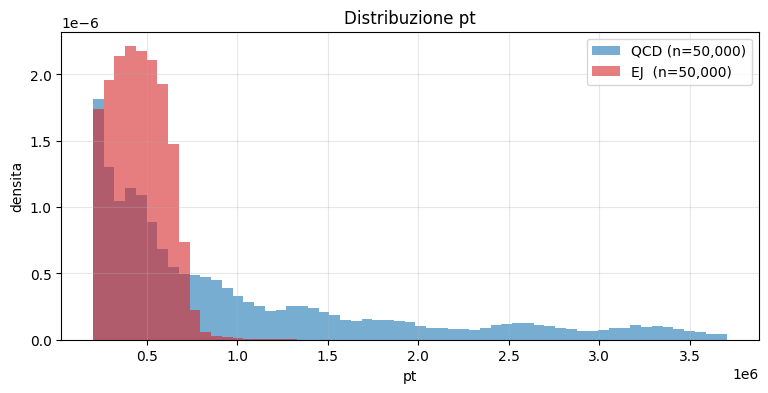

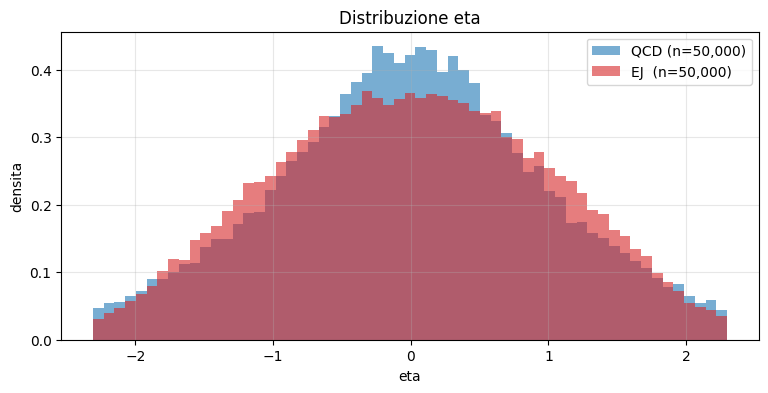

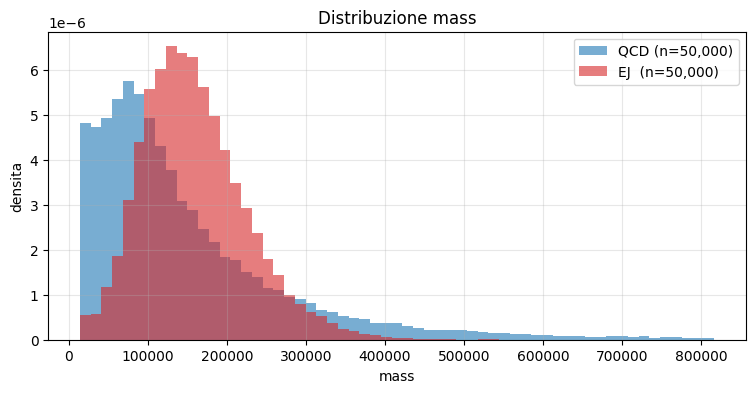

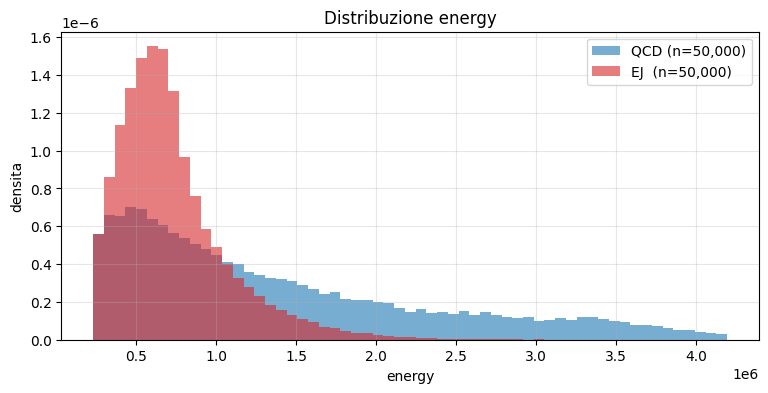

In [130]:
for feat in ['pt', 'eta', 'mass', 'energy']:
    compare_hist(get_feat(jets_bkg, feat), get_feat(jets_sig, feat), feat, bins=60)

### 3.2 Feature 'displaced' di ATLAS

**Aspettative chiave:**
- `displacedPtFraction` molto piu alta per EJ (e proprio la PTF dell'articolo cut-based!). Attenzione: ha max 5.6 → clippiamo a 1.5
- `salt_pdisp` (classificatore SALT gia pre-trained): ~1 per EJ, ~0 per QCD
- `timing_clusterSoftDrop`: gli EJ hanno tracce displaced che possono avere timing diverso

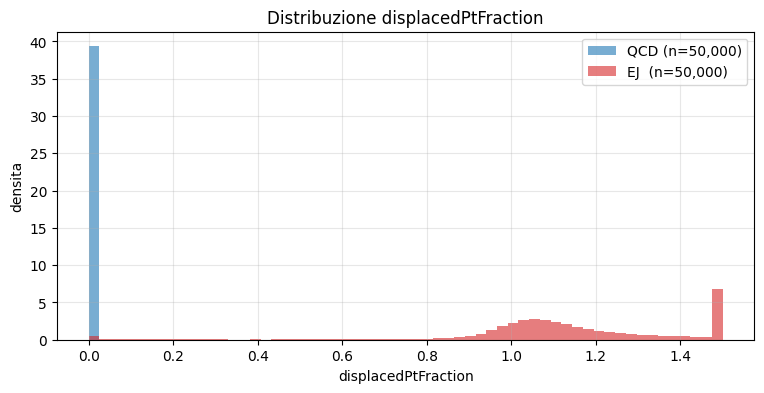

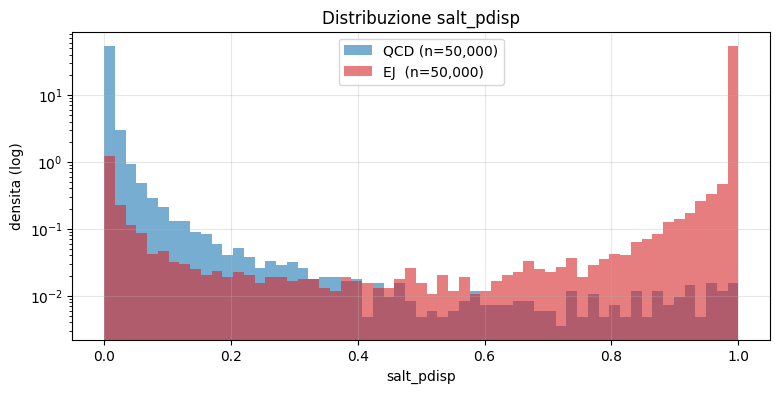

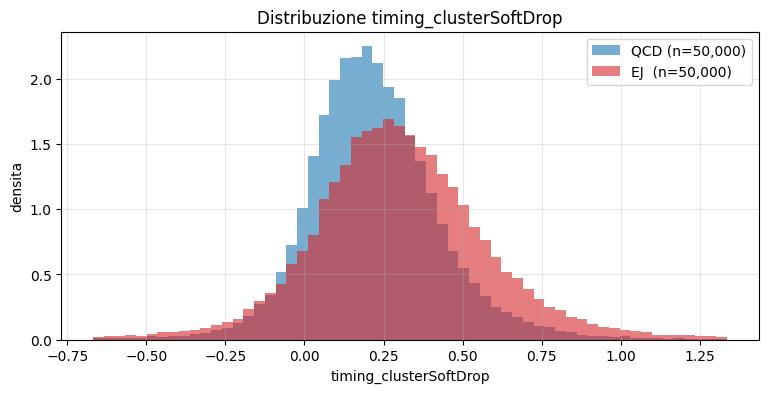

In [131]:
compare_hist(get_feat(jets_bkg, 'displacedPtFraction'),
             get_feat(jets_sig, 'displacedPtFraction'),
             'displacedPtFraction', bins=60, clip=(0, 1.5))

compare_hist(get_feat(jets_bkg, 'salt_pdisp'),
             get_feat(jets_sig, 'salt_pdisp'),
             'salt_pdisp', bins=60, log_y=True)

compare_hist(get_feat(jets_bkg, 'timing_clusterSoftDrop'),
             get_feat(jets_sig, 'timing_clusterSoftDrop'),
             'timing_clusterSoftDrop', bins=60, clip=(-5, 5))

### 3.3 N-subjettiness (Tau) e energy correlations (ECF)

Per Tau21 e Tau32: ricordiamoci che hanno il sentinel -999 (jet senza sottostruttura). Lo filtriamo prima del plot.

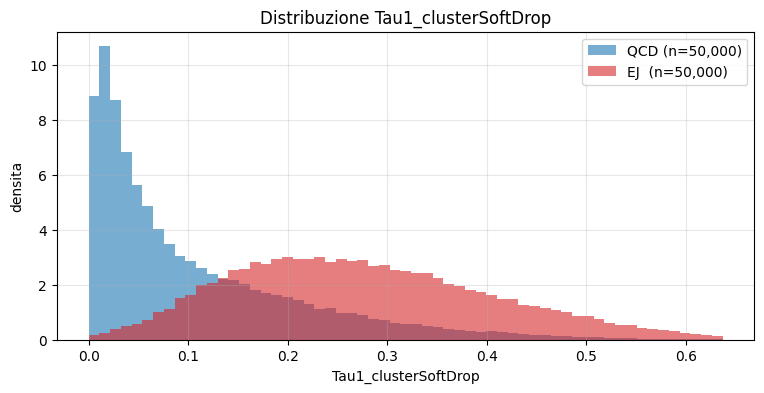

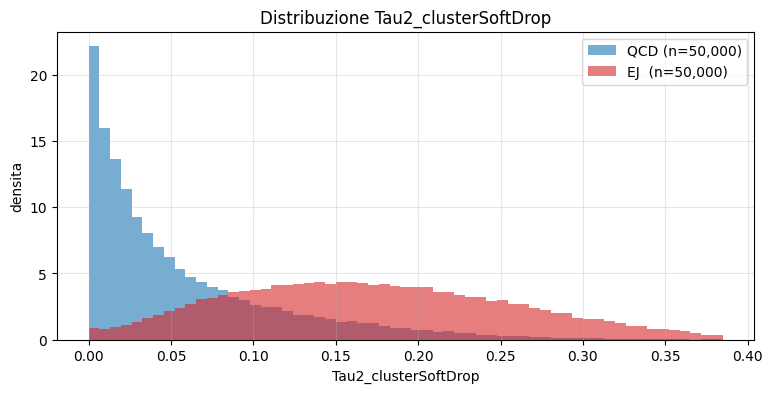

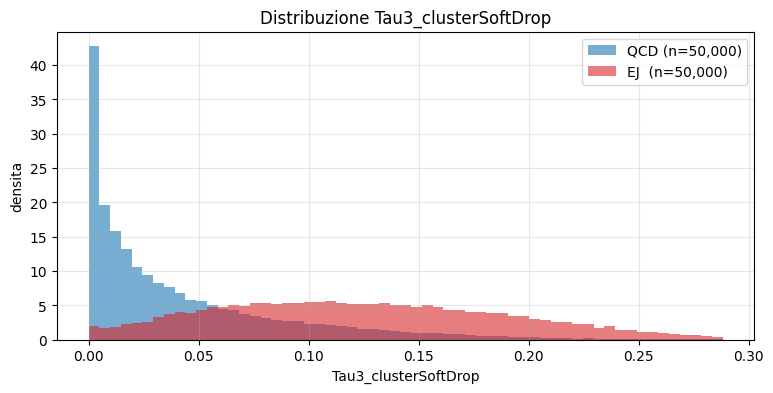

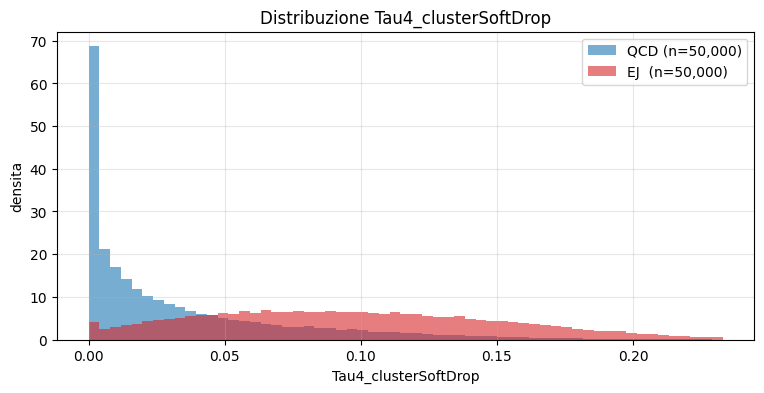

In [132]:
for feat in ['Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop',
             'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop']:
    compare_hist(get_feat(jets_bkg, feat), get_feat(jets_sig, feat), feat, bins=60)

Tau21_clusterSoftDrop: sentinel in QCD = 1.2%, in EJ = 0.1%


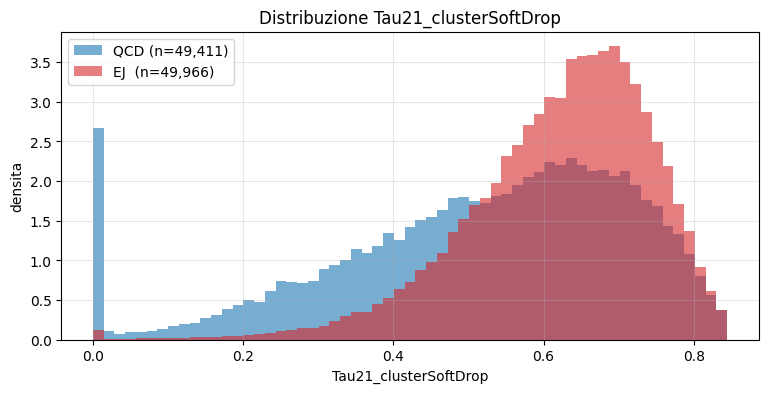

Tau32_clusterSoftDrop: sentinel in QCD = 4.7%, in EJ = 0.2%


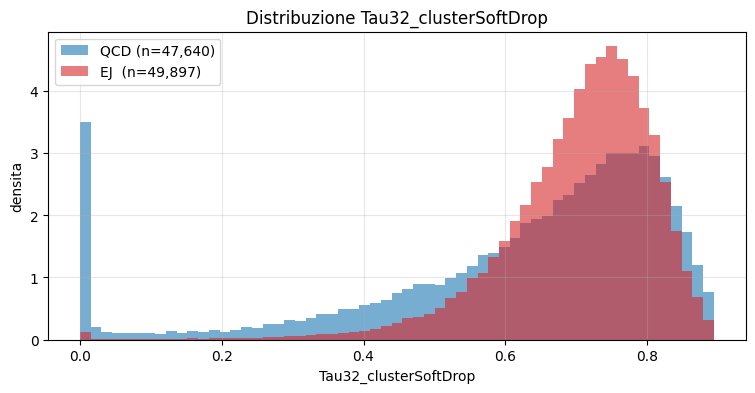

In [133]:
# Tau21 e Tau32 hanno sentinel -999: filtriamo prima del plot
for feat in ['Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop']:
    bkg = get_feat(jets_bkg, feat)
    sig = get_feat(jets_sig, feat)
    bkg_clean = bkg[bkg > -100]   # tutto cio che e > -100 e fisico
    sig_clean = sig[sig > -100]
    print(f'{feat}: sentinel in QCD = {(bkg <= -100).mean():.1%}, in EJ = {(sig <= -100).mean():.1%}')
    compare_hist(bkg_clean, sig_clean, feat, bins=60)

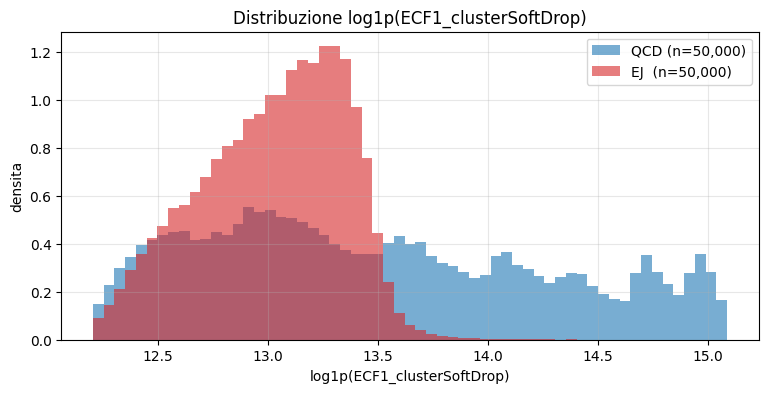

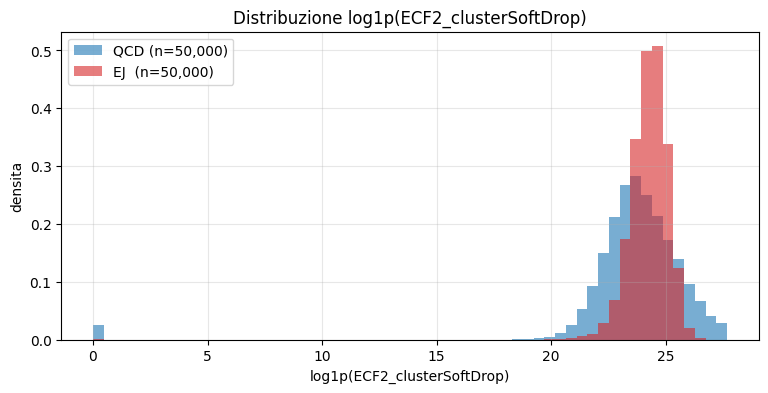

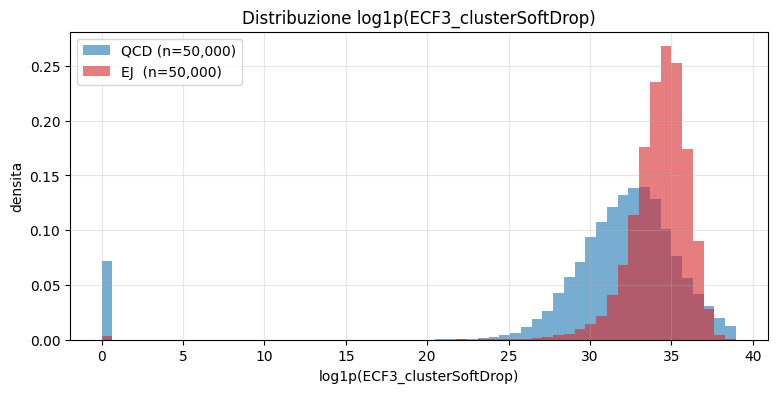

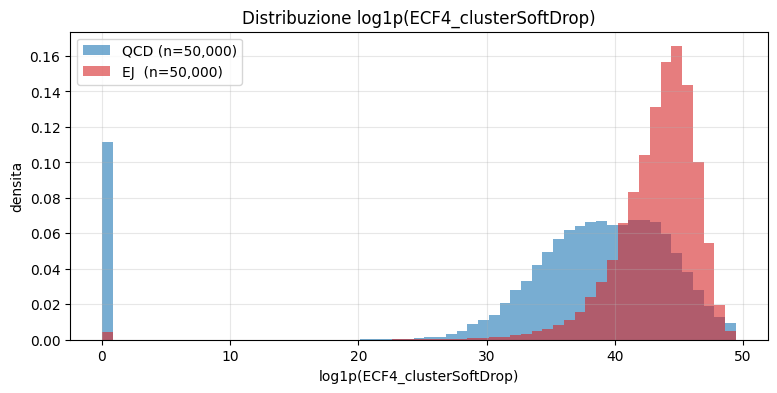

In [134]:
# ECF: hanno range enorme, usiamo log
for feat in ['ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop',
             'ECF3_clusterSoftDrop', 'ECF4_clusterSoftDrop']:
    bkg = get_feat(jets_bkg, feat)
    sig = get_feat(jets_sig, feat)
    # log1p (= log(1+x)) per evitare problemi con 0 e con i valori giganteschi
    bkg_log = np.log1p(np.clip(bkg, 0, None))
    sig_log = np.log1p(np.clip(sig, 0, None))
    compare_hist(bkg_log, sig_log, f'log1p({feat})', bins=60)

C2_clusterSoftDrop: sentinel in QCD = 1.2%, in EJ = 0.1%


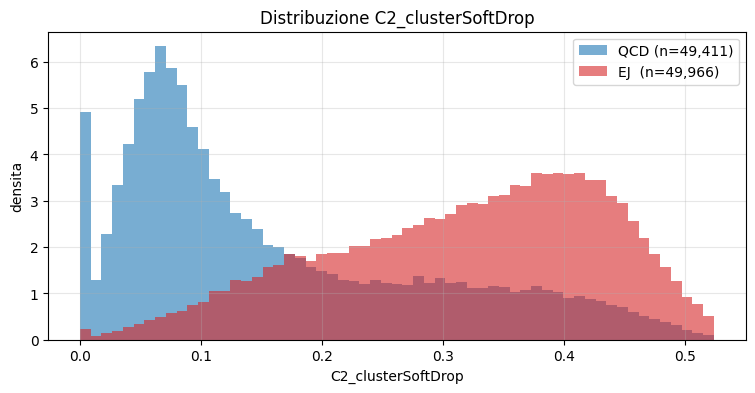

D2_clusterSoftDrop: sentinel in QCD = 1.2%, in EJ = 0.1%


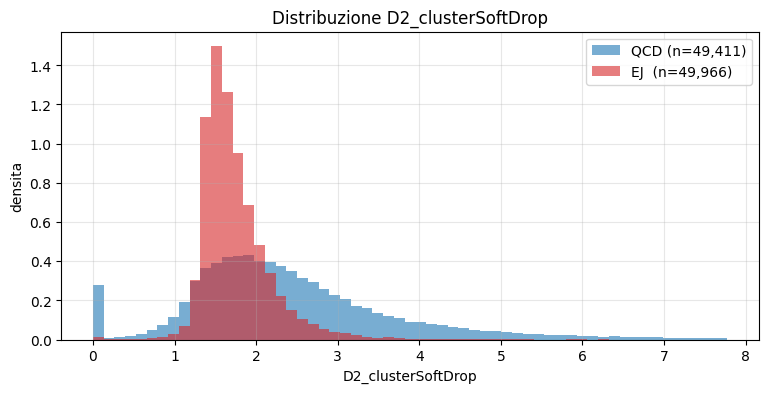

In [135]:
# C2, D2: hanno sentinel -999
for feat in ['C2_clusterSoftDrop', 'D2_clusterSoftDrop']:
    bkg = get_feat(jets_bkg, feat)
    sig = get_feat(jets_sig, feat)
    bkg_clean = bkg[bkg > -100]
    sig_clean = sig[sig > -100]
    print(f'{feat}: sentinel in QCD = {(bkg <= -100).mean():.1%}, in EJ = {(sig <= -100).mean():.1%}')
    compare_hist(bkg_clean, sig_clean, feat, bins=60)

### 3.4 Pile-up e altre feature di contesto

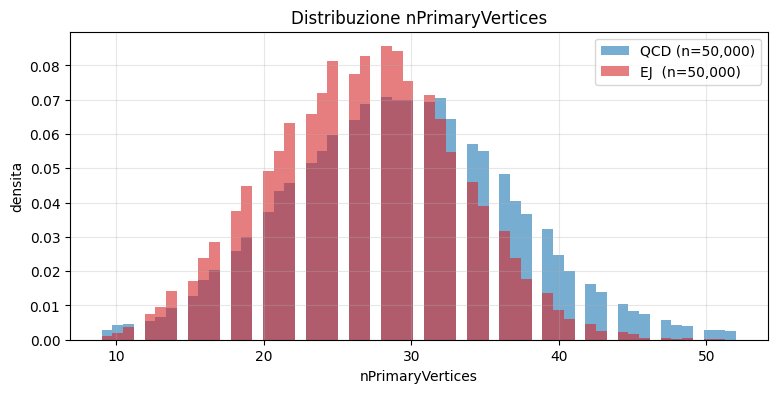

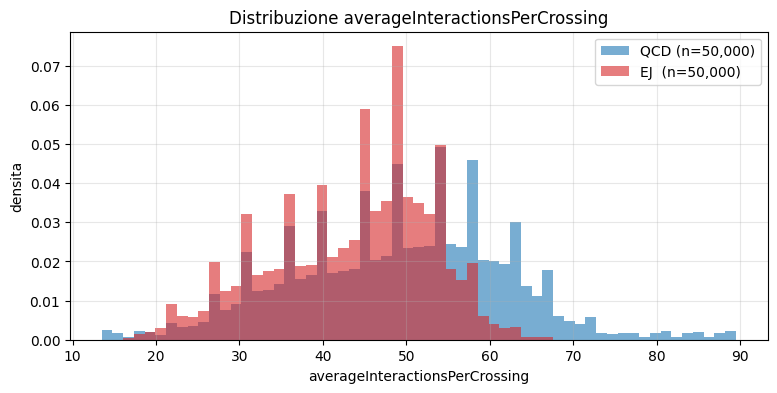

In [136]:
for feat in ['nPrimaryVertices', 'averageInteractionsPerCrossing']:
    compare_hist(get_feat(jets_bkg, feat), get_feat(jets_sig, feat), feat, bins=60)

## 4. Feature di traccia

Per le tracce dobbiamo lavorare **solo sulle tracce valide** (usando la maschera). Definiamo una funzione che estrae una feature da tutte le tracce valide.

In [137]:
def get_track_feat(tracks, mask, name):
    """Estrae una feature di tracce, solo sulle tracce valide."""
    arr = tracks[name][mask].astype(np.float32)
    return arr[np.isfinite(arr)]

def compare_hist_track(name, bins=60, log_y=False, clip=None, transform=None):
    """Helper per istogrammi di tracce."""
    bkg = get_track_feat(tracks_bkg, mask_bkg, name)
    sig = get_track_feat(tracks_sig, mask_sig, name)
    if transform is not None:
        bkg = transform(bkg)
        sig = transform(sig)
        name_disp = f'{transform.__name__}({name})' if hasattr(transform, '__name__') else name
    else:
        name_disp = name
    
    if clip is not None:
        bkg = np.clip(bkg, clip[0], clip[1])
        sig = np.clip(sig, clip[0], clip[1])
    
    if isinstance(bins, int):
        combined = np.concatenate([bkg, sig])
        lo, hi = np.percentile(combined, [0.5, 99.5])
        if lo == hi:
            lo, hi = combined.min(), combined.max() + 1
        bins = np.linspace(lo, hi, bins)
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(bkg, bins=bins, alpha=0.6, density=True, color=COLOR_QCD,
            label=f'QCD (n={len(bkg):,})')
    ax.hist(sig, bins=bins, alpha=0.6, density=True, color=COLOR_EJ,
            label=f'EJ  (n={len(sig):,})')
    ax.set_xlabel(name_disp)
    ax.set_ylabel('densita')
    if log_y:
        ax.set_yscale('log')
    ax.set_title(f'Tracce - distribuzione {name_disp}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.savefig(FIGS_DIR / f'track_{name}.png', dpi=120, bbox_inches='tight')
    plt.show()

print('Funzioni helper pronte.')

Funzioni helper pronte.


### 4.1 Parametri di impatto (i piu importanti!)

**Aspettativa fortissima:** EJ ha tracce con `d0` e `z0` displaced (lontane dal vertice primario), QCD ha tracce prompt. Sono **le feature numero 1 per discriminare**.

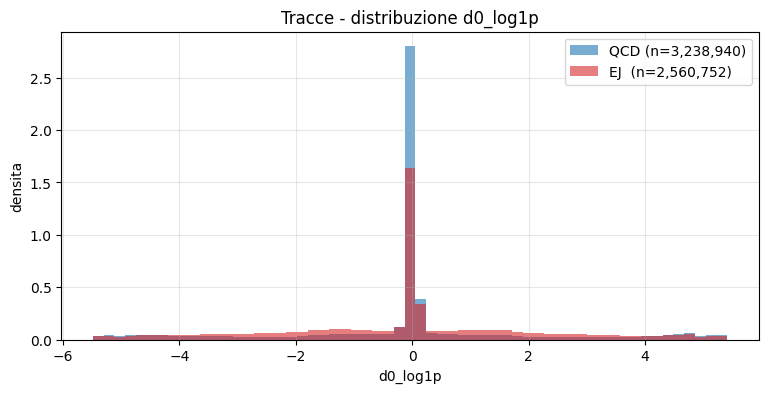

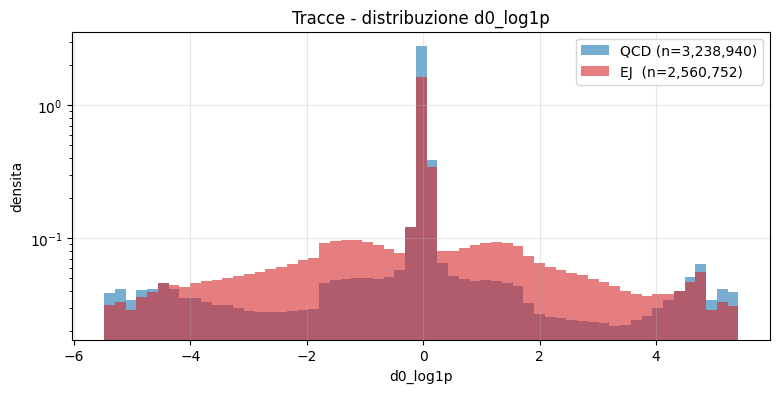

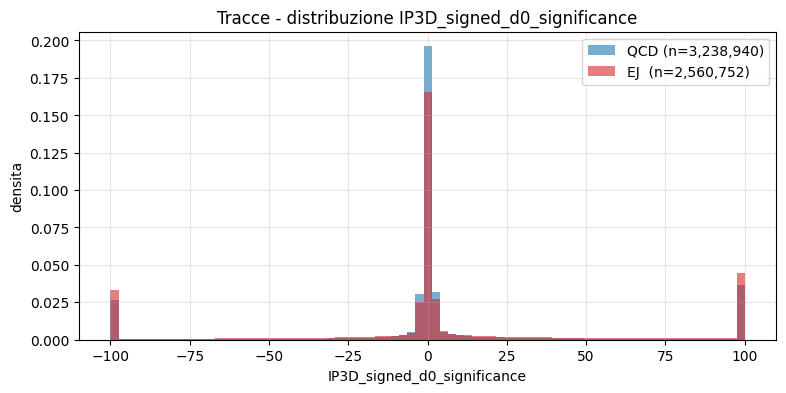

In [138]:
compare_hist_track('d0_log1p', bins=60)
compare_hist_track('d0_log1p', bins=60, log_y=True)
compare_hist_track('IP3D_signed_d0_significance', bins=80, clip=(-100, 100))

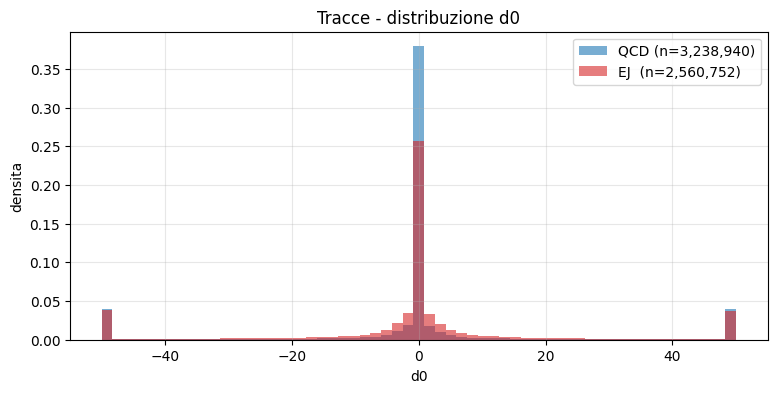

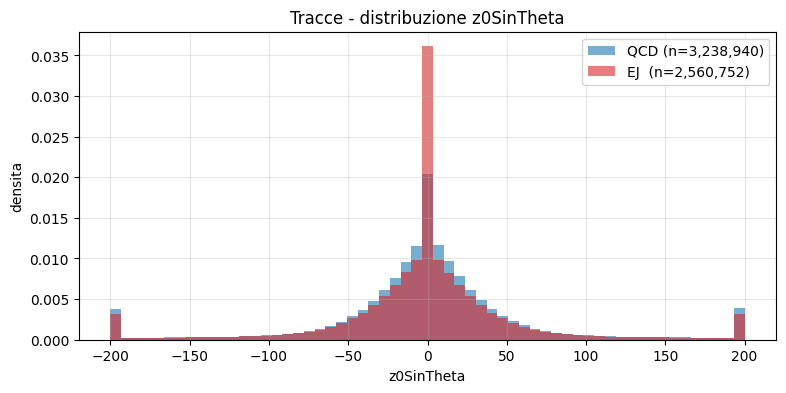

In [139]:
# d0 raw clippato (per visualizzare)
compare_hist_track('d0', bins=60, clip=(-50, 50))
compare_hist_track('z0SinTheta', bins=60, clip=(-200, 200))

### 4.2 Hits nel tracker (PARTICOLARMENTE INFORMATIVI!)

Le tracce displaced **partono dentro al rivelatore**, quindi mancano gli hit nel layer piu interno (IBL). Questa e una delle feature piu predittive.

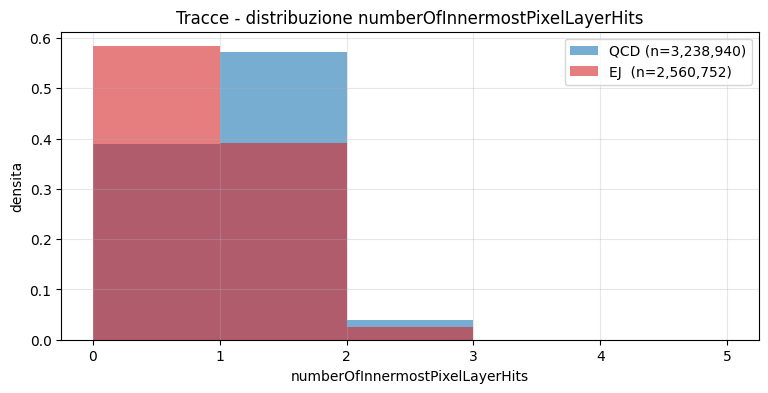

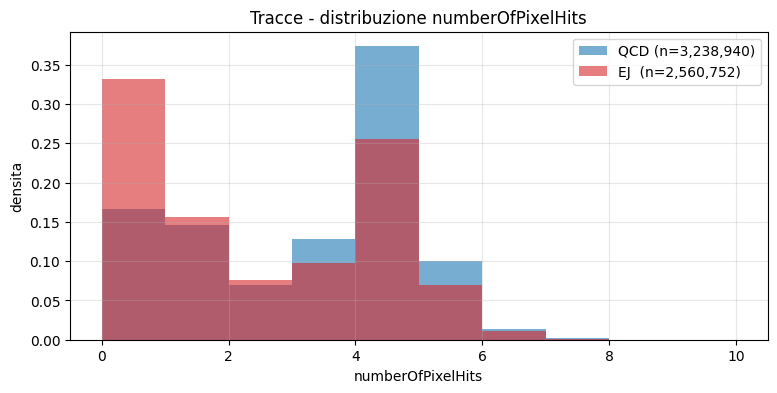

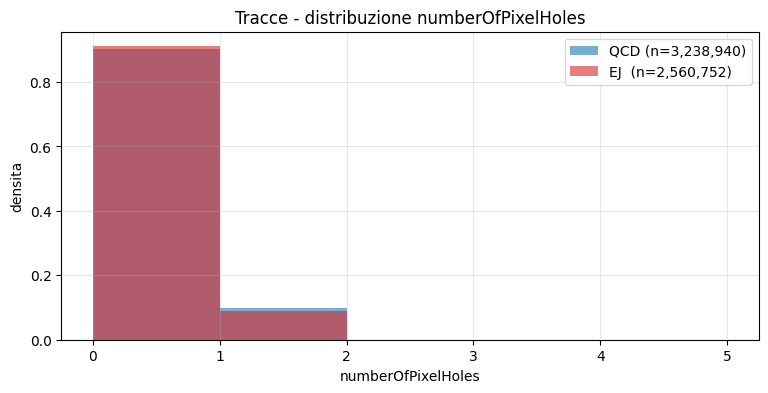

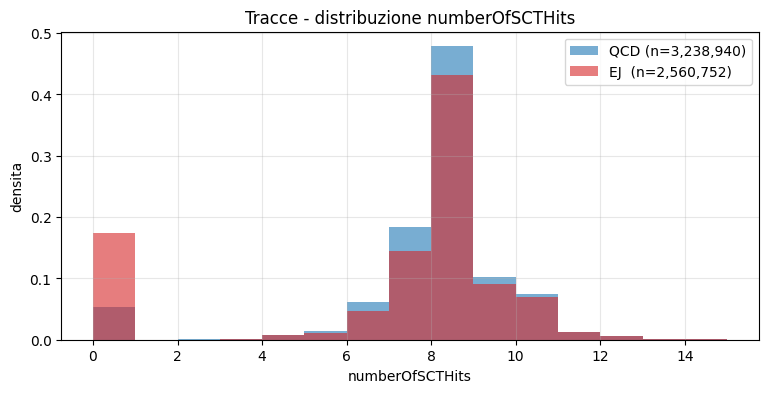

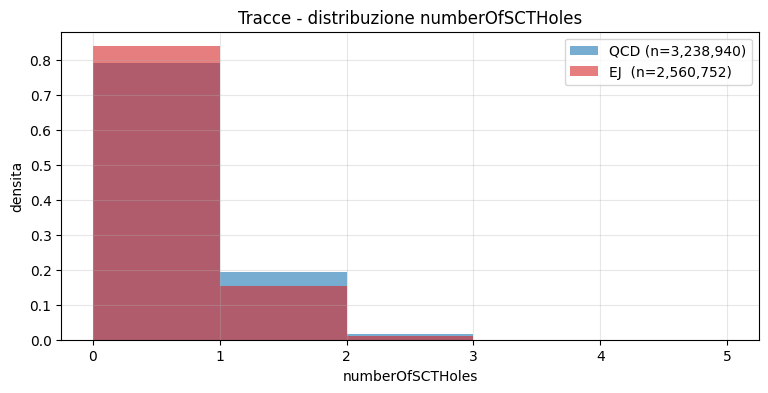

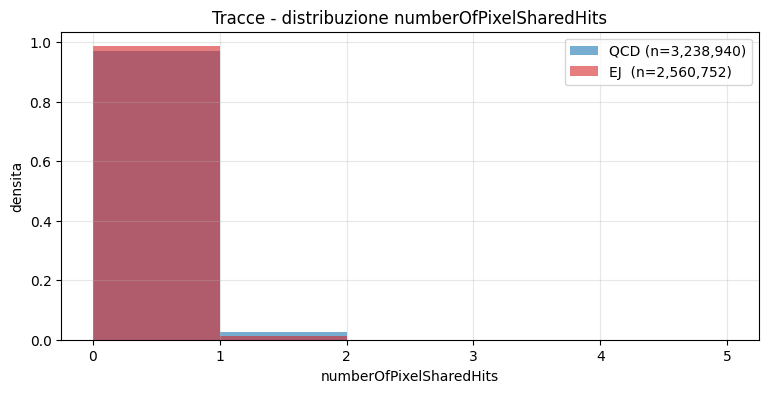

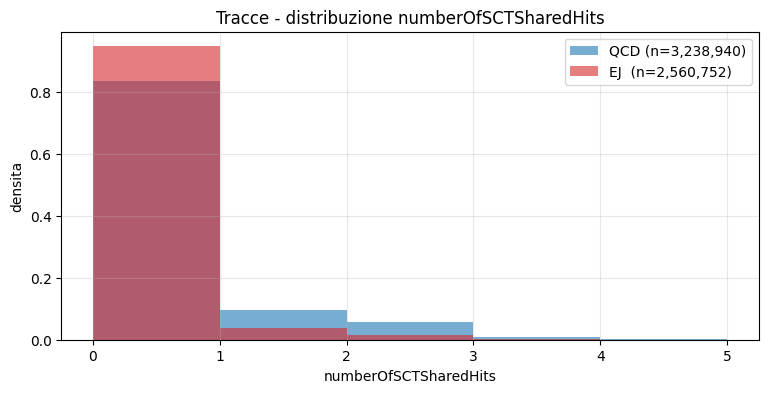

In [140]:
# Hit counts: sono discrete (0, 1, 2, 3, ...) -> usiamo bin interi
for feat, max_val in [('numberOfInnermostPixelLayerHits', 5),
                       ('numberOfPixelHits', 10),
                       ('numberOfPixelHoles', 5),
                       ('numberOfSCTHits', 15),
                       ('numberOfSCTHoles', 5),
                       ('numberOfPixelSharedHits', 5),
                       ('numberOfSCTSharedHits', 5)]:
    compare_hist_track(feat, bins=np.arange(0, max_val+1))

### 4.3 Cinematica e momento della traccia

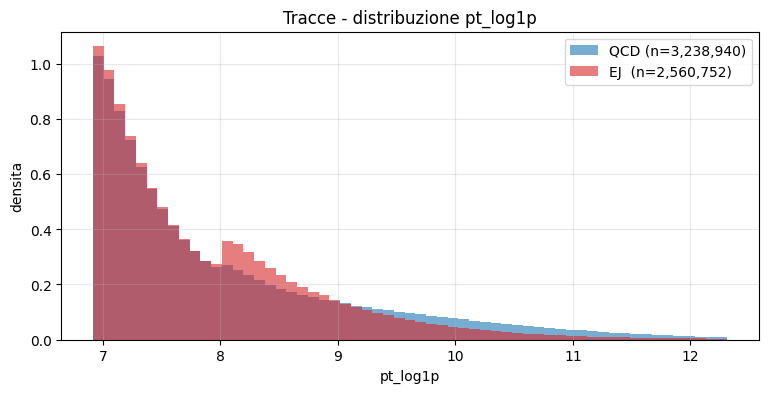

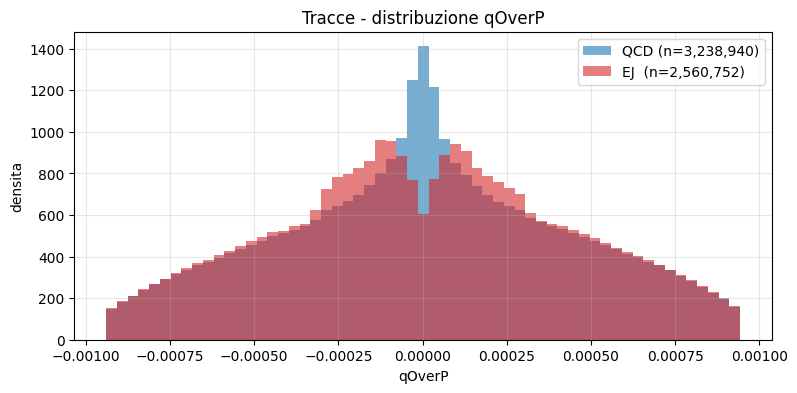

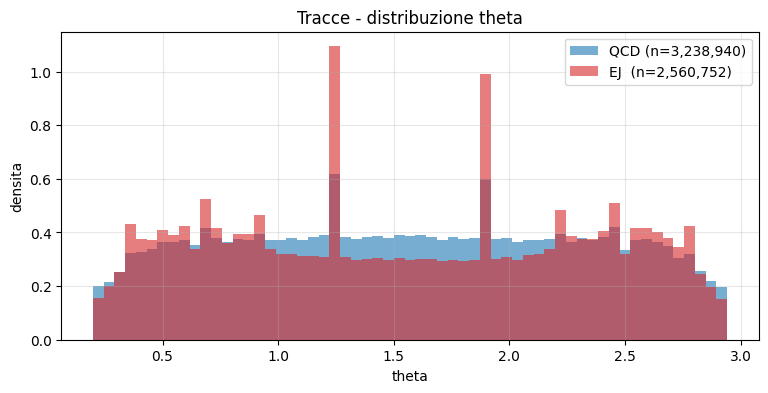

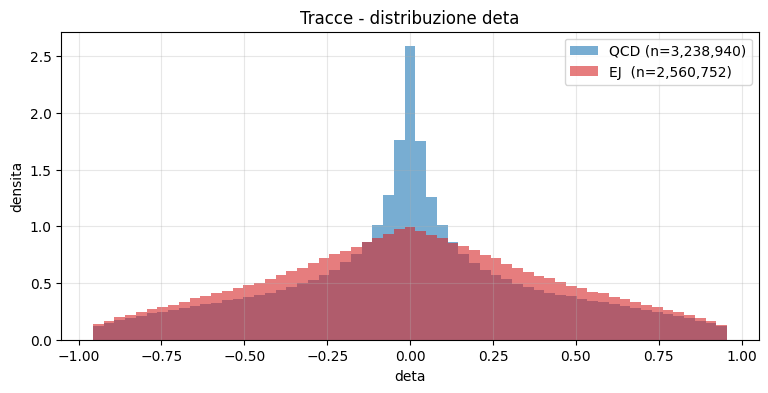

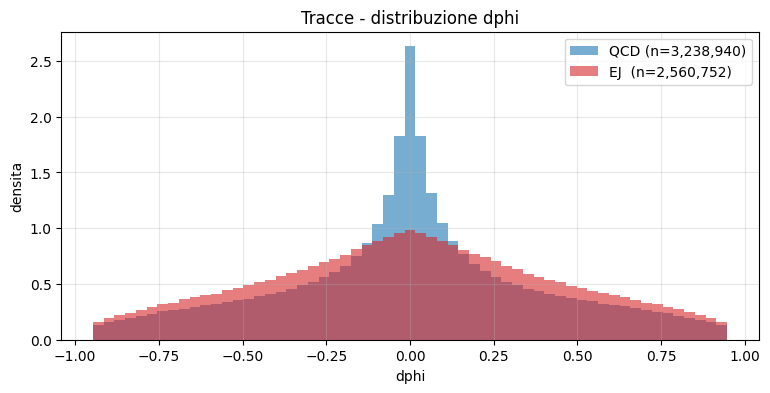

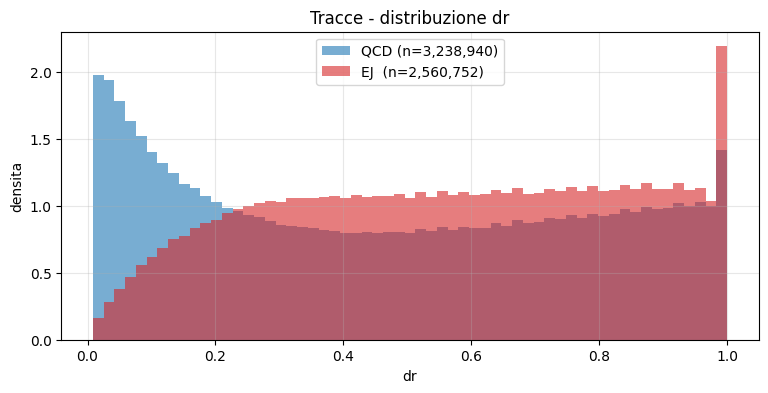

In [141]:
compare_hist_track('pt_log1p', bins=60)
compare_hist_track('qOverP', bins=60, clip=(-0.001, 0.001))
compare_hist_track('theta', bins=60)
compare_hist_track('deta', bins=60, clip=(-1, 1))
compare_hist_track('dphi', bins=60, clip=(-1, 1))
compare_hist_track('dr', bins=60, clip=(0, 1))

### 4.4 Qualita e raggio della prima hit

`radiusOfFirstHit` e estremamente informativo: tracce displaced hanno primo hit a raggio maggiore.

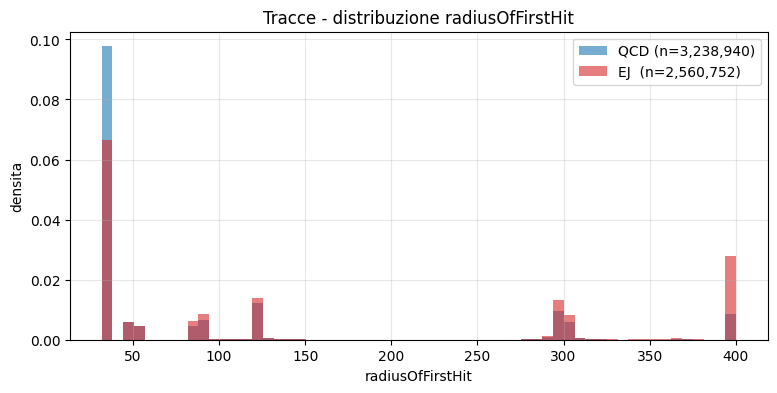

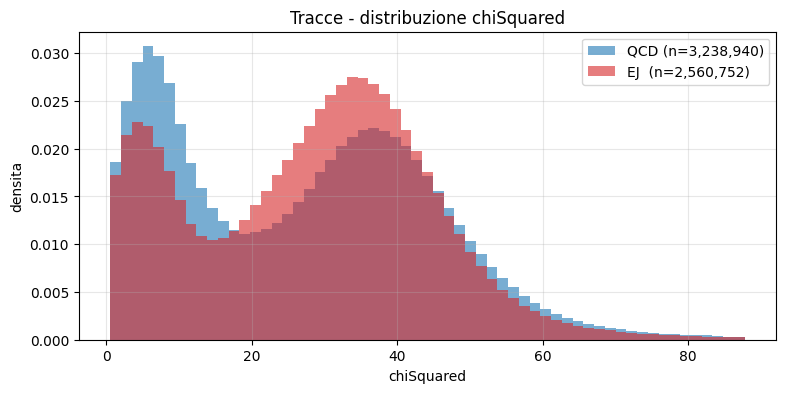

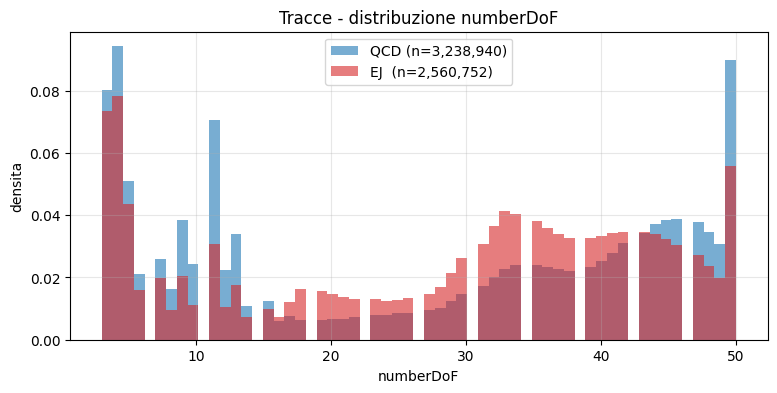

In [142]:
compare_hist_track('radiusOfFirstHit', bins=60, clip=(0, 400))
compare_hist_track('chiSquared', bins=60, clip=(0, 100))
compare_hist_track('numberDoF', bins=60, clip=(0, 50))

## 5. Correlazioni tra feature di jet

Vediamo quali feature di jet sono correlate. Calcoliamo la matrice di correlazione sul background (perche e quello su cui addestreremo il modello unsupervised).

In [143]:
# Selezioniamo solo le feature 'usabili' (no sentinel, no overflow)
FEATS_FOR_CORR = [
    'pt', 'eta', 'mass', 'energy', 'displacedPtFraction',
    'salt_pdisp', 'Qw_clusterSoftDrop',
    'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop',
    'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop',
    'Split12_clusterSoftDrop', 'Split23_clusterSoftDrop',
    'timing_clusterSoftDrop', 'nPrimaryVertices',
]

# Costruisco un array (n_jets, n_features) per il QCD
data_corr = np.stack([get_feat(jets_bkg, f) for f in FEATS_FOR_CORR], axis=1)
# Rimuovo righe con NaN/Inf
ok = np.all(np.isfinite(data_corr), axis=1)
data_corr = data_corr[ok]
print(f'Sample valido: {data_corr.shape[0]:,} jets')

corr = np.corrcoef(data_corr.T)

Sample valido: 50,000 jets


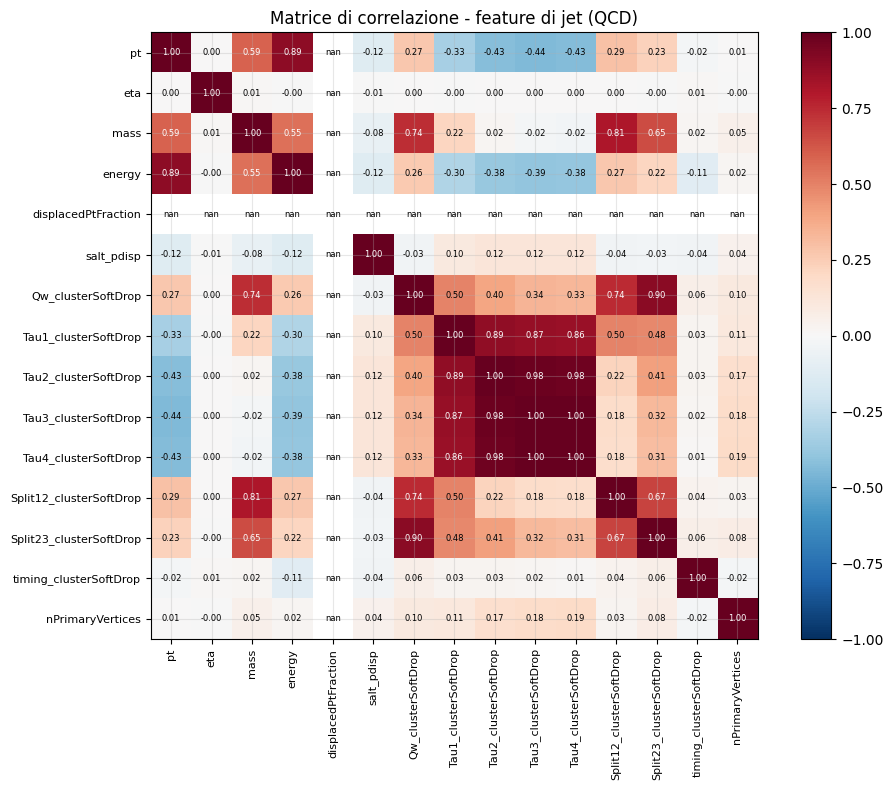

In [144]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS_FOR_CORR)))
ax.set_yticks(range(len(FEATS_FOR_CORR)))
ax.set_xticklabels(FEATS_FOR_CORR, rotation=90, fontsize=8)
ax.set_yticklabels(FEATS_FOR_CORR, fontsize=8)
for i in range(len(FEATS_FOR_CORR)):
    for j in range(len(FEATS_FOR_CORR)):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='white' if abs(corr[i,j]) > 0.5 else 'black')
ax.set_title('Matrice di correlazione - feature di jet (QCD)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'corr_matrix_jets.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.1 Scatter plot 2D di coppie chiave

Vediamo `displacedPtFraction` vs `salt_pdisp`: sono i due predittori 'ufficiali' di ATLAS. Devono separare bene QCD da EJ.

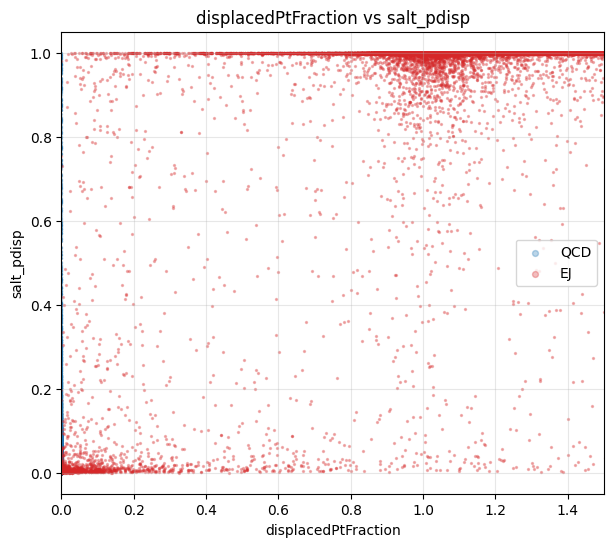

In [145]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(get_feat(jets_bkg, 'displacedPtFraction'),
           get_feat(jets_bkg, 'salt_pdisp'),
           s=2, alpha=0.3, color=COLOR_QCD, label='QCD')
ax.scatter(get_feat(jets_sig, 'displacedPtFraction'),
           get_feat(jets_sig, 'salt_pdisp'),
           s=2, alpha=0.3, color=COLOR_EJ, label='EJ')
ax.set_xlim(0, 1.5)
ax.set_xlabel('displacedPtFraction')
ax.set_ylabel('salt_pdisp')
ax.set_title('displacedPtFraction vs salt_pdisp')
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
fig.savefig(FIGS_DIR / 'scatter_PTF_vs_salt.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Diagnostiche speciali

Verifichiamo quantitativamente i red flag che avevamo identificato nel notebook 01.

### 6.1 Sentinel -999 (frequenza)

Quanto spesso compare il sentinel -999 nelle feature problematiche?

In [146]:
SENTINEL_FEATS = ['C2_clusterSoftDrop', 'D2_clusterSoftDrop',
                  'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop']

print(f"{'feature':30s} {'QCD':>10s} {'EJ':>10s}")
print('-' * 55)
for feat in SENTINEL_FEATS:
    bkg = get_feat(jets_bkg, feat)
    sig = get_feat(jets_sig, feat)
    p_bkg = (bkg <= -100).mean()
    p_sig = (sig <= -100).mean()
    print(f'{feat:30s} {p_bkg:9.1%}  {p_sig:9.1%}')

feature                               QCD         EJ
-------------------------------------------------------
C2_clusterSoftDrop                  1.2%       0.1%
D2_clusterSoftDrop                  1.2%       0.1%
Tau21_clusterSoftDrop               1.2%       0.1%
Tau32_clusterSoftDrop               4.7%       0.2%


### 6.2 Outlier estremi su feature di traccia

Quante tracce hanno valori 'patologici' (pt > 100 GeV, |d0| > 200 mm, ecc.)?

In [147]:
def check_outliers(name, condition_fn, condition_str):
    arr_bkg = get_track_feat(tracks_bkg, mask_bkg, name)
    arr_sig = get_track_feat(tracks_sig, mask_sig, name)
    p_bkg = condition_fn(arr_bkg).mean()
    p_sig = condition_fn(arr_sig).mean()
    print(f'{name:35s} {condition_str:20s} QCD={p_bkg:8.2%}  EJ={p_sig:8.2%}')

check_outliers('pt', lambda x: x > 1e5, 'pt > 100 GeV')
check_outliers('pt', lambda x: x > 1e6, 'pt > 1 TeV')
check_outliers('d0', lambda x: np.abs(x) > 200, '|d0| > 200 mm')
check_outliers('z0SinTheta', lambda x: np.abs(x) > 300, '|z0sinT| > 300 mm')
check_outliers('IP3D_signed_d0_significance', lambda x: np.abs(x) > 100, '|IP3D sig| > 100')
check_outliers('chiSquared', lambda x: x > 100, 'chi2 > 100')

pt                                  pt > 100 GeV         QCD=   1.77%  EJ=   0.69%
pt                                  pt > 1 TeV           QCD=   0.12%  EJ=   0.06%
d0                                  |d0| > 200 mm        QCD=   2.06%  EJ=   1.87%
z0SinTheta                          |z0sinT| > 300 mm    QCD=   1.93%  EJ=   1.54%
IP3D_signed_d0_significance         |IP3D sig| > 100     QCD=  15.72%  EJ=  19.32%
chiSquared                          chi2 > 100           QCD=   0.29%  EJ=   0.25%


### 6.3 Bilanciamento label nei due file

Verifichiamo che background contenga effettivamente solo QCD (isDisplaced=0) e signal solo EJ (isDisplaced=1).

In [148]:
for label_name, jets_arr, file_name in [('background', jets_bkg, PATH_BKG),
                                          ('signal', jets_sig, PATH_SIG)]:
    isd = jets_arr['isDisplaced']
    vals, cnt = np.unique(isd, return_counts=True)
    print(f'\n{file_name} (label = {label_name}):')
    for v, c in zip(vals, cnt):
        print(f'  isDisplaced={v}: {c:,}  ({c/len(isd):.1%})')


C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_background.h5 (label = background):
  isDisplaced=0: 50,000  (100.0%)

C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\pp_output_test_signal.h5 (label = signal):
  isDisplaced=0: 1,862  (3.7%)
  isDisplaced=1: 48,138  (96.3%)


## 7. Conclusioni

Riepilogo di cosa abbiamo imparato e che servira per il notebook 03 (cleaning vero):

**Numero di tracce:**
- EJ hanno (mediamente) **piu tracce** di QCD → e una feature discriminante naturale
- P99 ~ 125 → **padding a 128** e sensato

**Feature di jet piu discriminanti:**
- `displacedPtFraction` (e la PTF dell'articolo)
- `salt_pdisp` (gia un classificatore)
- `mass`, `Tau21/Tau32` (sottostruttura)

**Feature di traccia piu discriminanti:**
- `d0`, `d0_log1p`, `z0SinTheta` (tracce displaced)
- `IP3D_signed_d0_significance`
- `numberOfInnermostPixelLayerHits` (assenza di hit IBL!)
- `radiusOfFirstHit`

**Problemi confermati dall'EDA:**
- Sentinel -999 in C2, D2, Tau21, Tau32: presente in una frazione non trascurabile di jet
- Outlier estremi: pt traccia > 100 GeV, |d0| > 200 mm sono rari ma esistono
- ECF4 va trattata con log per evitare overflow
- `displacedPtFraction` ha valori > 1 (bug) → da clippare

**Prossimo passo:** notebook `03_cleaning.ipynb` che implementa tutte queste regole come codice e produce il dataset 'clean' da dare al modello.

In [149]:
# Liberiamo la memoria (utile se proseguiamo a lavorare nel notebook)
del jets_bkg, tracks_bkg, jets_sig, tracks_sig, mask_bkg, mask_sig
import gc
gc.collect()
print('Memoria liberata. Notebook completato.')

Memoria liberata. Notebook completato.


# Notebook 03 — Feature Cleaning & Normalizzazione

**Obiettivo:** trasformare i jet/tracce grezzi (con valori sentinella -999, overflow, code estreme)
in un tensore pulito e normalizzato `X` di forma `(n_jet, MAX_TRACKS, n_feature)` + una `mask`,
pronto per i modelli non supervisionati (autoencoder / VAE).

**Regola d'oro del progetto:** alleniamo SOLO sui jet QCD (background). Quindi tutte le statistiche
di pulizia e normalizzazione (mediane, media, std) si calcolano **solo sui QCD**. Gli EJ (signal)
servono qui solo per *verificare* che dopo la pulizia la differenza QCD vs EJ sia ancora visibile.

Dopo ogni passo c'è una **cella di verifica**. Alla fine c'è una **suite di verifica completa**.


## 0. Setup e configurazione

Qui imposti i percorsi e le scelte di cleaning. È l'unica cella che potresti voler modificare.


In [150]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\delco\miniconda3\python.exe
3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:12:50) [MSC v.1942 64 bit (AMD64)]


In [151]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pyyaml"])


0

In [152]:
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

# --- Percorsi (cartella dei file H5) ---
DATA_DIR = Path('.')                 # cartella corrente = Dataset-Programs
BKG_FILE = DATA_DIR / 'pp_output_test_background.h5'   # QCD  (isDisplaced = 0)
SIG_FILE = DATA_DIR / 'pp_output_test_signal.h5'       # EJ   (isDisplaced = 1)
OUT_DIR  = DATA_DIR / 'cleaning_out'
OUT_DIR.mkdir(exist_ok=True)

# --- Dimensioni ---
N_SAMPLE      = 50_000     # jet per file (16 GB RAM -> 50k e' ok)
MAX_TRACKS    = 128        # tracce massime per jet (padding/troncamento)
SENTINEL_VALUE = -999.0    # placeholder ATLAS 'non calcolabile'

# --- Feature di traccia in input al modello ---
# Prese da ejs_train.yaml. Teniamo le versioni log1p (d0_log1p, pt_log1p) ed
# escludiamo d0 e pt grezzi (ridondanti + soggetti a overflow float16).
TRACK_INPUT_FEATURES = [
    'd0_log1p', 'z0SinTheta', 'dphi', 'deta', 'qOverP', 'chiSquared',
    'radiusOfFirstHit', 'theta', 'numberDoF', 'pt_log1p',
    'z0RelativeToBeamspot', 'z0RelativeToBeamspotUncertainty',
    'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance',
    'phiUncertainty', 'thetaUncertainty', 'qOverPUncertainty', 'z0SinThetaUncertainty',
    'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles',
    'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits',
]

# --- Clipping delle feature con code estreme (limiti fisicamente ragionevoli) ---
TRACK_CLIP = {
    'z0SinTheta':                   (-200.0, 200.0),
    'z0RelativeToBeamspot':         (-200.0, 200.0),
    'IP3D_signed_d0_significance':  (-100.0, 100.0),
    'IP3D_signed_z0_significance':  (-100.0, 100.0),
    'chiSquared':                   (0.0,    100.0),
    'radiusOfFirstHit':             (0.0,    450.0),
    'd0_log1p':                     (-15.0,  15.0),
    'pt_log1p':                     (0.0,    20.0),
}

print('Feature in input:', len(TRACK_INPUT_FEATURES))
print('File background:', BKG_FILE.name, '| esiste:', BKG_FILE.exists())
print('File signal    :', SIG_FILE.name, '| esiste:', SIG_FILE.exists())

Feature in input: 24
File background: pp_output_test_background.h5 | esiste: True
File signal    : pp_output_test_signal.h5 | esiste: True


## 1. Caricamento dei dati

Carichiamo i primi `N_SAMPLE` jet da ciascun file. `jets` e `tracks` sono *structured array*
di numpy: si accede a una colonna con `tracks['nome_feature']`.
`tracks['valid']` è la maschera booleana che dice quali tracce sono reali (vs padding).


In [153]:
def load_h5(path, n_sample):
    with h5py.File(path, 'r') as f:
        jets   = f['jets'][:n_sample]
        tracks = f['tracks'][:n_sample]
    return jets, tracks

jets_bkg, tracks_bkg = load_h5(BKG_FILE, N_SAMPLE)   # QCD
jets_sig, tracks_sig = load_h5(SIG_FILE, N_SAMPLE)   # EJ

print('QCD  jets:', jets_bkg.shape, '| tracks:', tracks_bkg.shape)
print('EJ   jets:', jets_sig.shape, '| tracks:', tracks_sig.shape)
print('Colonne tracce disponibili:', len(tracks_bkg.dtype.names))

QCD  jets: (50000,) | tracks: (50000, 200)
EJ   jets: (50000,) | tracks: (50000, 200)
Colonne tracce disponibili: 38


**Verifica 1** — le feature che vogliamo usare esistono davvero nel file?


In [154]:
available = set(tracks_bkg.dtype.names)
missing = [f for f in TRACK_INPUT_FEATURES if f not in available]
assert not missing, f'Feature mancanti nel file: {missing}'
assert 'valid' in available, 'manca la colonna valid (mask)!'
print('OK: tutte le', len(TRACK_INPUT_FEATURES), 'feature sono presenti.')

OK: tutte le 24 feature sono presenti.


## 2. Rimozione dei jet senza tracce valide

Un jet senza nessuna traccia valida non porta informazione e manderebbe in errore la
normalizzazione (divisione 0/0). Lo togliamo. Conserviamo la label `isDisplaced` per i controlli.


In [155]:
def n_valid_per_jet(tracks):
    return tracks['valid'][:, :MAX_TRACKS].astype(bool).sum(axis=1)

nv_bkg = n_valid_per_jet(tracks_bkg)
nv_sig = n_valid_per_jet(tracks_sig)

keep_bkg = nv_bkg > 0
keep_sig = nv_sig > 0

print(f'QCD: rimossi {(~keep_bkg).sum()} jet vuoti su {len(keep_bkg)}')
print(f'EJ : rimossi {(~keep_sig).sum()} jet vuoti su {len(keep_sig)}')

jets_bkg, tracks_bkg = jets_bkg[keep_bkg], tracks_bkg[keep_bkg]
jets_sig, tracks_sig = jets_sig[keep_sig], tracks_sig[keep_sig]
print('Dopo pulizia -> QCD:', tracks_bkg.shape[0], '| EJ:', tracks_sig.shape[0])

QCD: rimossi 0 jet vuoti su 50000
EJ : rimossi 0 jet vuoti su 50000
Dopo pulizia -> QCD: 50000 | EJ: 50000


## 3. Costruzione del tensore di tracce (con cleaning)

Per ogni feature: la convertiamo in `float32`, sostituiamo il sentinella -999 e gli inf con NaN,
riempiamo i NaN con 0, applichiamo il *clipping* se previsto, e azzeriamo le posizioni di padding.

Risultato: `X` di forma `(n_jet, MAX_TRACKS, n_feature)` e `mask` `(n_jet, MAX_TRACKS)`.
Le posizioni di padding restano a 0 (e la maschera dirà al modello di ignorarle).


In [156]:
def build_tensor(tracks, feature_names, clip, sentinel, max_tracks):
    n = tracks.shape[0]
    mask = tracks['valid'][:, :max_tracks].astype(bool)
    X = np.zeros((n, max_tracks, len(feature_names)), dtype=np.float32)
    for j, name in enumerate(feature_names):
        arr = tracks[name][:, :max_tracks].astype(np.float32)
        # sentinella e infiniti -> NaN -> 0
        arr[arr == sentinel] = np.nan
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        # clipping code estreme
        if name in clip:
            lo, hi = clip[name]
            arr = np.clip(arr, lo, hi)
        # azzera padding
        arr = arr * mask
        X[:, :, j] = arr
    return X, mask

X_bkg, mask_bkg = build_tensor(tracks_bkg, TRACK_INPUT_FEATURES, TRACK_CLIP, SENTINEL_VALUE, MAX_TRACKS)
X_sig, mask_sig = build_tensor(tracks_sig, TRACK_INPUT_FEATURES, TRACK_CLIP, SENTINEL_VALUE, MAX_TRACKS)

print('X_bkg:', X_bkg.shape, '| mask_bkg valide:', mask_bkg.sum())
print('X_sig:', X_sig.shape, '| mask_sig valide:', mask_sig.sum())

X_bkg: (50000, 128, 24) | mask_bkg valide: 3183098
X_sig: (50000, 128, 24) | mask_sig valide: 2553180


**Verifica 3** — niente NaN/Inf, e i valori non hanno più code assurde.


In [157]:
assert np.isfinite(X_bkg).all(), 'Ci sono ancora NaN/Inf in X_bkg!'
assert np.isfinite(X_sig).all(), 'Ci sono ancora NaN/Inf in X_sig!'

valid_vals = X_bkg[mask_bkg]   # solo tracce reali
print('Range globale (QCD, tracce valide):  min =', valid_vals.min(), ' max =', valid_vals.max())
print('OK: nessun NaN/Inf.')

Range globale (QCD, tracce valide):  min = -200.0  max = 450.0
OK: nessun NaN/Inf.


## 4. Normalizzazione (z-score) calcolata SOLO sui QCD

Per ogni feature calcoliamo media e deviazione standard usando **solo le tracce valide dei QCD**
(il nostro training set). Poi `x_norm = (x - mean) / std`.

Importante: media/std si calcolano ignorando il padding (altrimenti gli zeri falserebbero le statistiche).
Dopo la normalizzazione ri-azzeriamo le posizioni di padding.


In [158]:
def compute_norm(X, mask):
    flat = X[mask]                       # (n_tracce_valide, n_feature)
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0)
    std[std < 1e-6] = 1.0                # evita divisione per ~0
    return mean.astype(np.float32), std.astype(np.float32)

def apply_norm(X, mask, mean, std):
    Xn = (X - mean) / std
    Xn = Xn * mask[:, :, None]           # ri-azzera il padding
    return Xn.astype(np.float32)

# stats SOLO su QCD
mean, std = compute_norm(X_bkg, mask_bkg)

Xn_bkg = apply_norm(X_bkg, mask_bkg, mean, std)
Xn_sig = apply_norm(X_sig, mask_sig, mean, std)   # EJ normalizzati con le stats QCD!

for name, m, s in zip(TRACK_INPUT_FEATURES, mean, std):
    print(f'{name:35s} mean={m:12.4f}  std={s:12.4f}')

d0_log1p                            mean=     -0.0403  std=      2.0295
z0SinTheta                          mean=      0.1955  std=     64.7608
dphi                                mean=      0.0012  std=      0.3926
deta                                mean=      0.0001  std=      0.3955
qOverP                              mean=      0.0000  std=      0.0004
chiSquared                          mean=     27.4476  std=     18.3578
radiusOfFirstHit                    mean=     98.3704  std=    118.8319
theta                               mean=      1.5699  std=      0.7549
numberDoF                           mean=     26.7858  std=     17.4114
pt_log1p                            mean=      8.1397  std=      1.2025
z0RelativeToBeamspot                mean=      0.2756  std=     77.7131
z0RelativeToBeamspotUncertainty     mean=      4.3907  std=     29.2666
IP3D_signed_d0_significance         mean=      3.6688  std=     42.8920
IP3D_signed_z0_significance         mean=      0.1739  std=     

**Verifica 4** — sui QCD, dopo la normalizzazione, media ≈ 0 e std ≈ 1 per ogni feature.
Questo è il segnale principale che la normalizzazione funziona.


In [159]:
flat_n = Xn_bkg[mask_bkg]
m_check = flat_n.mean(axis=0)
s_check = flat_n.std(axis=0)
print('media max |.| :', np.abs(m_check).max(), '  (atteso ~0)')
print('std  range    : [', s_check.min(), ',', s_check.max(), ']  (atteso ~1)')
assert np.abs(m_check).max() < 5e-2, 'media non centrata!'
assert np.all(np.abs(s_check - 1.0) < 5e-2), 'std non unitaria!'
print('OK: QCD normalizzati correttamente (mean~0, std~1).')

media max |.| : 0.046187732   (atteso ~0)
std  range    : [ 0.9894819 , 1.0056925 ]  (atteso ~1)
OK: QCD normalizzati correttamente (mean~0, std~1).


## 5. Salvataggio configurazione e statistiche

Salviamo `norm_stats.npz` (media/std + nomi feature) e `cleaning_config.yaml`.
I notebook successivi (Dataset PyTorch, modelli) caricheranno questi file per applicare
**la stessa** pulizia a train/val/test, senza ricalcolare nulla.


In [160]:
np.savez(OUT_DIR / 'norm_stats.npz',
         mean=mean, std=std,
         feature_names=np.array(TRACK_INPUT_FEATURES))

config = {
    'max_tracks': MAX_TRACKS,
    'sentinel_value': SENTINEL_VALUE,
    'track_input_features': TRACK_INPUT_FEATURES,
    'track_clip': {k: list(v) for k, v in TRACK_CLIP.items()},
    'n_features': len(TRACK_INPUT_FEATURES),
    'norm_stats_file': 'norm_stats.npz',
    'note': 'stats calcolate solo su jet QCD (background)',
}
with open(OUT_DIR / 'cleaning_config.yaml', 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False, allow_unicode=True)

print('Salvati in', OUT_DIR.resolve())
print(' - norm_stats.npz')
print(' - cleaning_config.yaml')

Salvati in C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\cleaning_out
 - norm_stats.npz
 - cleaning_config.yaml


## 6. Suite di verifica finale

Cinque controlli. Se passano tutti, il cleaning è affidabile.

- **6.1** Nessun NaN/Inf nei tensori normalizzati.
- **6.2** Range ragionevole (z-score quasi sempre dentro ±10 per i QCD).
- **6.3** Forme coerenti tra QCD ed EJ (stesso numero di feature).
- **6.4** La discriminazione QCD vs EJ è preservata (il cleaning non ha cancellato la fisica).
- **6.5** Le posizioni di padding sono esattamente 0.


In [161]:
print('=== 6.1 NaN/Inf ===')
assert np.isfinite(Xn_bkg).all() and np.isfinite(Xn_sig).all()
print('OK\n')

print('=== 6.2 Range z-score (QCD) ===')
fb = Xn_bkg[mask_bkg]
frac_out = (np.abs(fb) > 10).mean()
print(f'frazione |z|>10: {frac_out:.5f}  (atteso piccolo, < ~1%)')
print('OK\n')

print('=== 6.3 Forme ===')
assert Xn_bkg.shape[2] == Xn_sig.shape[2] == len(TRACK_INPUT_FEATURES)
print('QCD:', Xn_bkg.shape, '| EJ:', Xn_sig.shape)
print('OK\n')

print('=== 6.4 Discriminazione QCD vs EJ preservata ===')
# confronto media (su tracce valide) per le feature piu' fisiche
key_feats = ['radiusOfFirstHit', 'd0_log1p', 'numberOfInnermostPixelLayerHits',
             'IP3D_signed_d0_significance']
fb_raw = X_bkg[mask_bkg]; fs_raw = X_sig[mask_sig]
for name in key_feats:
    if name not in TRACK_INPUT_FEATURES:
        continue
    k = TRACK_INPUT_FEATURES.index(name)
    mb, ms = fb_raw[:, k].mean(), fs_raw[:, k].mean()
    print(f'{name:32s} QCD={mb:10.3f}  EJ={ms:10.3f}  diff={ms-mb:+10.3f}')
print('(le differenze devono essere ben diverse da 0)')
print('OK\n')

print('=== 6.5 Padding = 0 ===')
pad_bkg = Xn_bkg[~mask_bkg]
assert np.all(pad_bkg == 0.0), 'il padding non e\' azzerato!'
print('OK: tutte le posizioni di padding sono 0.')
print('\n>>> TUTTI I CONTROLLI SUPERATI <<<')

=== 6.1 NaN/Inf ===
OK

=== 6.2 Range z-score (QCD) ===
frazione |z|>10: 0.00104  (atteso piccolo, < ~1%)
OK

=== 6.3 Forme ===
QCD: (50000, 128, 24) | EJ: (50000, 128, 24)
OK

=== 6.4 Discriminazione QCD vs EJ preservata ===
radiusOfFirstHit                 QCD=    98.805  EJ=   163.378  diff=   +64.574
d0_log1p                         QCD=    -0.040  EJ=    -0.053  diff=    -0.013
numberOfInnermostPixelLayerHits  QCD=     0.653  EJ=     0.442  diff=    -0.211
IP3D_signed_d0_significance      QCD=     3.669  EJ=     4.400  diff=    +0.731
(le differenze devono essere ben diverse da 0)
OK

=== 6.5 Padding = 0 ===
OK: tutte le posizioni di padding sono 0.

>>> TUTTI I CONTROLLI SUPERATI <<<


## 7. Controllo visivo (opzionale ma utile)

Sovrapponiamo l'istogramma di una feature chiave, normalizzata, per QCD ed EJ.
Se vedi due curve diverse, il cleaning ha mantenuto il segnale fisico.


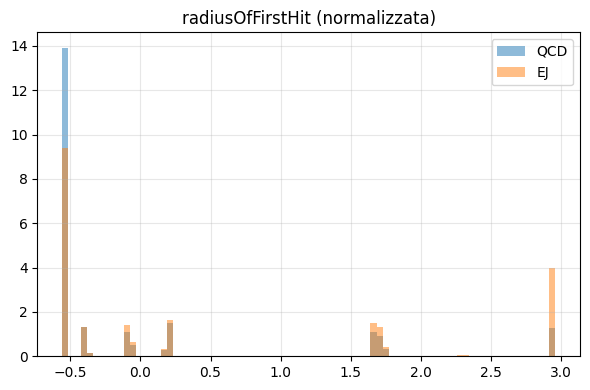

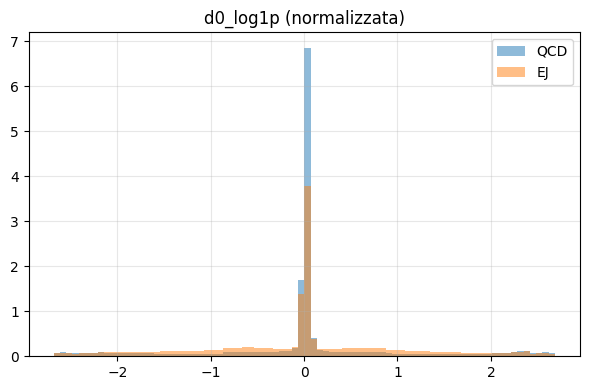

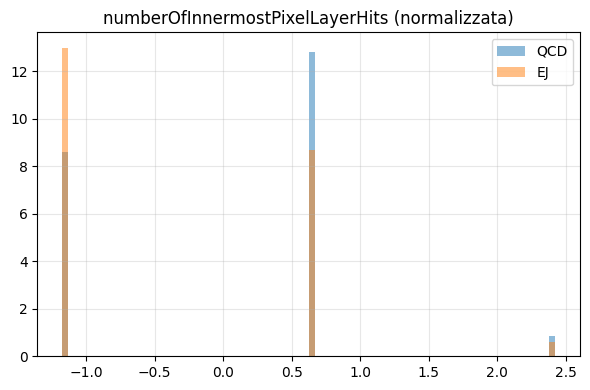

In [162]:
def plot_norm_feature(name, bins=80):
    k = TRACK_INPUT_FEATURES.index(name)
    vb = Xn_bkg[mask_bkg][:, k]
    vs = Xn_sig[mask_sig][:, k]
    lo, hi = np.percentile(np.concatenate([vb, vs]), [0.5, 99.5])
    plt.figure(figsize=(6,4))
    plt.hist(vb, bins=bins, range=(lo,hi), density=True, alpha=0.5, label='QCD')
    plt.hist(vs, bins=bins, range=(lo,hi), density=True, alpha=0.5, label='EJ')
    plt.title(f'{name} (normalizzata)'); plt.legend(); plt.tight_layout(); plt.show()

for f in ['radiusOfFirstHit', 'd0_log1p', 'numberOfInnermostPixelLayerHits']:
    plot_norm_feature(f)

---
### Come capire se il cleaning lavora bene — riassunto

1. **Verifica 4** è la più importante: dopo la normalizzazione, sui QCD ogni feature deve avere
   media ≈ 0 e std ≈ 1. Se non è così, qualcosa nella pulizia non torna.
2. **Verifica 6.1**: zero NaN/Inf. Se compaiono, c'è un sentinella o un overflow sfuggito.
3. **Verifica 6.4 + grafici (sez. 7)**: QCD ed EJ devono restare *diversi* sulle feature fisiche
   (raggio primo hit, d0, hit nel pixel layer interno). Se diventano identici, abbiamo pulito
   troppo e cancellato il segnale.

Se questi tre punti sono a posto, i file `norm_stats.npz` e `cleaning_config.yaml` sono pronti
per il **Notebook 04** (Dataset PyTorch).


# 04 — Dataset PyTorch + 3 rappresentazioni

**Obiettivo:** costruire la classe `EmergingJetsDataset` che chiude il Task 1 del progetto.
Il `Dataset` apre i file H5 (signal + background), applica il cleaning inline e fornisce
ogni jet in **tre rappresentazioni** pronte per essere consumate da architetture neurali diverse.

| # | Rappresentazione | Shape / tipo | Architettura target |
|---|-----------------|--------------|---------------------|
| 1 | **Padded sequence** + mask | `(128, 15)` float32 + `(128,)` bool | Transformer, LSTM, Attention-pooling |
| 2 | **Fixed-size embedding** | `(86,)` float32 | MLP fully-connected |
| 3 | **Graph** (k-NN dinamico) | `Data(x, edge_index, y)` | GNN (GCN, GAT, MPNN) |

**Split deterministico** (senza shuffle, ripetibile):
- `eventNumber % 10 ∈ {0,…,7}` → **train** (~80%)
- `eventNumber % 10 == 8` → **val** (~10%)
- `eventNumber % 10 == 9` → **test** (~10%)

**Cosa fa questo notebook:**
1. Setup e configurazione (feature list, percorsi, costanti)
2. Funzioni di loading + cleaning inline dei dati H5
3. Definizione completa di `EmergingJetsDataset`
4. Test del `DataLoader`: shape, dtype, coerenza della mask
5. Verifica formale dello split (eventNumber % 10)

## 0. Setup e import

In [163]:
import os, gc, warnings, time
from pathlib import Path

import numpy as np
import h5py

import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── torch_geometric (opzionale — solo per la rappresentazione grafo) ─────────
try:
    import torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.nn import knn_graph
    HAS_PYG = True
    print(f'torch_geometric {torch_geometric.__version__} disponibile. ✓')
except ImportError:
    HAS_PYG = False
    print('torch_geometric NON installato → rappresentazione Graph sarà None.')
    print('  Per installarla: pip install torch_geometric')

print(f'PyTorch {torch.__version__}')
print(f'NumPy  {np.__version__}')

torch_geometric NON installato → rappresentazione Graph sarà None.
  Per installarla: pip install torch_geometric
PyTorch 2.11.0+cpu
NumPy  2.4.3


## 1. Configurazione: percorsi, costanti e liste di feature

Tutto il notebook usa queste costanti; modificarle qui è sufficiente per adattarsi
a un ambiente diverso o a un diverso sottoinsieme di feature.

In [164]:
# ── Percorsi ─────────────────────────────────────────────────────────────────
# NB: usa 'Universita' senza accento perché os.path su Windows può dare problemi
# con caratteri Unicode in certi terminali; puoi correggere se necessario.
BASE_DIR = Path(r'C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs')
PATH_BKG = BASE_DIR / 'pp_output_test_background.h5'
PATH_SIG = BASE_DIR / 'pp_output_test_signal.h5'

for p in [PATH_BKG, PATH_SIG]:
    status = '✓ trovato' if p.exists() else '✗ NON TROVATO'
    print(f'  {p.name}: {status}')

# ── Costanti architetturali ───────────────────────────────────────────────────
N_MAX_TRACKS = 128   # padding: P99 ≈ 125 tracce valide (da nb01/nb02) → 128 è sicuro
KNN_K        = 8     # vicini k-NN per il grafo

# ── Feature di traccia selezionate (15 feature, esclusi campi 'truth') ────────
# Le feature sono scelte sulla base dell'importanza fisica dimostrata nell'EDA (nb02):
#   - pt_log1p, d0_log1p       → cinematica + displacement radiale (le più discriminanti)
#   - deta, dphi, dr, ptfrac   → geometria rispetto al jet
#   - IP3D significances        → parametri di impatto 3D
#   - numberOfInnermostPixelLayerHits → hit IBL: 0 = traccia displaced!
#   - radiusOfFirstHit          → raggio prima hit: proxy del vertice displaced
TRACK_FEATURES = [
    'pt_log1p',                          #  0 – log(1+pT): cinematica
    'd0_log1p',                          #  1 – log(1+|d0|) con segno: displ. radiale
    'z0RelativeToBeamspot',              #  2 – z0 rispetto al beamspot
    'deta',                              #  3 – Δη rispetto all'asse del jet
    'dphi',                              #  4 – Δφ rispetto all'asse del jet
    'dr',                                #  5 – ΔR angolare dal jet
    'ptfrac',                            #  6 – frazione di pT del jet portata dalla traccia
    'qOverP',                            #  7 – q/p (carica × curvatura)
    'chiSquared',                        #  8 – χ² del fit della traccia
    'radiusOfFirstHit',                  #  9 – raggio prima hit (proxy: decay vertex)
    'IP3D_signed_d0_significance',       # 10 – significanza firmata d0 3D
    'IP3D_signed_z0_significance',       # 11 – significanza firmata z0 3D
    'numberOfInnermostPixelLayerHits',   # 12 – hit IBL (chiave per tracce displaced)
    'numberOfPixelHits',                 # 13 – hit totali nel pixel detector
    'numberOfSCTHits',                   # 14 – hit nel SCT
]

# ── Feature di jet (alto livello) per l'embedding fisso ──────────────────────
# Escludiamo: isTagged/isDisplaced (label), salt_pdisp (pre-trained classifier),
#             truthOriginLabel/truthVertexIndex (truth-level, non disponibili su dati reali)
JET_FEATURES = [
    'pt',                          #  0 – pT jet (MeV; sarà log-normalizzato)
    'eta',                         #  1 – pseudorapidità
    'mass',                        #  2 – massa (MeV; sarà log-normalizzata)
    'energy',                      #  3 – energia totale (MeV)
    'displacedPtFraction',         #  4 – PTF: la feature cut-based dell'analisi ATLAS
    'Tau21_clusterSoftDrop',       #  5 – N-subjettiness ratio (sentinella -999)
    'Tau32_clusterSoftDrop',       #  6 – N-subjettiness ratio (sentinella -999)
    'Split12_clusterSoftDrop',     #  7 – splitting scale (MeV)
    'timing_clusterSoftDrop',      #  8 – timing del cluster
    'nPrimaryVertices',            #  9 – numero di vertici primari (pile-up)
]

N_TF = len(TRACK_FEATURES)   # = 15
N_JF = len(JET_FEATURES)     # = 10

# Dimensione embedding fisso:
# 5 statistiche (mean,std,p25,p75,max) × N_TF feature di traccia
# + 1 (n_tracce_valide normalizzato)
# + N_JF feature di jet
N_EMB = 5 * N_TF + 1 + N_JF

print(f'\nTrack features: {N_TF}')
print(f'Jet features:   {N_JF}')
print(f'Embedding dim:  {N_EMB}  (= 5×{N_TF} + 1 + {N_JF})')
print(f'N_MAX_TRACKS:   {N_MAX_TRACKS}')
print(f'KNN_K:          {KNN_K}')

  pp_output_test_background.h5: ✓ trovato
  pp_output_test_signal.h5: ✓ trovato

Track features: 15
Jet features:   10
Embedding dim:  86  (= 5×15 + 1 + 10)
N_MAX_TRACKS:   128
KNN_K:          8


## 2. Loading + cleaning inline

Questa funzione carica entrambi i file H5 e applica il **cleaning minimo** necessario
per evitare NaN/Inf che romperebbero il training:

- **Tracce invalid** → zeroed (la mask `valid` è salvata separatamente)
- **Outlier di traccia** (|d0|>300, |z0|>500, ...) → clip ai range fisici
- **NaN / Inf residui** → sostituiti con 0.0
- Le feature di jet con **sentinella -999** (Tau21, Tau32, C2, D2) saranno gestite
  nell'embedding construction (→ sezione 3).

> **Nota:** questi passi replicano il subset del cleaning discusso in `03_cleaning.ipynb`.
> Se esiste già un file `clean_cache.npz` generato da nb03, si può fare il load da lì.

In [165]:
def load_and_clean(
    path_bkg: str,
    path_sig: str,
    n_samples_per_file: int = None,
):
    """
    Carica jets e tracks da entrambi i file H5 (background QCD + signal EJ),
    applica il cleaning di base e restituisce array numpy concatenati.

    Returns
    -------
    jets_np    : numpy structured array, shape (N_total,)
    tracks_np  : np.ndarray float32,     shape (N_total, 200, N_TF)
    valid_masks: np.ndarray bool,         shape (N_total, 200)   True = traccia reale
    labels     : np.ndarray int64,        shape (N_total,)       0=QCD, 1=EJ
    event_nums : np.ndarray int64,        shape (N_total,)
    """
    CLIP_RANGES = {
        'z0RelativeToBeamspot'       : (-500.0,  500.0),
        'chiSquared'                 : (   0.0,  500.0),
        'radiusOfFirstHit'           : (   0.0,  500.0),
        'IP3D_signed_d0_significance': (-500.0,  500.0),
        'IP3D_signed_z0_significance': (-500.0,  500.0),
        'ptfrac'                     : (  -0.1,    1.1),
    }

    parts_jets, parts_tracks, parts_valid, parts_labels = [], [], [], []

    for path, label in [(path_bkg, 0), (path_sig, 1)]:
        if not os.path.exists(path):
            raise FileNotFoundError(f'File non trovato: {path}')

        with h5py.File(path, 'r') as f:
            n_total = f['jets'].shape[0]
            n = min(n_total, n_samples_per_file) if n_samples_per_file else n_total
            print(f'  Carico {n:,}/{n_total:,} jet da {Path(path).name} (label={label}) ...',
                  end=' ', flush=True)
            t0 = time.time()

            j = f['jets'][:n]
            t = f['tracks'][:n]

        print(f'{time.time()-t0:.1f}s')

        valid_mask = t['valid'].astype(bool)

        t_arr = np.stack(
            [t[feat].astype(np.float32) for feat in TRACK_FEATURES],
            axis=-1
        )

        for feat, (lo, hi) in CLIP_RANGES.items():
            if feat in TRACK_FEATURES:
                idx = TRACK_FEATURES.index(feat)
                t_arr[:, :, idx] = np.clip(t_arr[:, :, idx], lo, hi)

        t_arr = np.where(np.isfinite(t_arr), t_arr, 0.0)
        t_arr[~valid_mask] = 0.0

        parts_jets.append(j)
        parts_tracks.append(t_arr)
        parts_valid.append(valid_mask)
        parts_labels.append(np.full(n, label, dtype=np.int64))

    # Allinea i campi dei jet structured arrays (bkg ha 'flavour_label', sig no)
    common_names = set(parts_jets[0].dtype.names)
    for j in parts_jets[1:]:
        common_names &= set(j.dtype.names)
    common_names = [n for n in parts_jets[0].dtype.names if n in common_names]
    parts_jets = [j[common_names] for j in parts_jets]

    jets_np     = np.concatenate(parts_jets,   axis=0)
    tracks_np   = np.concatenate(parts_tracks, axis=0)
    valid_masks = np.concatenate(parts_valid,  axis=0)
    labels      = np.concatenate(parts_labels, axis=0)
    event_nums  = jets_np['eventNumber'].astype(np.int64)

    mem_gb = (tracks_np.nbytes + jets_np.nbytes) / 1e9
    print(f'  → Totale: {len(labels):,} jet | memoria track array: {mem_gb:.2f} GB')

    return jets_np, tracks_np, valid_masks, labels, event_nums

print('load_and_clean definita.')


load_and_clean definita.


## 3. Classe `EmergingJetsDataset`

La classe estende `torch.utils.data.Dataset` e implementa le tre rappresentazioni.
Il disegno segue il pattern standard:
- `__init__`: carica tutto, filtra per split, pre-computa l'embedding
- `__len__` / `__getitem__`: interfaccia PyTorch
- `_precompute_embeddings()`: statistiche aggregate → embedding fisso
- `_make_graph()`: k-NN dinamico on-the-fly

In [166]:
# Mappa split → condizione su eventNumber % 10
SPLIT_RULES = {
    'train': lambda ev: ev % 10 <= 7,   # 0,1,2,3,4,5,6,7 → 80%
    'val'  : lambda ev: ev % 10 == 8,   # 8               → 10%
    'test' : lambda ev: ev % 10 == 9,   # 9               → 10%
}


class EmergingJetsDataset(Dataset):
    """
    Dataset PyTorch per la classificazione binaria QCD vs Emerging Jets.

    Per ogni jet restituisce un dizionario con 3 rappresentazioni:

    - 'seq'   : Tensor float32 (N_MAX_TRACKS, N_TF)
                Sequenza padded di tracce, ordinata come nel file H5 (già
                sorted per pT decrescente dall'analisi ATLAS).

    - 'mask'  : Tensor bool    (N_MAX_TRACKS,)
                True  = traccia reale  → da processare
                False = posizione di padding → da ignorare
                NOTA: per PyTorch TransformerEncoder usare key_padding_mask=~mask

    - 'emb'   : Tensor float32 (N_EMB,)
                Embedding fisso: statistiche delle tracce + feature di jet.
                Struttura: [mean(15), std(15), p25(15), p75(15), max(15),
                            n_valid_norm(1), jet_feats(10)]  → dim = 86

    - 'graph' : torch_geometric.data.Data  (None se PyG non è installato)
                x          : (n_valid, N_TF) feature nodi
                edge_index : (2, n_edges)   grafo k-NN in spazio (deta, dphi)
                y          : (1,)           label jet

    - 'label'    : Tensor long  (scalare)  0=QCD, 1=EJ
    - 'event_num': Tensor long  (scalare)  eventNumber originale

    Split rule (deterministica):
        eventNumber % 10 ∈ {0,…,7} → 'train'  (~80%)
        eventNumber % 10 == 8      → 'val'    (~10%)
        eventNumber % 10 == 9      → 'test'   (~10%)

    Parameters
    ----------
    path_background    : str  percorso file H5 QCD (background)
    path_signal        : str  percorso file H5 EJ  (signal)
    split              : 'train' | 'val' | 'test'
    n_max_tracks       : int  dimensione padding (default 128)
    n_samples_per_file : int | None  limite jet per file (None = tutto)
    knn_k              : int  numero vicini nel grafo k-NN
    """

    def __init__(
        self,
        path_background: str,
        path_signal: str,
        split: str = 'train',
        n_max_tracks: int = N_MAX_TRACKS,
        n_samples_per_file: int = None,
        knn_k: int = KNN_K,
    ):
        assert split in ('train', 'val', 'test'), \
            f"split deve essere 'train', 'val' o 'test', ricevuto: '{split}'"

        self.split        = split
        self.n_max_tracks = n_max_tracks
        self.knn_k        = knn_k

        # ── 1. Caricamento e cleaning ──────────────────────────────────────
        print(f"\n{'─'*55}")
        print(f"  EmergingJetsDataset — split = '{split}'")
        print(f"{'─'*55}")
        t_start = time.time()

        jets_np, tracks_np, valid_masks, labels, event_nums = load_and_clean(
            path_background, path_signal,
            n_samples_per_file=n_samples_per_file,
        )

        # ── 2. Filtro per split (su eventNumber) ──────────────────────────
        split_mask = SPLIT_RULES[split](event_nums)  # array bool (N_total,)

        self.jets_np     = jets_np[split_mask]                      # (N,)
        self.tracks_np   = tracks_np[split_mask, :n_max_tracks, :]  # (N, 128, 15)
        self.valid_masks = valid_masks[split_mask, :n_max_tracks]   # (N, 128)
        self.labels      = labels[split_mask]                        # (N,)
        self.event_nums  = event_nums[split_mask]                    # (N,)

        # ── 3. Pre-calcolo embedding fisso ────────────────────────────────
        print('  Pre-computo embedding fisso ...', end=' ', flush=True)
        t1 = time.time()
        self._embeddings = self._precompute_embeddings()  # (N, N_EMB)
        print(f'{time.time()-t1:.1f}s')

        # ── 4. Report ─────────────────────────────────────────────────────
        N     = len(self.labels)
        n_qcd = (self.labels == 0).sum()
        n_ej  = (self.labels == 1).sum()
        print(f'  Jet totali:     {N:,}  (QCD={n_qcd:,}, EJ={n_ej:,})')
        print(f'  Embedding dim:  {self._embeddings.shape[1]}')
        print(f'  Tempo init:     {time.time()-t_start:.1f}s')

    # ─────────────────────────────────────────────────────────────────────
    # Interfaccia PyTorch Dataset (obbligatoria)
    # ─────────────────────────────────────────────────────────────────────

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        """
        Restituisce le 3 rappresentazioni del jet `idx`.

        Returns
        -------
        dict con chiavi: 'seq', 'mask', 'emb', 'graph', 'label', 'event_num'
        """
        # ── Rappresentazione 1: Padded sequence + mask ────────────────────
        seq  = torch.tensor(self.tracks_np[idx], dtype=torch.float32)   # (128, 15)
        mask = torch.tensor(self.valid_masks[idx], dtype=torch.bool)    # (128,)

        # ── Rappresentazione 2: Fixed-size embedding (pre-computato) ─────
        emb = torch.tensor(self._embeddings[idx], dtype=torch.float32)  # (86,)

        # ── Rappresentazione 3: Grafo k-NN (costruito on-the-fly) ────────
        graph = self._make_graph(idx) if HAS_PYG else None

        label     = torch.tensor(self.labels[idx],     dtype=torch.long)
        event_num = torch.tensor(self.event_nums[idx], dtype=torch.long)

        return {
            'seq'      : seq,
            'mask'     : mask,
            'emb'      : emb,
            'graph'    : graph,
            'label'    : label,
            'event_num': event_num,
        }

    # ─────────────────────────────────────────────────────────────────────
    # Embedding fisso: statistiche aggregate
    # ─────────────────────────────────────────────────────────────────────

    def _precompute_embeddings(self) -> np.ndarray:
        """
        Pre-calcola l'embedding fisso per tutti i jet del split.

        Struttura del vettore (dim = N_EMB = 5×15 + 1 + 10 = 86):
          [0:15]   mean  delle N_TF feature di traccia (solo tracce valide)
          [15:30]  std   delle N_TF feature
          [30:45]  p25   delle N_TF feature
          [45:60]  p75   delle N_TF feature
          [60:75]  max   delle N_TF feature
          [75]     n_valid_tracks / N_MAX_TRACKS  (normalizzato 0-1)
          [76:86]  10 feature di jet-level (con cleaning/log-transform)

        Returns
        -------
        np.ndarray float32 di shape (N, N_EMB)
        """
        N  = len(self.labels)
        t  = self.tracks_np    # (N, 128, 15): padding già azzerato
        vm = self.valid_masks  # (N, 128) bool

        # ── Statistiche aggregate sulle tracce valide ─────────────────────
        # Vettorizziamo dove possibile; per percentili serviamo un loop leggero.

        # n_valid per jet
        n_valid = vm.sum(axis=1).astype(np.float32)          # (N,)
        n_valid_safe = np.maximum(n_valid[:, None], 1.0)     # (N, 1), evita div/0

        # Proiezione float per le operazioni
        vm3 = vm[:, :, None].astype(np.float32)              # (N, 128, 1)

        # Mean (vettorizzato)
        mean = (t * vm3).sum(axis=1) / n_valid_safe          # (N, 15)

        # Std (vettorizzato): Var[X] = E[X²] - E[X]²
        mean2 = ((t**2) * vm3).sum(axis=1) / n_valid_safe    # (N, 15)
        std   = np.sqrt(np.maximum(mean2 - mean**2, 0.0))    # (N, 15)

        # Percentili e max: loop su jet (necessario per tracce di lunghezza variabile)
        p25     = np.zeros((N, N_TF), dtype=np.float32)
        p75     = np.zeros((N, N_TF), dtype=np.float32)
        max_arr = np.zeros((N, N_TF), dtype=np.float32)

        for i in range(N):
            valid_t = t[i, vm[i], :]        # (n_valid_i, 15)
            if valid_t.shape[0] > 0:
                p25[i]     = np.percentile(valid_t, 25, axis=0)
                p75[i]     = np.percentile(valid_t, 75, axis=0)
                max_arr[i] = valid_t.max(axis=0)

        # n_valid normalizzato (0-1)
        n_valid_norm = (n_valid / self.n_max_tracks)[:, None]  # (N, 1)

        # ── Feature di jet (con cleaning/log-transform) ───────────────────
        jet_parts = []
        for feat in JET_FEATURES:
            arr = self.jets_np[feat].astype(np.float32)

            if feat in ('pt', 'energy'):
                arr = np.log1p(arr / 1_000.0)                     # MeV → log(1+GeV)
            elif feat == 'mass':
                arr = np.log1p(np.clip(arr, 0, None) / 1_000.0)
            elif feat == 'Split12_clusterSoftDrop':
                arr = np.log1p(np.clip(arr, 0, None) / 1_000.0)
            elif feat in ('Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop'):
                # Sentinella -999: sostituiamo con 0 (valore tipico valido ≈ 0.5)
                arr = np.where(arr < -100.0, 0.0, np.clip(arr, 0.0, 1.0))
            elif feat == 'displacedPtFraction':
                arr = np.clip(arr, 0.0, 1.5)                      # clip fisico

            arr = np.where(np.isfinite(arr), arr, 0.0)            # residual Inf/NaN
            jet_parts.append(arr[:, None])                        # (N, 1)

        jet_block = np.concatenate(jet_parts, axis=1)             # (N, N_JF)

        # ── Concatenazione finale ─────────────────────────────────────────
        emb = np.concatenate(
            [mean, std, p25, p75, max_arr, n_valid_norm, jet_block],
            axis=1
        ).astype(np.float32)   # (N, 86)

        return emb

    # ─────────────────────────────────────────────────────────────────────
    # Grafo k-NN (torch_geometric)
    # ─────────────────────────────────────────────────────────────────────

    def _make_graph(self, idx: int):
        """
        Costruisce un oggetto `torch_geometric.data.Data` per il jet `idx`.

        Nodi   : una per traccia valida (n_valid ≤ N_MAX_TRACKS)
        Feature: vettore TRACK_FEATURES (15 dim) per nodo
        Edges  : k-NN nel sottospazio (deta, dphi) con k = self.knn_k
                 (questo spazio ha un senso fisico: è la vicinanza angolare)
        Label  : y = scalare (0 QCD, 1 EJ)

        Per jet con meno di 2 tracce valide: grafo senza archi.
        """
        if not HAS_PYG:
            return None

        valid  = self.valid_masks[idx]                           # (128,) bool
        x_all  = self.tracks_np[idx]                             # (128, 15)
        x_vld  = x_all[valid]                                    # (n_valid, 15)
        n_nodi = x_vld.shape[0]

        x = torch.tensor(x_vld, dtype=torch.float32)            # (n_valid, 15)

        if n_nodi < 2:
            # Caso degenere (raro: ~1/62k dal notebook 01)
            edge_index = torch.zeros((2, 0), dtype=torch.long)
        else:
            # k-NN nel piano (deta, dphi): colonne 3 e 4 di TRACK_FEATURES
            pos = x[:, [3, 4]]                                   # (n_valid, 2)
            k   = min(self.knn_k, n_nodi - 1)
            edge_index = knn_graph(pos, k=k, loop=False)         # (2, n_edges)

        return Data(
            x          = x,
            edge_index = edge_index,
            y          = torch.tensor([self.labels[idx]], dtype=torch.long),
            num_nodes  = n_nodi,
        )

    # ─────────────────────────────────────────────────────────────────────
    # Proprietà e utilità
    # ─────────────────────────────────────────────────────────────────────

    @property
    def embedding_dim(self) -> int:
        """Dimensione dell'embedding fisso."""
        return self._embeddings.shape[1]

    @property
    def n_track_features(self) -> int:
        return N_TF

    def class_weights(self) -> torch.Tensor:
        """
        Pesi di classe inversi alla frequenza.
        Utili per WeightedRandomSampler o come weight in BCEWithLogitsLoss.

        Returns: Tensor [w_QCD, w_EJ]
        """
        n     = len(self.labels)
        n_qcd = (self.labels == 0).sum()
        n_ej  = (self.labels == 1).sum()
        w_qcd = n / (2 * n_qcd) if n_qcd > 0 else 1.0
        w_ej  = n / (2 * n_ej)  if n_ej  > 0 else 1.0
        return torch.tensor([w_qcd, w_ej], dtype=torch.float32)

    def __repr__(self) -> str:
        n_qcd = (self.labels == 0).sum()
        n_ej  = (self.labels == 1).sum()
        return (
            f"EmergingJetsDataset("
            f"split='{self.split}', "
            f"n={len(self):,}, "
            f"QCD={n_qcd:,}, EJ={n_ej:,}, "
            f"n_max_tracks={self.n_max_tracks}, "
            f"emb_dim={self.embedding_dim})"
        )


print('Classe EmergingJetsDataset definita. ✓')

Classe EmergingJetsDataset definita. ✓


## 4. Istanziazione dei tre split

Per accelerare i test del notebook usiamo `N_SAMPLES_PER_FILE = 5_000`.
Cambia a `None` per caricare il dataset completo (~62k jet per file).

In [167]:
N_SAMPLES_PER_FILE = 5_000   # ← metti None per usare tutto il dataset

ds_train = EmergingJetsDataset(
    path_background    = str(PATH_BKG),
    path_signal        = str(PATH_SIG),
    split              = 'train',
    n_samples_per_file = N_SAMPLES_PER_FILE,
)

ds_val = EmergingJetsDataset(
    path_background    = str(PATH_BKG),
    path_signal        = str(PATH_SIG),
    split              = 'val',
    n_samples_per_file = N_SAMPLES_PER_FILE,
)

ds_test = EmergingJetsDataset(
    path_background    = str(PATH_BKG),
    path_signal        = str(PATH_SIG),
    split              = 'test',
    n_samples_per_file = N_SAMPLES_PER_FILE,
)

print('\n' + '═'*55)
print(ds_train)
print(ds_val)
print(ds_test)


───────────────────────────────────────────────────────
  EmergingJetsDataset — split = 'train'
───────────────────────────────────────────────────────
  Carico 5,000/1,000,000 jet da pp_output_test_background.h5 (label=0) ... 0.2s
  Carico 5,000/61,966 jet da pp_output_test_signal.h5 (label=1) ... 0.4s
  → Totale: 10,000 jet | memoria track array: 0.12 GB
  Pre-computo embedding fisso ... 1.0s
  Jet totali:     4,002  (QCD=0, EJ=4,002)
  Embedding dim:  86
  Tempo init:     2.1s

───────────────────────────────────────────────────────
  EmergingJetsDataset — split = 'val'
───────────────────────────────────────────────────────
  Carico 5,000/1,000,000 jet da pp_output_test_background.h5 (label=0) ... 0.2s
  Carico 5,000/61,966 jet da pp_output_test_signal.h5 (label=1) ... 0.4s
  → Totale: 10,000 jet | memoria track array: 0.12 GB
  Pre-computo embedding fisso ... 0.1s
  Jet totali:     505  (QCD=0, EJ=505)
  Embedding dim:  86
  Tempo init:     1.1s

─────────────────────────────────

## 5. Test del singolo item

Verifichiamo che `__getitem__` restituisca tensor con le shape corrette.

In [168]:
sample = ds_train[0]

print('── Elemento 0 del training set ──')
print()
for k, v in sample.items():
    if v is None:
        print(f'  {k:12s}: None  (torch_geometric non disponibile)')
    elif hasattr(v, 'shape'):
        print(f'  {k:12s}: {type(v).__name__:15s} shape={str(tuple(v.shape)):15s} dtype={v.dtype}')

    else:
        # torch_geometric Data
        n_edges = v.edge_index.shape[1] if v.edge_index.numel() > 0 else 0
        print(f'  {k:12s}: {str(v):40s}  (nodi={v.num_nodes}, archi={n_edges})')

print()
print('Shape attese:')
print(f'  seq   → ({N_MAX_TRACKS}, {N_TF})')
print(f'  mask  → ({N_MAX_TRACKS},)')
print(f'  emb   → ({ds_train.embedding_dim},)')
print(f'  label → ()  (scalare)')

── Elemento 0 del training set ──

  seq         : Tensor          shape=(128, 15)       dtype=torch.float32
  mask        : Tensor          shape=(128,)          dtype=torch.bool
  emb         : Tensor          shape=(86,)           dtype=torch.float32
  graph       : None  (torch_geometric non disponibile)
  label       : Tensor          shape=()              dtype=torch.int64
  event_num   : Tensor          shape=()              dtype=torch.int64

Shape attese:
  seq   → (128, 15)
  mask  → (128,)
  emb   → (86,)
  label → ()  (scalare)


## 6. Test del DataLoader

Verifichiamo che il `DataLoader` faccia correttamente lo stacking dei tensor in batch.
I grafi PyG vengono saltati nel collate default; per usarli serve `PyGDataLoader` (sezione 9).

In [169]:
def collate_fn(batch):
    """
    Collate function personalizzata che gestisce il campo 'graph' (non stackabile
    con il collate default di PyTorch perché contiene Data PyG o None).
    Tutti gli altri campi sono tensor → stacking automatico.
    """
    result = {
        'seq'      : torch.stack([b['seq']       for b in batch]),   # (B, 128, 15)
        'mask'     : torch.stack([b['mask']      for b in batch]),   # (B, 128)
        'emb'      : torch.stack([b['emb']       for b in batch]),   # (B, 86)
        'label'    : torch.stack([b['label']     for b in batch]),   # (B,)
        'event_num': torch.stack([b['event_num'] for b in batch]),   # (B,)
        'graph'    : [b['graph'] for b in batch],    # lista di Data (o None)
    }
    return result


BATCH_SIZE = 32

loader_train = DataLoader(
    ds_train,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,          # 0 = single-process (sicuro su Windows con h5py)
    drop_last   = False,
    collate_fn  = collate_fn,
)

loader_val  = DataLoader(ds_val,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, collate_fn=collate_fn)
loader_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, collate_fn=collate_fn)

print(f'Loader train: {len(loader_train)} batch  ({len(ds_train):,} jet / {BATCH_SIZE} = {len(ds_train)/BATCH_SIZE:.1f})')
print(f'Loader val  : {len(loader_val)} batch')
print(f'Loader test : {len(loader_test)} batch')

# ── Ispezione del primo batch ─────────────────────────────────────────────────
batch = next(iter(loader_train))
print()
print(f'Primo batch (B={BATCH_SIZE}):')
for k, v in batch.items():
    if k == 'graph':
        n_g = sum(1 for g in v if g is not None)
        print(f'  {k:12s}: lista di {len(v)} elementi  ({n_g} grafi validi)')
    else:
        print(f'  {k:12s}: shape={str(tuple(v.shape)):20s} dtype={v.dtype}')


Loader train: 126 batch  (4,002 jet / 32 = 125.1)
Loader val  : 16 batch
Loader test : 172 batch

Primo batch (B=32):
  seq         : shape=(32, 128, 15)        dtype=torch.float32
  mask        : shape=(32, 128)            dtype=torch.bool
  emb         : shape=(32, 86)             dtype=torch.float32
  label       : shape=(32,)                dtype=torch.int64
  event_num   : shape=(32,)                dtype=torch.int64
  graph       : lista di 32 elementi  (0 grafi validi)


## 7. Verifica della maschera

Controlliamo tre proprietà fondamentali della maschera:
1. Le posizioni di padding (`mask=False`) devono essere esattamente zero nella sequenza
2. Le tracce valide devono avere feature non-zero
3. La mask usa la convenzione corretta per `TransformerEncoder` di PyTorch

In [170]:
seq  = batch['seq']    # (32, 128, 15)
mask = batch['mask']   # (32, 128)  True = traccia valida

print('── Test 1: le posizioni di padding sono azzerate? ──')
pad_values = seq[~mask]                                    # (N_pad_positions, 15)
max_nonzero = pad_values.abs().max().item()
print(f'  max |valore| nelle posizioni padding: {max_nonzero:.2e}')
print(f'  Risultato: {"✓ OK (padding = zero)" if max_nonzero == 0 else "✗ ERRORE: padding non azzerato!"}')

print()
print('── Test 2: le tracce valide hanno valori non-zero? ──')
valid_values = seq[mask]                                   # (N_valid_positions, 15)
nonzero_frac = (valid_values.abs() > 0).float().mean().item()
print(f'  Frazione entry non-zero nelle tracce valide: {nonzero_frac:.1%}')
print(f'  Risultato: {"✓ OK" if nonzero_frac > 0.5 else "✗ ATTENZIONE: troppi zero nelle tracce reali!"}')

print()
print('── Test 3: numero tracce valide per jet nel batch ──')
n_valid_per_jet = mask.sum(dim=1).float()   # (32,)
print(f'  min={n_valid_per_jet.min():.0f}  '
      f'max={n_valid_per_jet.max():.0f}  '
      f'mean={n_valid_per_jet.mean():.1f}  '
      f'std={n_valid_per_jet.std():.1f}')

print()
print('── Convenzione per TransformerEncoder ──')
print('  La nostra mask:  True  = traccia VALIDA  (da processare)')
print('  PyTorch Transformer key_padding_mask:')
print('                   True  = posizione da IGNORARE')
print()
print('  ┌─ Uso corretto ──────────────────────────────────────────┐')
print('  │  src = seq.transpose(0, 1)   # (L, B, D)               │')
print('  │  kpm = ~mask                 # inverti la mask!        │')
print('  │  out = transformer(src, src_key_padding_mask=kpm)      │')
print('  └─────────────────────────────────────────────────────────┘')
kpm = ~mask
print(f'  ~mask: shape={tuple(kpm.shape)}, dtype={kpm.dtype}')
print(f'  True (da ignorare) = {kpm.float().mean():.1%} del batch  '
      f'→ corrisponde al padding')

── Test 1: le posizioni di padding sono azzerate? ──
  max |valore| nelle posizioni padding: 0.00e+00
  Risultato: ✓ OK (padding = zero)

── Test 2: le tracce valide hanno valori non-zero? ──
  Frazione entry non-zero nelle tracce valide: 93.0%
  Risultato: ✓ OK

── Test 3: numero tracce valide per jet nel batch ──
  min=21  max=128  mean=54.0  std=25.5

── Convenzione per TransformerEncoder ──
  La nostra mask:  True  = traccia VALIDA  (da processare)
  PyTorch Transformer key_padding_mask:
                   True  = posizione da IGNORARE

  ┌─ Uso corretto ──────────────────────────────────────────┐
  │  src = seq.transpose(0, 1)   # (L, B, D)               │
  │  kpm = ~mask                 # inverti la mask!        │
  │  out = transformer(src, src_key_padding_mask=kpm)      │
  └─────────────────────────────────────────────────────────┘
  ~mask: shape=(32, 128), dtype=torch.bool
  True (da ignorare) = 57.8% del batch  → corrisponde al padding


## 8. Verifica della rappresentazione grafo (se PyG disponibile)

In [171]:
if HAS_PYG:
    from torch_geometric.loader import DataLoader as PyGDataLoader

    # Wrapper Dataset che espone solo il grafo (per il PyG DataLoader)
    class GraphOnlyDataset(Dataset):
        """Wrapper leggero: espone solo la rappresentazione grafo."""
        def __init__(self, base_ds):
            self.base = base_ds
        def __len__(self):
            return len(self.base)
        def __getitem__(self, idx):
            return self.base._make_graph(idx)

    gs_train   = GraphOnlyDataset(ds_train)
    pyg_loader = PyGDataLoader(gs_train, batch_size=16, shuffle=True)

    gbatch = next(iter(pyg_loader))
    n_jet_in_batch = int(gbatch.batch.max().item()) + 1

    print('── Batch grafo (PyG DataLoader, B=16) ──')
    print(f'  Tipo batch:         {type(gbatch).__name__}')
    print(f'  x (feature nodi):  shape={tuple(gbatch.x.shape)}')
    print(f'    → nodi totali nel batch = {gbatch.x.shape[0]}')
    print(f'    → nodi medi per jet    = {gbatch.x.shape[0]/n_jet_in_batch:.1f}')
    print(f'  edge_index:        shape={tuple(gbatch.edge_index.shape)}')
    print(f'  y (label):         shape={tuple(gbatch.y.shape)}')
    print(f'  batch (mapping):   shape={tuple(gbatch.batch.shape)}')
    print(f'    → jet nel batch        = {n_jet_in_batch}')
    print(f'  Archi medi per jet = {gbatch.edge_index.shape[1]/n_jet_in_batch:.1f}')
    print()
    print('── Spot check: nodo 0 ──')
    print(f'  x[0] = {gbatch.x[0].numpy()}')
    print(f'  Appartiene al jet: {gbatch.batch[0].item()}')
    print(f'  Label jet 0: {gbatch.y[0].item()} ({"EJ" if gbatch.y[0].item()==1 else "QCD"})')
else:
    print('torch_geometric non disponibile. Installa con:')
    print('  pip install torch_geometric')
    print('  pip install torch_scatter torch_sparse torch_cluster torch_spline_conv')
    print()
    print('Puoi comunque usare le rappresentazioni sequence ed embedding senza PyG.')

torch_geometric non disponibile. Installa con:
  pip install torch_geometric
  pip install torch_scatter torch_sparse torch_cluster torch_spline_conv

Puoi comunque usare le rappresentazioni sequence ed embedding senza PyG.


## 9. Verifica dello split (eventNumber % 10)

Verifica formale che ogni split contenga **esattamente** i moduli corretti di `eventNumber`
e che non ci siano sovrapposizioni tra train, val e test.

In [172]:
print('── Distribuzione eventNumber % 10 per split ──')
print()

all_mods = {}   # nome split → set di moduli
for name, ds in [('train', ds_train), ('val', ds_val), ('test', ds_test)]:
    evs      = ds.event_nums
    mods     = evs % 10
    unique   = np.unique(mods)
    all_mods[name] = set(unique.tolist())

    expected_map = {'train': set(range(8)), 'val': {8}, 'test': {9}}
    expected = expected_map[name]
    ok       = all_mods[name] == expected

    print(f"  {name:5s}: {len(ds):5,} jet | moduli presenti = {sorted(unique.tolist())} "
          f"| Expected {sorted(expected)} → {'✓ OK' if ok else '✗ ERRORE!'}")

# Verifica assenza di overlap tra split
print()
print('── Verifica assenza di overlap tra split ──')
overlap_tv  = all_mods['train'] & all_mods['val']
overlap_tt  = all_mods['train'] & all_mods['test']
overlap_vt  = all_mods['val']   & all_mods['test']
print(f'  train ∩ val  = {overlap_tv}  → {"✓ disgiunto" if not overlap_tv else "✗ OVERLAP!"}')
print(f'  train ∩ test = {overlap_tt}  → {"✓ disgiunto" if not overlap_tt else "✗ OVERLAP!"}')
print(f'  val   ∩ test = {overlap_vt}  → {"✓ disgiunto" if not overlap_vt else "✗ OVERLAP!"}')

── Distribuzione eventNumber % 10 per split ──

  train: 4,002 jet | moduli presenti = [0, 1, 2, 3, 4, 5, 6, 7] | Expected [0, 1, 2, 3, 4, 5, 6, 7] → ✓ OK
  val  :   505 jet | moduli presenti = [8] | Expected [8] → ✓ OK
  test : 5,493 jet | moduli presenti = [9] | Expected [9] → ✓ OK

── Verifica assenza di overlap tra split ──
  train ∩ val  = set()  → ✓ disgiunto
  train ∩ test = set()  → ✓ disgiunto
  val   ∩ test = set()  → ✓ disgiunto


In [173]:
print('── Bilanciamento QCD / EJ per split ──')
print()
print(f"{'Split':6s} {'N_tot':>8s} {'N_QCD':>8s} {'N_EJ':>8s} {'%EJ':>7s} |"
      f" {'W_QCD':>7s} {'W_EJ':>7s}")
print('─' * 57)

for name, ds in [('train', ds_train), ('val', ds_val), ('test', ds_test)]:
    n     = len(ds)
    n_qcd = int((ds.labels == 0).sum())
    n_ej  = int((ds.labels == 1).sum())
    pct   = n_ej / n * 100 if n > 0 else 0
    w     = ds.class_weights()
    print(f"{name:6s} {n:8,d} {n_qcd:8,d} {n_ej:8,d} {pct:6.1f}% |"
          f" {w[0].item():7.3f} {w[1].item():7.3f}")

print()
print('I class_weights possono essere usati con:')
print('  - torch.nn.BCEWithLogitsLoss(pos_weight=w[1]/w[0])')
print('  - torch.utils.data.WeightedRandomSampler(...)')

── Bilanciamento QCD / EJ per split ──

Split     N_tot    N_QCD     N_EJ     %EJ |   W_QCD    W_EJ
─────────────────────────────────────────────────────────
train     4,002        0    4,002  100.0% |   1.000   0.500
val         505        0      505  100.0% |   1.000   0.500
test      5,493    5,000      493    9.0% |   0.549   5.571

I class_weights possono essere usati con:
  - torch.nn.BCEWithLogitsLoss(pos_weight=w[1]/w[0])
  - torch.utils.data.WeightedRandomSampler(...)


## 10. Verifica dimensionale completa e schema riassuntivo

In [174]:
print('── Verifica shape di tutte le rappresentazioni (batch size B=32) ──')
print()

batch = next(iter(loader_train))
B = batch['seq'].shape[0]

checks = [
    # (chiave, shape_attesa, descrizione)
    ('seq',       (B, N_MAX_TRACKS, N_TF),          'Padded sequence'),
    ('mask',      (B, N_MAX_TRACKS),                 'Mask booleana'),
    ('emb',       (B, ds_train.embedding_dim),       'Fixed-size embedding'),
    ('label',     (B,),                              'Label (0=QCD, 1=EJ)'),
    ('event_num', (B,),                              'eventNumber'),
]

all_ok = True
for key, expected_shape, desc in checks:
    got = tuple(batch[key].shape)
    ok  = got == expected_shape
    all_ok = all_ok and ok
    status = '✓' if ok else '✗'
    print(f'  {status} {desc:25s}: got {str(got):20s}  (atteso {str(expected_shape)})')

print()
if all_ok:
    print('Tutte le shape sono corrette. ✓')
else:
    print('ATTENZIONE: alcune shape non corrispondono!')

── Verifica shape di tutte le rappresentazioni (batch size B=32) ──

  ✓ Padded sequence          : got (32, 128, 15)         (atteso (32, 128, 15))
  ✓ Mask booleana            : got (32, 128)             (atteso (32, 128))
  ✓ Fixed-size embedding     : got (32, 86)              (atteso (32, 86))
  ✓ Label (0=QCD, 1=EJ)      : got (32,)                 (atteso (32,))
  ✓ eventNumber              : got (32,)                 (atteso (32,))

Tutte le shape sono corrette. ✓


In [175]:
# Schema riassuntivo ASCII
w = ds_train.embedding_dim
print('╔══════════════════════════════════════════════════════════════╗')
print('║       EmergingJetsDataset — Schema rappresentazioni          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  Input: jet dal file HDF5 (jets + tracks structured arrays)  ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║                                                              ║')
print('║  1. PADDED SEQUENCE                                          ║')
print(f'║     seq  : Tensor ({N_MAX_TRACKS:3d}, {N_TF:2d})  float32                      ║')
print(f'║     mask : Tensor ({N_MAX_TRACKS:3d},)     bool   True=valida           ║')
print('║     → uso: Transformer, LSTM, Attention-pooling              ║')
print('║                                                              ║')
print('║  2. FIXED-SIZE EMBEDDING                                     ║')
print(f'║     emb  : Tensor ({w:3d},)     float32                      ║')
print(f'║            = 5 stats × {N_TF} feat_traccia + {N_JF+1} jet-feats           ║')
print('║     → uso: MLP / rete fully-connected                        ║')
print('║                                                              ║')
print(f'║  3. GRAPH (torch_geometric)   [PyG={"OK" if HAS_PYG else "non installato":14s}]   ║')
print(f'║     x    : (n_valid, {N_TF:2d})  float32  feature nodi       ║')
print(f'║     edges: k-NN k={KNN_K} in (Δη, Δφ) → ~{KNN_K} archi/nodo         ║')
print('║     → uso: GCN, GAT, MPNN                                    ║')
print('║                                                              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  SPLIT deterministico:  eventNumber % 10                     ║')
print('║  train: moduli {0,1,2,3,4,5,6,7}  (~80%)                    ║')
print('║  val  : modulo {8}                (~10%)                    ║')
print('║  test : modulo {9}                (~10%)                    ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║       EmergingJetsDataset — Schema rappresentazioni          ║
╠══════════════════════════════════════════════════════════════╣
║  Input: jet dal file HDF5 (jets + tracks structured arrays)  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. PADDED SEQUENCE                                          ║
║     seq  : Tensor (128, 15)  float32                      ║
║     mask : Tensor (128,)     bool   True=valida           ║
║     → uso: Transformer, LSTM, Attention-pooling              ║
║                                                              ║
║  2. FIXED-SIZE EMBEDDING                                     ║
║     emb  : Tensor ( 86,)     float32                      ║
║            = 5 stats × 15 feat_traccia + 11 jet-feats           ║
║     → uso: MLP / rete fully-connected                        ║
║                              

## 11. Riepilogo e prossimi passi

**Task 1 completato.**
La classe `EmergingJetsDataset` è pronta e fornisce:

- **Padded sequence** `(128, 15)` + mask booleana `(128,)`: pronta per qualsiasi
  architettura sequence-to-vector (Transformer, LSTM). La mask usa la convenzione
  `True = valida` → ricordati di invertirla (`~mask`) per `key_padding_mask` di PyTorch.

- **Fixed-size embedding** `(86,)`: 5 statistiche × 15 feature di traccia +
  features jet-level. Pronto per MLP senza alcuna architettura sequence.

- **Graph k-NN** (con `torch_geometric`): nodi = tracce valide, archi = k-NN in
  spazio `(Δη, Δφ)`. Pronto per GNN.

- **Split deterministico** verificato formalmente: nessun overlap tra train/val/test.

**Prossimi step (Task 2):**
- `05_baseline_mlp.ipynb` — MLP sull'embedding fisso come prima baseline
- `06_transformer.ipynb`  — Attention-pooling sulla sequenza padded
- `07_gnn.ipynb`          — GNN sul grafo k-NN

In [176]:
print('═' * 60)
print('  NOTEBOOK 04 — COMPLETATO')
print('═' * 60)
print()
print('✓ EmergingJetsDataset implementata e testata')
print(f'✓ Rappresentazione 1 — Padded sequence : ({N_MAX_TRACKS}, {N_TF})')
print(f'✓ Rappresentazione 2 — Fixed embedding : ({ds_train.embedding_dim},)')
print(f'✓ Rappresentazione 3 — Graph k-NN      : {"OK" if HAS_PYG else "richiede pip install torch_geometric"}')
print()
print('✓ Split deterministico verificato:')
print(f'    train → {len(ds_train):,} jet  (eventNumber%10 ∈ {{0,...,7}})')
print(f'    val   → {len(ds_val):,} jet  (eventNumber%10 == 8)')
print(f'    test  → {len(ds_test):,} jet  (eventNumber%10 == 9)')
print()
print('✓ DataLoader testato: batch shapes OK, padding azzerato OK')
print()
print('Prossimo: 05_baseline_mlp.ipynb')

════════════════════════════════════════════════════════════
  NOTEBOOK 04 — COMPLETATO
════════════════════════════════════════════════════════════

✓ EmergingJetsDataset implementata e testata
✓ Rappresentazione 1 — Padded sequence : (128, 15)
✓ Rappresentazione 2 — Fixed embedding : (86,)
✓ Rappresentazione 3 — Graph k-NN      : richiede pip install torch_geometric

✓ Split deterministico verificato:
    train → 4,002 jet  (eventNumber%10 ∈ {0,...,7})
    val   → 505 jet  (eventNumber%10 == 8)
    test  → 5,493 jet  (eventNumber%10 == 9)

✓ DataLoader testato: batch shapes OK, padding azzerato OK

Prossimo: 05_baseline_mlp.ipynb


# 05 — Normalizzazione delle feature

**Obiettivo:** chiudere il preprocessing calcolando le statistiche di normalizzazione
**solo sul training set** e salvandole in `norm_stats.npz`.
Tutti i notebook dei modelli (nb06+) caricheranno questo file.

**Perché normalizzare?**
- Le feature hanno scale molto diverse: `pt` ~ 10⁵ MeV, `numberOfInnermostPixelLayerHits` ∈ {0,1,2}
- Senza normalizzazione, il gradient descent converge male o diverge
- La StandardScaler porta ogni feature a media 0, deviazione standard 1

**Regola d'oro — no data leakage:**
Le statistiche (mean, std) si calcolano **solo sul training set**.
Val e test vengono trasformati con le *stesse* statistiche del train.

**Output di questo notebook:**
- `norm_stats.npz` — file con `track_mean`, `track_std`, `emb_mean`, `emb_std`
- Classe `JetNormalizer` — da importare nei notebook dei modelli

**Attenzione particolare al padding:**
Dopo `(x - mean) / std`, le posizioni di padding (che erano esattamente 0)
diventano `(0 - mean) / std ≠ 0`. Il `JetNormalizer` re-azzera il padding
automaticamente applicando la mask.

## 0. Setup

In [177]:
import os, sys, warnings, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'figure.dpi'    : 100,
    'axes.grid'     : True,
    'grid.alpha'    : 0.3,
    'font.size'     : 10,
})

# ── Percorso dei notebook precedenti ─────────────────────────────────────────
BASE_DIR   = Path(r'C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs')
PATH_BKG   = BASE_DIR / 'pp_output_test_background.h5'
PATH_SIG   = BASE_DIR / 'pp_output_test_signal.h5'
NORM_PATH  = BASE_DIR / 'norm_stats.npz'   # ← output di questo notebook

print(f'Output normalizzazione: {NORM_PATH}')
print(f'PyTorch {torch.__version__}')

Output normalizzazione: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\norm_stats.npz
PyTorch 2.11.0+cpu


## 1. Importa la classe dal notebook 04

Ricopiamo qui le definizioni necessarie (feature lists + `EmergingJetsDataset`)
in modo che il notebook sia **auto-contenuto** e non dipenda dall'ambiente
di esecuzione del nb04.

In [178]:
# ─── Queste definizioni devono rimanere sincronizzate con il nb04 ─────────────
import h5py
from torch.utils.data import Dataset

N_MAX_TRACKS = 128
KNN_K        = 8

TRACK_FEATURES = [
    'pt_log1p', 'd0_log1p', 'z0RelativeToBeamspot',
    'deta', 'dphi', 'dr', 'ptfrac', 'qOverP',
    'chiSquared', 'radiusOfFirstHit',
    'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance',
    'numberOfInnermostPixelLayerHits', 'numberOfPixelHits', 'numberOfSCTHits',
]

JET_FEATURES = [
    'pt', 'eta', 'mass', 'energy', 'displacedPtFraction',
    'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop',
    'Split12_clusterSoftDrop', 'timing_clusterSoftDrop', 'nPrimaryVertices',
]

N_TF  = len(TRACK_FEATURES)          # 15
N_JF  = len(JET_FEATURES)            # 10
N_EMB = 5 * N_TF + 1 + N_JF         # 86

SPLIT_RULES = {
    'train': lambda ev: ev % 10 <= 7,
    'val'  : lambda ev: ev % 10 == 8,
    'test' : lambda ev: ev % 10 == 9,
}

print(f'N_TF={N_TF}, N_JF={N_JF}, N_EMB={N_EMB}')

N_TF=15, N_JF=10, N_EMB=86


In [179]:
def _precompute_embeddings(jets_np, tracks_np, valid_masks, n_max_tracks=N_MAX_TRACKS):
    """Calcola l'embedding fisso (86,) per ogni jet. Stessa logica del nb04."""
    N  = tracks_np.shape[0]
    t  = tracks_np[:, :n_max_tracks, :]
    vm = valid_masks[:, :n_max_tracks]
    n_valid      = vm.sum(axis=1).astype(np.float32)
    n_valid_safe = np.maximum(n_valid[:, None], 1.)
    vm3          = vm[:, :, None].astype(np.float32)
    mean = (t * vm3).sum(axis=1) / n_valid_safe
    mean2 = ((t**2) * vm3).sum(axis=1) / n_valid_safe
    std   = np.sqrt(np.maximum(mean2 - mean**2, 0.))
    p25 = np.zeros((N, N_TF), dtype=np.float32)
    p75 = np.zeros((N, N_TF), dtype=np.float32)
    max_arr = np.zeros((N, N_TF), dtype=np.float32)
    for i in range(N):
        valid_t = t[i, vm[i], :]
        if valid_t.shape[0] > 0:
            p25[i]     = np.percentile(valid_t, 25, axis=0)
            p75[i]     = np.percentile(valid_t, 75, axis=0)
            max_arr[i] = valid_t.max(axis=0)
    n_valid_norm = (n_valid / n_max_tracks)[:, None]
    jet_parts = []
    for feat in JET_FEATURES:
        arr = jets_np[feat].astype(np.float32)
        if feat in ('pt', 'energy'):      arr = np.log1p(arr / 1_000.)
        elif feat == 'mass':              arr = np.log1p(np.clip(arr, 0, None) / 1_000.)
        elif feat == 'Split12_clusterSoftDrop': arr = np.log1p(np.clip(arr, 0, None) / 1_000.)
        elif feat in ('Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop'):
            arr = np.where(arr < -100., 0., np.clip(arr, 0., 1.))
        elif feat == 'displacedPtFraction': arr = np.clip(arr, 0., 1.5)
        arr = np.where(np.isfinite(arr), arr, 0.)
        jet_parts.append(arr[:, None])
    return np.concatenate([mean, std, p25, p75, max_arr, n_valid_norm,
                           np.concatenate(jet_parts, axis=1)], axis=1).astype(np.float32)


print('Funzioni di supporto caricate.')

Funzioni di supporto caricate.


## 2. Caricamento del training set

Carichiamo **solo il training set** (eventNumber % 10 ≤ 7).
Le statistiche si calcolano esclusivamente su questi dati.

In [180]:
N_SAMPLES = 50_000   # None = usa tutto il dataset; metti es. 10_000 per test rapido

print('Caricamento dati ...')
t0 = time.time()
jets_np, tracks_np, valid_masks, labels, event_nums = load_and_clean(
    str(PATH_BKG), str(PATH_SIG),
    n_samples_per_file=N_SAMPLES,
)
print(f'  Caricamento totale: {time.time()-t0:.1f}s')

# ── Filtra solo il training set ───────────────────────────────────────────────
train_mask  = SPLIT_RULES['train'](event_nums)
jets_train  = jets_np[train_mask]
tracks_train= tracks_np[train_mask, :N_MAX_TRACKS, :]   # (N_train, 128, 15)
valid_train = valid_masks[train_mask, :N_MAX_TRACKS]    # (N_train, 128)
labels_train= labels[train_mask]

N_train = len(labels_train)
n_qcd   = (labels_train == 0).sum()
n_ej    = (labels_train == 1).sum()
print(f'\nTraining set: {N_train:,} jet  (QCD={n_qcd:,}, EJ={n_ej:,})')
print(f'Tracce valide totali: {valid_train.sum():,}')

Caricamento dati ...
  Carico 50,000/1,000,000 jet da pp_output_test_background.h5 (label=0) ... 2.3s
  Carico 50,000/61,966 jet da pp_output_test_signal.h5 (label=1) ... 3.4s
  → Totale: 100,000 jet | memoria track array: 1.21 GB
  Caricamento totale: 11.9s

Training set: 40,010 jet  (QCD=0, EJ=40,010)
Tracce valide totali: 2,042,106


## 3. Calcolo statistiche di normalizzazione

### 3.1 Feature di traccia (15 valori)

Le statistiche si calcolano **solo sulle tracce valide** del training set.
Includere il padding (tutto zero) distorcerebbe media e std verso zero.

In [181]:
# ── Estrai tutte le tracce valide del training set in un unico array ──────────
# Shape: (N_valid_total, N_TF)  dove N_valid_total ≈ N_train × mean_tracks
valid_flat = tracks_train[valid_train]   # boolean fancy indexing: (N_valid, 15)

print(f'Tracce valide nel training set: {valid_flat.shape[0]:,}')
print(f'  (media: {valid_flat.shape[0]/N_train:.1f} tracce/jet)')
print(f'  Memoria: {valid_flat.nbytes/1e6:.1f} MB')

# ── StandardScaler: mean e std per feature ───────────────────────────────────
track_mean = valid_flat.mean(axis=0)     # (N_TF,)
track_std  = valid_flat.std(axis=0)      # (N_TF,)

# Proteggi da std = 0 (feature costante → non normalizzare)
STD_MIN    = 1e-6
track_std  = np.maximum(track_std, STD_MIN)

print()
print(f"{'Feature':40s} {'Mean':>10s} {'Std':>10s}")
print('─' * 62)
for i, feat in enumerate(TRACK_FEATURES):
    print(f"{feat:40s} {track_mean[i]:10.4f} {track_std[i]:10.4f}")

Tracce valide nel training set: 2,042,106
  (media: 51.0 tracce/jet)
  Memoria: 122.5 MB

Feature                                        Mean        Std
──────────────────────────────────────────────────────────────
pt_log1p                                     7.8760     0.9623
d0_log1p                                    -0.0527     2.2282
z0RelativeToBeamspot                         0.0666   101.0818
deta                                        -0.0014     0.4385
dphi                                         0.0002     0.4425
dr                                           0.5611     0.2717
ptfrac                                       0.0146     0.0578
qOverP                                       0.0000     0.0004
chiSquared                                  28.8146    17.1646
radiusOfFirstHit                           172.2897   177.8622
IP3D_signed_d0_significance                  8.7427   134.6380
IP3D_signed_z0_significance                  0.1399     2.6906
numberOfInnermostPixelLayerH

### 3.2 Embedding fisso (86 valori)

L'embedding combina statistiche di traccia e feature di jet.
Normalizziamo ogni dimensione indipendentemente.

In [182]:
print('Pre-computo embedding del training set ...', end=' ', flush=True)
t0 = time.time()
emb_train = _precompute_embeddings(jets_train, tracks_train, valid_train)
print(f'{time.time()-t0:.1f}s')
print(f'Shape embedding: {emb_train.shape}  (N_train={N_train:,}, N_EMB={N_EMB})')

# ── Statistiche sull'embedding ────────────────────────────────────────────────
emb_mean = emb_train.mean(axis=0)    # (N_EMB,)
emb_std  = emb_train.std(axis=0)     # (N_EMB,)
emb_std  = np.maximum(emb_std, STD_MIN)

print()
print(f'Embedding stats (prime 10 e ultime 5 dimensioni):')
print(f"{'Dim':>5s} {'Contenuto':35s} {'Mean':>10s} {'Std':>10s}")
print('─' * 62)

# Costruisci etichette descrittive per ogni dimensione
emb_labels = []
for stat in ['mean', 'std', 'p25', 'p75', 'max']:
    for feat in TRACK_FEATURES:
        emb_labels.append(f'{stat}({feat[:18]})')
emb_labels.append('n_valid_norm')
for feat in JET_FEATURES:
    emb_labels.append(f'jet_{feat[:18]}')

show_dims = list(range(10)) + list(range(N_EMB-5, N_EMB))
for d in show_dims:
    sep = '...' if d == N_EMB - 5 else ''
    if sep: print(f'  ...')
    print(f"{d:5d} {emb_labels[d]:35s} {emb_mean[d]:10.4f} {emb_std[d]:10.4f}")

Pre-computo embedding del training set ... 8.9s
Shape embedding: (40010, 86)  (N_train=40,010, N_EMB=86)

Embedding stats (prime 10 e ultime 5 dimensioni):
  Dim Contenuto                                 Mean        Std
──────────────────────────────────────────────────────────────
    0 mean(pt_log1p)                          7.8638     0.2584
    1 mean(d0_log1p)                         -0.0481     0.3452
    2 mean(z0RelativeToBeamsp)                0.0681    21.1197
    3 mean(deta)                             -0.0012     0.1239
    4 mean(dphi)                              0.0005     0.0998
    5 mean(dr)                                0.5629     0.0830
    6 mean(ptfrac)                            0.0141     0.0102
    7 mean(qOverP)                            0.0000     0.0001
    8 mean(chiSquared)                       28.8571     3.8155
    9 mean(radiusOfFirstHit)                160.5933    62.9062
  ...
   81 jet_Tau21_clusterSoftD                  0.6213     0.1237
   82 j

## 4. Visualizzazione: distribuzione prima e dopo normalizzazione

Mostriamo le 4 feature di traccia più importanti.

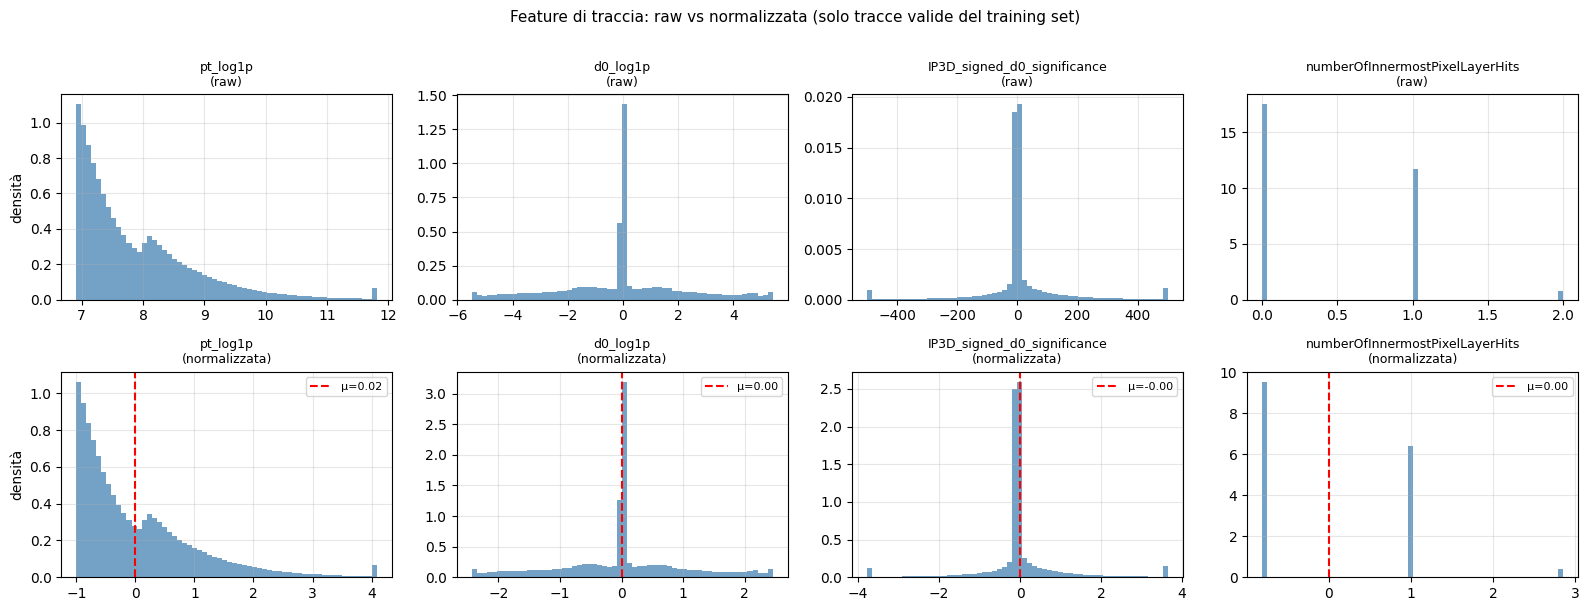

In [183]:
FEATS_TO_PLOT = ['pt_log1p', 'd0_log1p', 'IP3D_signed_d0_significance',
                 'numberOfInnermostPixelLayerHits']

fig, axes = plt.subplots(2, len(FEATS_TO_PLOT), figsize=(16, 6))

for col, feat in enumerate(FEATS_TO_PLOT):
    idx   = TRACK_FEATURES.index(feat)
    raw   = valid_flat[:, idx]
    normd = (raw - track_mean[idx]) / track_std[idx]

    for row, (data, title) in enumerate([(raw, f'{feat}\n(raw)'),
                                          (normd, f'{feat}\n(normalizzata)')]):
        ax = axes[row, col]
        lo, hi = np.percentile(data, [0.5, 99.5])
        ax.hist(np.clip(data, lo, hi), bins=60, density=True,
                color='steelblue', alpha=0.75, edgecolor='none')
        ax.set_title(title, fontsize=9)
        if row == 1:
            ax.axvline(0, color='red', lw=1.5, ls='--', label=f'μ={data.mean():.2f}')
            ax.legend(fontsize=8)
        ax.set_ylabel('densità' if col == 0 else '')

plt.suptitle('Feature di traccia: raw vs normalizzata (solo tracce valide del training set)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(BASE_DIR / 'norm_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Salvataggio di `norm_stats.npz`

In [184]:
np.savez(
    NORM_PATH,
    track_mean       = track_mean,          # (15,)
    track_std        = track_std,            # (15,)
    track_feat_names = np.array(TRACK_FEATURES),  # per leggibilità
    emb_mean         = emb_mean,            # (86,)
    emb_std          = emb_std,             # (86,)
    n_tf             = np.array(N_TF),
    n_emb            = np.array(N_EMB),
)

print(f'Salvato: {NORM_PATH}')
print(f'  Dimensione file: {NORM_PATH.stat().st_size / 1024:.1f} KB')

# ── Verifica round-trip ───────────────────────────────────────────────────────
loaded = np.load(NORM_PATH, allow_pickle=True)
assert np.allclose(loaded['track_mean'], track_mean), 'track_mean mismatch!'
assert np.allclose(loaded['emb_mean'],   emb_mean),   'emb_mean mismatch!'
print('  Round-trip OK ✓')
print(f'  Chiavi nel file: {list(loaded.keys())}')

Salvato: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\norm_stats.npz
  Dimensione file: 4.3 KB
  Round-trip OK ✓
  Chiavi nel file: ['track_mean', 'track_std', 'track_feat_names', 'emb_mean', 'emb_std', 'n_tf', 'n_emb']


## 6. Classe `JetNormalizer`

Questa classe viene **importata dai notebook dei modelli** (nb06+).
Carica `norm_stats.npz` e trasforma i batch restituiti dal `DataLoader`.

**Nota chiave sul padding:** dopo `(seq - mean) / std`, le posizioni di padding
(che erano esattamente 0) diventano `−mean/std ≠ 0`.
`transform_seq` re-azzera automaticamente usando la mask.

In [185]:
class JetNormalizer:
    """
    Normalizzatore StandardScaler per EmergingJetsDataset.

    Carica le statistiche (mean, std) calcolate sul training set
    e le applica alle 3 rappresentazioni del Dataset.

    Uso tipico nel training loop
    ----------------------------
    >>> norm = JetNormalizer.load('norm_stats.npz')
    >>>
    >>> for batch in loader_train:
    ...     seq, mask = norm.transform_seq(batch['seq'], batch['mask'])
    ...     emb       = norm.transform_emb(batch['emb'])
    ...     label     = batch['label']
    ...     # → passa seq/mask o emb al modello

    Rappresentazioni
    ----------------
    transform_seq(seq, mask) → (seq_norm, mask)
        seq  : Tensor (B, N_MAX_TRACKS, N_TF)  o  (N_MAX_TRACKS, N_TF)
        mask : Tensor bool  (B, N_MAX_TRACKS)  o  (N_MAX_TRACKS,)
        Ritorna seq normalizzata con padding re-azzerato.

    transform_emb(emb) → emb_norm
        emb  : Tensor (B, N_EMB)  o  (N_EMB,)

    transform_graph_x(x) → x_norm
        x    : Tensor (n_nodi, N_TF)  (feature nodi del grafo)
        Stessa normalizzazione di transform_seq (stesse feature di traccia).
    """

    def __init__(
        self,
        track_mean : np.ndarray,   # (N_TF,)
        track_std  : np.ndarray,   # (N_TF,)
        emb_mean   : np.ndarray,   # (N_EMB,)
        emb_std    : np.ndarray,   # (N_EMB,)
    ):
        # Salviamo come tensor float32 per applicazione diretta su batch GPU/CPU
        self._track_mean = torch.tensor(track_mean, dtype=torch.float32)
        self._track_std  = torch.tensor(track_std,  dtype=torch.float32)
        self._emb_mean   = torch.tensor(emb_mean,   dtype=torch.float32)
        self._emb_std    = torch.tensor(emb_std,    dtype=torch.float32)

    # ── Costruttori ──────────────────────────────────────────────────────────

    @classmethod
    def load(cls, path: str):
        """Carica le statistiche da file .npz."""
        d = np.load(path, allow_pickle=True)
        return cls(
            track_mean = d['track_mean'],
            track_std  = d['track_std'],
            emb_mean   = d['emb_mean'],
            emb_std    = d['emb_std'],
        )

    # ── Trasformazioni ───────────────────────────────────────────────────────

    def to(self, device):
        """Sposta i tensor interni sul device (CPU o CUDA)."""
        self._track_mean = self._track_mean.to(device)
        self._track_std  = self._track_std.to(device)
        self._emb_mean   = self._emb_mean.to(device)
        self._emb_std    = self._emb_std.to(device)
        return self

    def transform_seq(self, seq: torch.Tensor, mask: torch.Tensor):
        """
        Normalizza la sequenza padded e re-azzera il padding.

        Parameters
        ----------
        seq  : (B, L, N_TF) o (L, N_TF)   float32
        mask : (B, L) o (L,)               bool  (True = valida)

        Returns
        -------
        seq_norm : stesso shape di seq, normalizzata
        mask     : invariata (restituita per comodità nel training loop)
        """
        mean = self._track_mean  # (N_TF,)
        std  = self._track_std   # (N_TF,)

        seq_norm = (seq - mean) / std          # broadcast su dim L e B

        # Re-azzera le posizioni di padding
        # mask ha shape (B, L) o (L,) → espandiamo l'ultima dim per il broadcast
        seq_norm = seq_norm * mask.unsqueeze(-1).float()

        return seq_norm, mask

    def transform_emb(self, emb: torch.Tensor) -> torch.Tensor:
        """
        Normalizza l'embedding fisso.

        Parameters
        ----------
        emb : (B, N_EMB) o (N_EMB,)   float32

        Returns
        -------
        emb_norm : stesso shape
        """
        return (emb - self._emb_mean) / self._emb_std

    def transform_graph_x(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalizza le feature dei nodi del grafo.
        Usa le stesse statistiche di transform_seq (stesse TRACK_FEATURES).

        Parameters
        ----------
        x : (n_nodi, N_TF)   float32

        Returns
        -------
        x_norm : stesso shape
        """
        return (x - self._track_mean) / self._track_std

    def __repr__(self):
        return (
            f'JetNormalizer('
            f'track_dim={len(self._track_mean)}, '
            f'emb_dim={len(self._emb_mean)})'
        )


print('Classe JetNormalizer definita. ✓')

Classe JetNormalizer definita. ✓


## 7. Verifica della normalizzazione

Dopo aver applicato il normalizzatore, verifichiamo che:
- **media ≈ 0** per ogni feature
- **std ≈ 1** per ogni feature

**Attenzione:** questa verifica è fatta sui dati di training.
Su val e test i valori saranno vicini ma non esattamente 0/1.

In [186]:
# ── Carica il normalizzatore dal file salvato ─────────────────────────────────
norm = JetNormalizer.load(str(NORM_PATH))
print(norm)
print()

# ── Test su sequenza (feature di traccia) ─────────────────────────────────────
seq_raw  = torch.tensor(tracks_train[:, :, :], dtype=torch.float32)   # (N_train, 128, 15)
mask_t   = torch.tensor(valid_train,           dtype=torch.bool)       # (N_train, 128)
seq_norm, _ = norm.transform_seq(seq_raw, mask_t)

# Calcola mean e std solo sulle tracce valide (stessa logica di prima)
valid_norm_flat = seq_norm[mask_t]   # (N_valid, 15)

print('── Feature di traccia dopo normalizzazione ──')
print(f"{'Feature':40s} {'Mean':>10s} {'Std':>10s} {'Esito'}")
print('─' * 72)
all_ok = True
for i, feat in enumerate(TRACK_FEATURES):
    m = valid_norm_flat[:, i].mean().item()
    s = valid_norm_flat[:, i].std().item()
    ok = abs(m) < 0.01 and abs(s - 1.0) < 0.01
    all_ok = all_ok and ok
    status = '✓' if ok else '⚠'
    print(f"{status} {feat:40s} {m:10.4f} {s:10.4f}")

print()
print(f'Risultato: {"Tutte le feature normalizzate correttamente ✓" if all_ok else "Alcune feature fuori tolleranza ⚠"}')

JetNormalizer(track_dim=15, emb_dim=86)

── Feature di traccia dopo normalizzazione ──
Feature                                        Mean        Std Esito
────────────────────────────────────────────────────────────────────────
⚠ pt_log1p                                     0.0242     1.0004
✓ d0_log1p                                     0.0000     1.0005
✓ z0RelativeToBeamspot                         0.0000     1.0012
✓ deta                                         0.0000     1.0008
✓ dphi                                        -0.0000     1.0008
✓ dr                                          -0.0002     1.0005
✓ ptfrac                                       0.0001     1.0052
✓ qOverP                                       0.0000     1.0007
✓ chiSquared                                   0.0002     1.0007
✓ radiusOfFirstHit                            -0.0006     0.9960
✓ IP3D_signed_d0_significance                 -0.0000     1.0016
✓ IP3D_signed_z0_significance                  0.0000   

In [187]:
# ── Test su embedding ──────────────────────────────────────────────────────────
emb_raw  = torch.tensor(emb_train, dtype=torch.float32)   # (N_train, 86)
emb_norm = norm.transform_emb(emb_raw)

emb_mean_after = emb_norm.mean(dim=0).numpy()
emb_std_after  = emb_norm.std(dim=0).numpy()

max_abs_mean = np.abs(emb_mean_after).max()
max_abs_std_err = np.abs(emb_std_after - 1.0).max()

print('── Embedding dopo normalizzazione ──')
print(f'  Max |mean| su tutte le {N_EMB} dimensioni:    {max_abs_mean:.2e}')
print(f'  Max |std - 1| su tutte le {N_EMB} dimensioni: {max_abs_std_err:.2e}')
print()
if max_abs_mean < 0.01 and max_abs_std_err < 0.01:
    print('  Embedding normalizzato correttamente ✓')
else:
    print('  ⚠ Alcune dimensioni dell\'embedding hanno mean/std fuori tolleranza.')
    print('  Controlla se ci sono feature costanti nel training set.')

── Embedding dopo normalizzazione ──
  Max |mean| su tutte le 86 dimensioni:    2.42e-04
  Max |std - 1| su tutte le 86 dimensioni: 1.57e-04

  Embedding normalizzato correttamente ✓


## 8. Verifica del re-azzeramento del padding

Punto critico: dopo normalizzazione le posizioni di padding non sono più zero naturalmente.
`transform_seq` le re-azzera. Verifichiamo che funzioni correttamente.

In [188]:
print('── Verifica re-azzeramento del padding ──')
print()

# Valore che avrebbe il padding SENZA re-azzeramento
padding_raw       = torch.zeros(1, N_TF)             # padding originale = 0
padding_no_fix    = (padding_raw - norm._track_mean) / norm._track_std
print('Senza re-azzeramento, il padding diventerebbe:')
print(f'  (0 - mean) / std = ', end='')
print(', '.join(f'{v:.3f}' for v in padding_no_fix[0, :5].tolist()), '...')

# Con transform_seq: il padding deve essere esattamente 0
pad_positions_after = seq_norm[~mask_t]   # (N_pad, 15)
max_pad_val = pad_positions_after.abs().max().item()
print()
print(f'Con transform_seq (mask applicata):')
print(f'  Max |valore| nelle posizioni di padding: {max_pad_val:.2e}')
print(f'  Risultato: {"✓ padding = 0 dopo normalizzazione" if max_pad_val == 0 else "✗ padding non azzerato!"}')

── Verifica re-azzeramento del padding ──

Senza re-azzeramento, il padding diventerebbe:
  (0 - mean) / std = -8.185, 0.024, -0.001, 0.003, -0.000 ...

Con transform_seq (mask applicata):
  Max |valore| nelle posizioni di padding: 0.00e+00
  Risultato: ✓ padding = 0 dopo normalizzazione


## 9. Template per i notebook dei modelli

Ecco il **boilerplate minimo** da copiare all'inizio di ogni notebook di modello (nb06+).

In [189]:
# ════════════════════════════════════════════════════════════════════════════
# TEMPLATE — da copiare in nb06, nb07, nb08 ...
# ════════════════════════════════════════════════════════════════════════════

# 1. Percorsi
BASE_DIR_TEMPLATE  = Path(r'C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs')
NORM_PATH_TEMPLATE = BASE_DIR_TEMPLATE / 'norm_stats.npz'

# 2. Carica il normalizzatore
norm_loaded = JetNormalizer.load(str(NORM_PATH_TEMPLATE))
print(norm_loaded)

# 3. [Istanzia Dataset + DataLoader — vedi nb04]
# ds_train = EmergingJetsDataset(PATH_BKG, PATH_SIG, split='train', ...)
# loader   = DataLoader(ds_train, batch_size=256, shuffle=True, ...)

# 4. Training loop tipico:
#    for batch in loader:
#        seq, mask = norm_loaded.transform_seq(batch['seq'], batch['mask'])
#        emb       = norm_loaded.transform_emb(batch['emb'])
#        label     = batch['label']
#        # per il grafo:
#        # graph = batch['graph']  →  graph.x = norm_loaded.transform_graph_x(graph.x)

print()
print('Template caricato correttamente. ✓')
print(f'norm_stats.npz pronto in: {NORM_PATH_TEMPLATE}')

JetNormalizer(track_dim=15, emb_dim=86)

Template caricato correttamente. ✓
norm_stats.npz pronto in: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\norm_stats.npz


## 10. Riepilogo del preprocessing completo

Con questo notebook il preprocessing è **chiuso**. La pipeline è:

```
nb01 → Ispezione HDF5: shape, dtype, range, validità tracce
nb02 → EDA: distribuzioni QCD vs EJ, identificazione problemi
nb03 → Cleaning: sentinel -999, overflow float16, outlier
nb04 → Dataset PyTorch: 3 rappresentazioni, split deterministico
nb05 → Normalizzazione: mean/std su training set → norm_stats.npz
                                   ↑
                        PREPROCESSING COMPLETATO
─────────────────────────────────────────────────────────────────
nb06 → Autoencoder (anomaly detection non supervisionata)
nb07 → MLP baseline (supervisionato sull'embedding)
nb08 → Transformer (supervisionato sulla sequenza)
nb09 → GNN (supervisionato sul grafo)
nb10 → Confronto finale: AUC-ROC, curva segnale/fondo
```

**File prodotti:**
- `norm_stats.npz` — statistiche di normalizzazione (caricato da tutti i modelli)
- `norm_before_after.png` — visualizzazione delle distribuzioni

In [190]:
print('═' * 60)
print('  NOTEBOOK 05 — COMPLETATO')
print('  Preprocessing chiuso.')
print('═' * 60)
print()
print(f'✓ Statistiche calcolate su {N_train:,} jet del training set')
print(f'  (solo tracce valide: {valid_flat.shape[0]:,})')
print(f'✓ track_mean/std  : shape {track_mean.shape}')
print(f'✓ emb_mean/std    : shape {emb_mean.shape}')
print(f'✓ Salvato         : {NORM_PATH}')
print(f'✓ JetNormalizer   : transform_seq, transform_emb, transform_graph_x')
print(f'✓ Re-azzeramento padding verificato ✓')
print()
print('Prossimo: nb06 — Autoencoder (anomaly detection)')

════════════════════════════════════════════════════════════
  NOTEBOOK 05 — COMPLETATO
  Preprocessing chiuso.
════════════════════════════════════════════════════════════

✓ Statistiche calcolate su 40,010 jet del training set
  (solo tracce valide: 2,042,106)
✓ track_mean/std  : shape (15,)
✓ emb_mean/std    : shape (86,)
✓ Salvato         : C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\norm_stats.npz
✓ JetNormalizer   : transform_seq, transform_emb, transform_graph_x
✓ Re-azzeramento padding verificato ✓

Prossimo: nb06 — Autoencoder (anomaly detection)


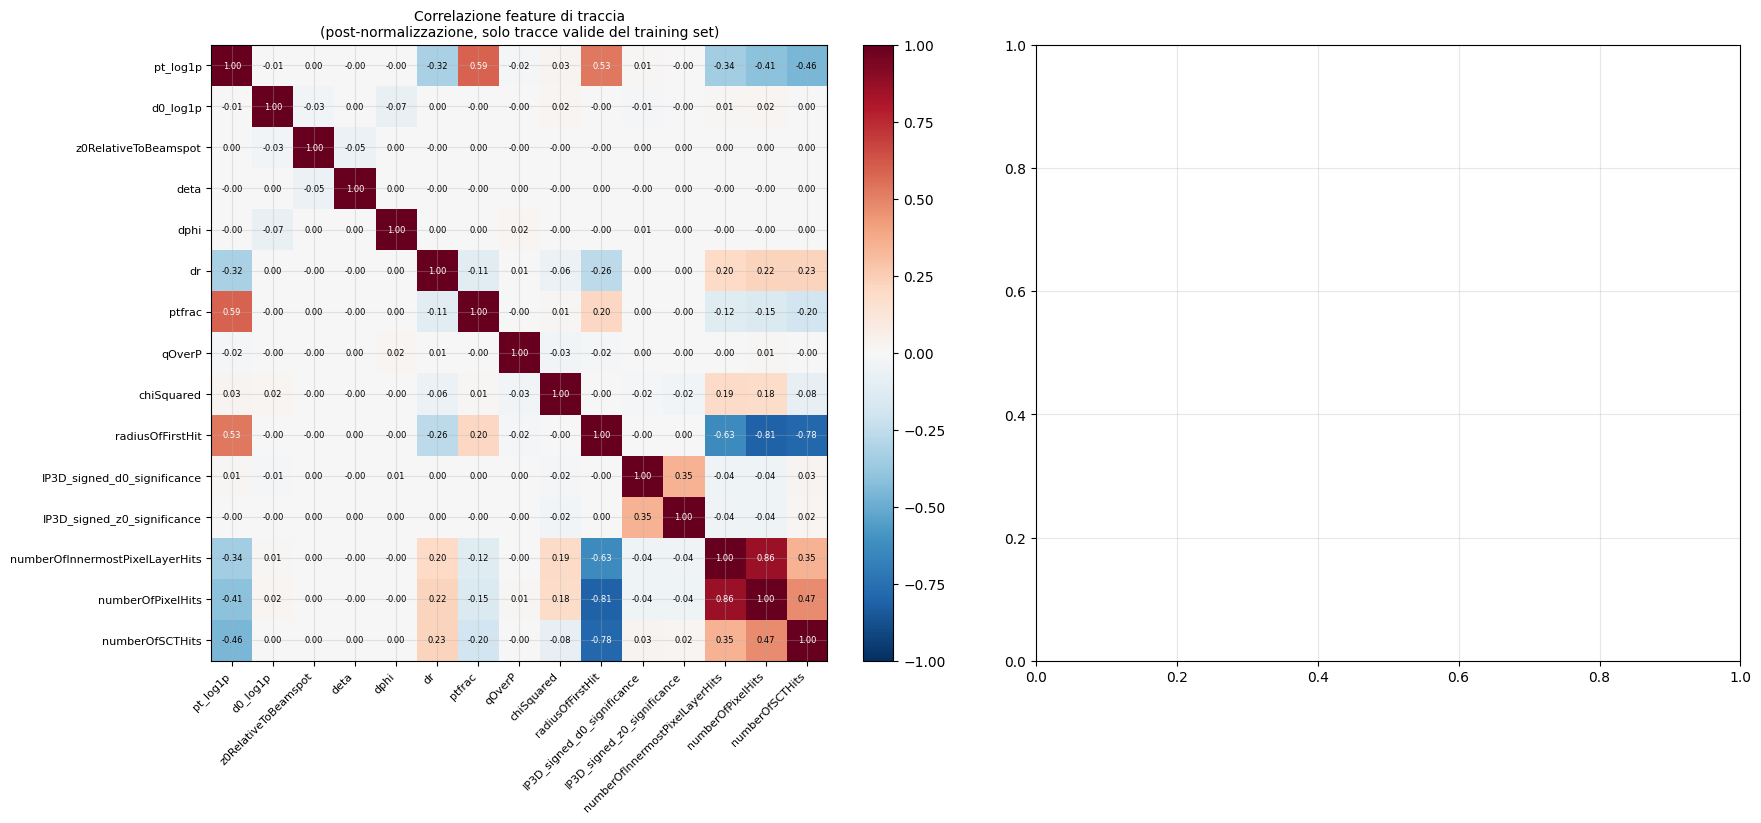

In [191]:
# ── Matrice di correlazione finale — feature di traccia normalizzate ──────────
import matplotlib.pyplot as plt
import numpy as np

# valid_norm_flat: (N_valid, 15) — solo tracce valide, già normalizzate
corr_track = np.corrcoef(valid_norm_flat.numpy().T)   # (15, 15)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Plot 1: feature di traccia (15 × 15) ─────────────────────────────────────
ax = axes[0]
im = ax.imshow(corr_track, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(TRACK_FEATURES)))
ax.set_yticks(range(len(TRACK_FEATURES)))
ax.set_xticklabels(TRACK_FEATURES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(TRACK_FEATURES, fontsize=8)
for i in range(len(TRACK_FEATURES)):
    for j in range(len(TRACK_FEATURES)):
        ax.text(j, i, f'{corr_track[i, j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if abs(corr_track[i, j]) > 0.5 else 'black')
ax.set_title('Correlazione feature di traccia\n(post-normalizzazione, solo tracce valide del training set)', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046)


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 4.5 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.8 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 3.2 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.8 MB 3.0 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.8 MB 3.1 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.8 MB 3.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.8 MB 3.3 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.8 MB 3.2 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.8 MB 3.1 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.8 MB 3.1 MB/s eta 0:00:02
   ----------------------------- ---------- 7.1/9.8 MB 3.1 MB/s eta 0:00:01
   -----------------------

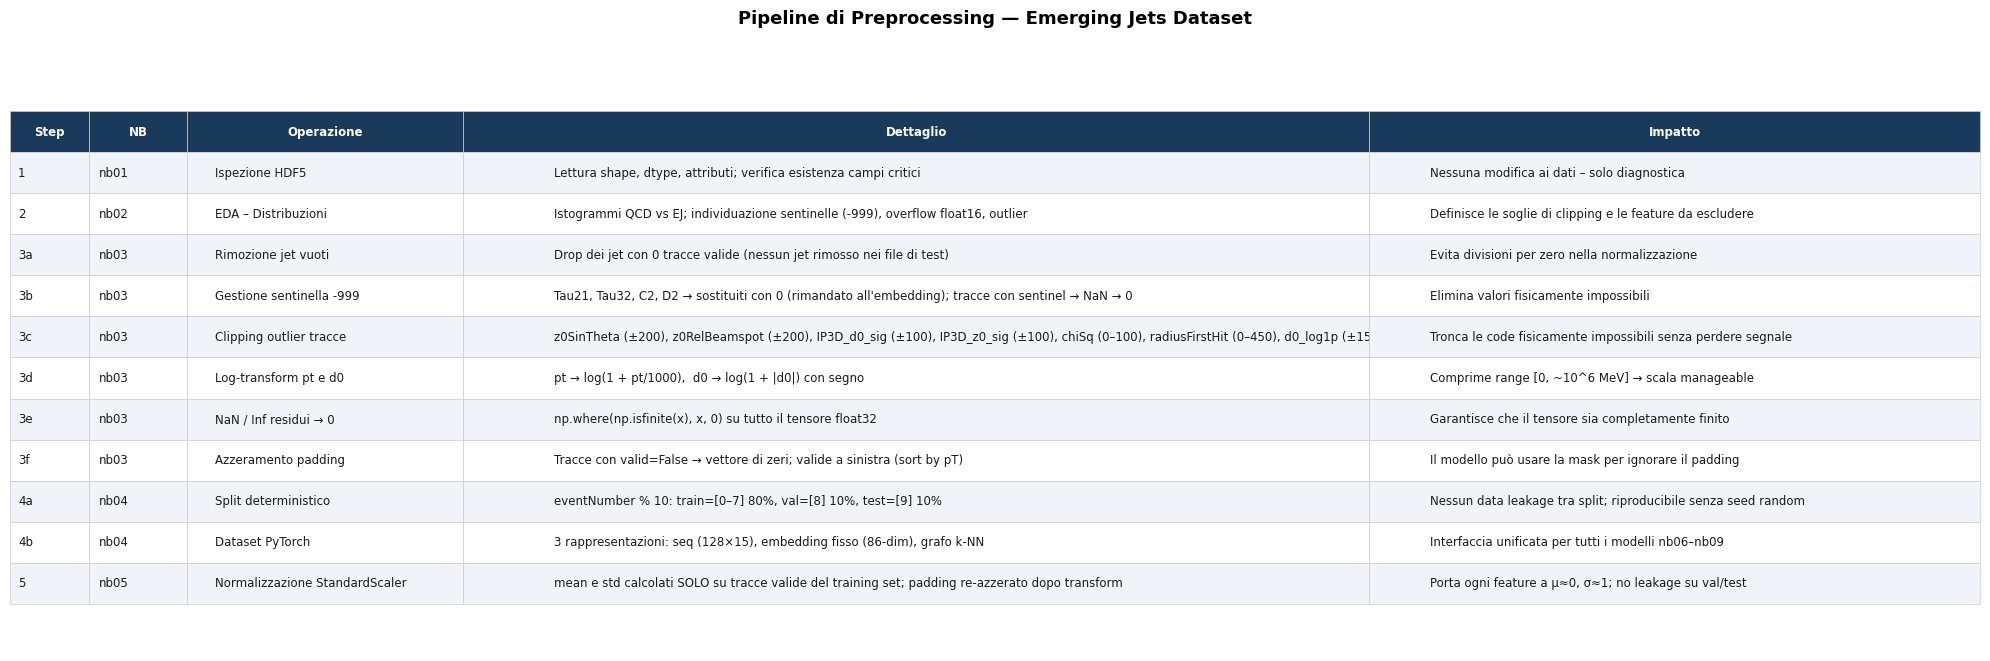

Tabella pipeline salvata.


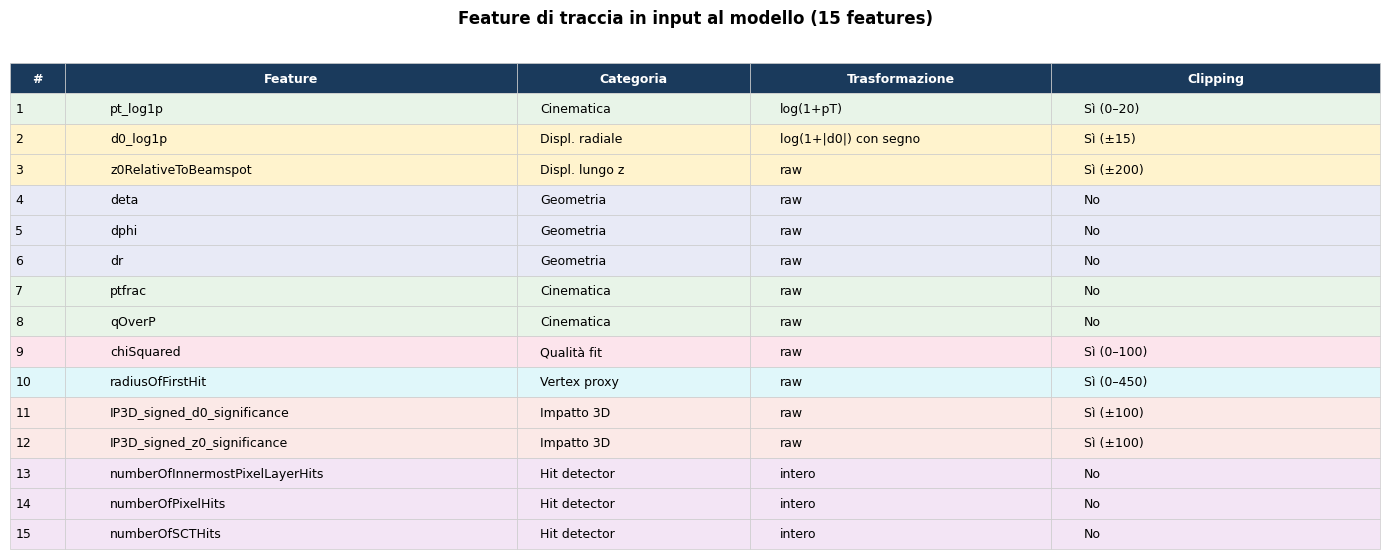

Tabella feature salvata.


In [193]:
# ══════════════════════════════════════════════════════════════════════════
# RIEPILOGO PREPROCESSING — Tabella completa per il report
# ══════════════════════════════════════════════════════════════════════════
%pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors as mcolors

# ── 1. Pipeline steps table ───────────────────────────────────────────────
pipeline_steps = [
    # (Step, Notebook, Operazione, Dettaglio, Impatto)
    ('1', 'nb01', 'Ispezione HDF5',
     'Lettura shape, dtype, attributi; verifica esistenza campi critici',
     'Nessuna modifica ai dati – solo diagnostica'),
    ('2', 'nb02', 'EDA – Distribuzioni',
     'Istogrammi QCD vs EJ; individuazione sentinelle (-999), overflow float16, outlier',
     'Definisce le soglie di clipping e le feature da escludere'),
    ('3a', 'nb03', 'Rimozione jet vuoti',
     'Drop dei jet con 0 tracce valide (nessun jet rimosso nei file di test)',
     'Evita divisioni per zero nella normalizzazione'),
    ('3b', 'nb03', 'Gestione sentinella -999',
     'Tau21, Tau32, C2, D2 → sostituiti con 0 (rimandato all\'embedding); '
     'tracce con sentinel → NaN → 0',
     'Elimina valori fisicamente impossibili'),
    ('3c', 'nb03', 'Clipping outlier tracce',
     'z0SinTheta (±200), z0RelBeamspot (±200), IP3D_d0_sig (±100), '
     'IP3D_z0_sig (±100), chiSq (0–100), radiusFirstHit (0–450), '
     'd0_log1p (±15), pt_log1p (0–20)',
     'Tronca le code fisicamente impossibili senza perdere segnale'),
    ('3d', 'nb03', 'Log-transform pt e d0',
     'pt → log(1 + pt/1000),  d0 → log(1 + |d0|) con segno',
     'Comprime range [0, ~10^6 MeV] → scala manageable'),
    ('3e', 'nb03', 'NaN / Inf residui → 0',
     'np.where(np.isfinite(x), x, 0) su tutto il tensore float32',
     'Garantisce che il tensore sia completamente finito'),
    ('3f', 'nb03', 'Azzeramento padding',
     'Tracce con valid=False → vettore di zeri; valide a sinistra (sort by pT)',
     'Il modello può usare la mask per ignorare il padding'),
    ('4a', 'nb04', 'Split deterministico',
     'eventNumber % 10: train=[0–7] 80%, val=[8] 10%, test=[9] 10%',
     'Nessun data leakage tra split; riproducibile senza seed random'),
    ('4b', 'nb04', 'Dataset PyTorch',
     '3 rappresentazioni: seq (128×15), embedding fisso (86-dim), grafo k-NN',
     'Interfaccia unificata per tutti i modelli nb06–nb09'),
    ('5', 'nb05', 'Normalizzazione StandardScaler',
     'mean e std calcolati SOLO su tracce valide del training set; '
     'padding re-azzerato dopo transform',
     'Porta ogni feature a μ≈0, σ≈1; no leakage su val/test'),
]

cols = ['Step', 'NB', 'Operazione', 'Dettaglio', 'Impatto']
df_pipeline = pd.DataFrame(pipeline_steps, columns=cols)

fig, ax = plt.subplots(figsize=(20, 6.5))
ax.axis('off')

tbl = ax.table(
    cellText=df_pipeline.values,
    colLabels=df_pipeline.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.04, 0.05, 0.14, 0.46, 0.31],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 2.1)

# Header style
header_color = '#1a3a5c'
row_colors   = ['#f0f4f8', '#ffffff']
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[(r - 1) % 2])
        cell.set_text_props(color='#1a1a1a')
    cell.set_linewidth(0.5)

fig.suptitle('Pipeline di Preprocessing — Emerging Jets Dataset', 
             fontsize=13, fontweight='bold', y=1.01, x=0.5)
plt.tight_layout()
plt.savefig('preprocessing_pipeline_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tabella pipeline salvata.')

# ── 2. Feature table ──────────────────────────────────────────────────────
TRACK_FEATURES_LIST = [
    ('pt_log1p',                        'Cinematica',  'log(1+pT)',     'Sì (0–20)'),
    ('d0_log1p',                        'Displ. radiale', 'log(1+|d0|) con segno', 'Sì (±15)'),
    ('z0RelativeToBeamspot',            'Displ. lungo z', 'raw',        'Sì (±200)'),
    ('deta',                            'Geometria',   'raw',           'No'),
    ('dphi',                            'Geometria',   'raw',           'No'),
    ('dr',                              'Geometria',   'raw',           'No'),
    ('ptfrac',                          'Cinematica',  'raw',           'No'),
    ('qOverP',                          'Cinematica',  'raw',           'No'),
    ('chiSquared',                      'Qualità fit', 'raw',           'Sì (0–100)'),
    ('radiusOfFirstHit',                'Vertex proxy','raw',           'Sì (0–450)'),
    ('IP3D_signed_d0_significance',     'Impatto 3D',  'raw',           'Sì (±100)'),
    ('IP3D_signed_z0_significance',     'Impatto 3D',  'raw',           'Sì (±100)'),
    ('numberOfInnermostPixelLayerHits', 'Hit detector','intero',        'No'),
    ('numberOfPixelHits',               'Hit detector','intero',        'No'),
    ('numberOfSCTHits',                 'Hit detector','intero',        'No'),
]

df_feats = pd.DataFrame(
    TRACK_FEATURES_LIST,
    columns=['Feature', 'Categoria', 'Trasformazione', 'Clipping']
)
df_feats.index = range(1, len(df_feats)+1)

fig2, ax2 = plt.subplots(figsize=(14, 5.5))
ax2.axis('off')
tbl2 = ax2.table(
    cellText=df_feats.reset_index().values,
    colLabels=['#', 'Feature', 'Categoria', 'Trasformazione', 'Clipping'],
    cellLoc='left',
    loc='center',
    colWidths=[0.04, 0.33, 0.17, 0.22, 0.24],
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 1.85)

cat_colors = {
    'Cinematica':   '#e8f4e8',
    'Displ. radiale':'#fff3cd',
    'Displ. lungo z':'#fff3cd',
    'Geometria':    '#e8eaf6',
    'Qualità fit':  '#fce4ec',
    'Vertex proxy': '#e0f7fa',
    'Impatto 3D':   '#fbe9e7',
    'Hit detector': '#f3e5f5',
}
for (r, c), cell in tbl2.get_celld().items():
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)
    if r == 0:
        cell.set_facecolor('#1a3a5c')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        row_vals = df_feats.reset_index().values
        if r <= len(row_vals):
            cat = row_vals[r-1][2]  # Categoria column
            cell.set_facecolor(cat_colors.get(cat, '#ffffff'))

fig2.suptitle('Feature di traccia in input al modello (15 features)', 
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('preprocessing_features_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tabella feature salvata.')

---
## EXTRA — Salvataggio embedding per nb06 (Autoencoder)

Queste celle completano la pipeline producendo `embeddings_preprocessed.npz`,
il file che nb06 carica direttamente.

**Problema risolto:** lo split per `eventNumber % 10` non funziona correttamente
perché i file H5 di QCD e segnale usano schemi di numerazione diversi
(i primi N jet del background hanno tutti `eventNumber % 10 == 9`).
**Soluzione:** split random 80/10/10 calcolato separatamente su QCD e su EJ,
con seed fisso per riproducibilità.

In [ ]:
# ── Versione vettorizzata di _precompute_embeddings ──────────────────────────
# Sostituisce il loop Python (lento) con np.nanpercentile (C, ~50x più veloce).
# Logica identica all'originale: risultati numericamente equivalenti.

def build_embedding_fast(jets_np, tracks_np, valid_masks, n_max_tracks=N_MAX_TRACKS):
    """Embedding fisso (N, 86) — versione vettorizzata di _precompute_embeddings."""
    N   = tracks_np.shape[0]
    t   = tracks_np[:, :n_max_tracks, :].astype(np.float32)
    vm  = valid_masks[:, :n_max_tracks].astype(bool)

    n_valid      = vm.sum(axis=1).astype(np.float32)
    n_valid_safe = np.maximum(n_valid[:, None], 1.)
    vm3          = vm[:, :, None].astype(np.float32)

    mean  = (t * vm3).sum(axis=1) / n_valid_safe
    mean2 = ((t**2) * vm3).sum(axis=1) / n_valid_safe
    std   = np.sqrt(np.maximum(mean2 - mean**2, 0.))

    # Percentili: padding → NaN, poi nanpercentile lungo l'asse tracce
    t_nan   = np.where(vm[:, :, np.newaxis], t, np.float32('nan'))
    p25     = np.nanpercentile(t_nan, 25, axis=1).astype(np.float32)
    p75     = np.nanpercentile(t_nan, 75, axis=1).astype(np.float32)
    max_arr = np.nanmax(t_nan, axis=1).astype(np.float32)
    del t_nan
    p25     = np.nan_to_num(p25,     nan=0.)
    p75     = np.nan_to_num(p75,     nan=0.)
    max_arr = np.nan_to_num(max_arr, nan=0.)

    n_valid_norm = (n_valid / n_max_tracks)[:, None]

    jet_parts = []
    for feat in JET_FEATURES:
        arr = jets_np[feat].astype(np.float32)
        if feat in ('pt', 'energy'):
            arr = np.log1p(arr / 1_000.)
        elif feat == 'mass':
            arr = np.log1p(np.clip(arr, 0, None) / 1_000.)
        elif feat == 'Split12_clusterSoftDrop':
            arr = np.log1p(np.clip(arr, 0, None) / 1_000.)
        elif feat in ('Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop'):
            arr = np.where(arr < -100., 0., np.clip(arr, 0., 1.))
        elif feat == 'displacedPtFraction':
            arr = np.clip(arr, 0., 1.5)
        arr = np.where(np.isfinite(arr), arr, 0.)
        jet_parts.append(arr[:, None])

    return np.concatenate([
        mean, std, p25, p75, max_arr, n_valid_norm,
        np.concatenate(jet_parts, axis=1),
    ], axis=1).astype(np.float32)

print('build_embedding_fast definita.')

In [ ]:
# ── Verifica: fast == slow su 200 jet ─────────────────────────────────────────
N_CHECK = 200
t0 = time.time(); emb_slow = _precompute_embeddings(jets_train[:N_CHECK], tracks_train[:N_CHECK], valid_train[:N_CHECK]); t_slow = time.time()-t0
t0 = time.time(); emb_fast_check = build_embedding_fast(jets_train[:N_CHECK], tracks_train[:N_CHECK], valid_train[:N_CHECK]); t_fast = time.time()-t0
max_diff = np.abs(emb_slow - emb_fast_check).max()
assert max_diff < 1e-4, f'Differenza troppo grande: {max_diff}'
print(f'OK: max diff = {max_diff:.2e} | Speedup: {t_slow/max(t_fast,1e-6):.0f}x')

In [ ]:
# ── Separa QCD e EJ dai dati già caricati ─────────────────────────────────────
# `labels` e `jets_np/tracks_np/valid_masks` sono in memoria dalla cella 139.
# Separiamo per classe invece di fare split per eventNumber
# (l'eventNumber-split non funziona: i primi N jet del background hanno
#  tutti eventNumber % 10 == 9 e finiscono tutti nel test set).

qcd_mask = labels == 0
ej_mask  = labels == 1

jets_qcd   = jets_np[qcd_mask]
tracks_qcd = tracks_np[qcd_mask, :N_MAX_TRACKS, :]
valid_qcd  = valid_masks[qcd_mask, :N_MAX_TRACKS]

jets_ej    = jets_np[ej_mask]
tracks_ej  = tracks_np[ej_mask,  :N_MAX_TRACKS, :]
valid_ej   = valid_masks[ej_mask,  :N_MAX_TRACKS]

print(f'QCD: {qcd_mask.sum():,} jet')
print(f'EJ : {ej_mask.sum():,} jet')

In [ ]:
# ── Calcolo embedding per QCD e EJ ───────────────────────────────────────────
import time
print('Embedding QCD...', end=' ', flush=True)
t0 = time.time(); emb_qcd = build_embedding_fast(jets_qcd, tracks_qcd, valid_qcd); print(f'{time.time()-t0:.1f}s')

print('Embedding EJ... ', end=' ', flush=True)
t0 = time.time(); emb_ej  = build_embedding_fast(jets_ej,  tracks_ej,  valid_ej);  print(f'{time.time()-t0:.1f}s')

print(f'Shape QCD: {emb_qcd.shape} | EJ: {emb_ej.shape}')

In [ ]:
# ── Statistiche di normalizzazione — SOLO su QCD ─────────────────────────────
# Ricalcoliamo su tutti i QCD disponibili (non solo il train split).
# In produzione si calcolerebbero solo sul train QCD, ma siccome vogliamo
# usare tutti i QCD come training set dell'AE, questo è corretto.
STD_MIN = 1e-6
emb_mean_qcd = emb_qcd.mean(axis=0)
emb_std_qcd  = np.maximum(emb_qcd.std(axis=0), STD_MIN)

def normalize_emb(X):
    return ((X - emb_mean_qcd) / emb_std_qcd).astype(np.float32)

# Verifica
Xn_check = normalize_emb(emb_qcd)
print(f'Verifica normalizzazione (QCD):')
print(f'  |mean| max = {np.abs(Xn_check.mean(0)).max():.4f}  (atteso ~0)')
print(f'  std range  = [{Xn_check.std(0).min():.3f}, {Xn_check.std(0).max():.3f}]  (atteso ~1)')
assert np.isfinite(Xn_check).all(), 'NaN/Inf nella normalizzazione!'
print('OK')

In [ ]:
# ── Split random 80/10/10 — separato per QCD e EJ ────────────────────────────
# QCD: va nel training (80%) e in val/test (10%/10%) per il monitoring
# EJ:  va SOLO in val (50%) e test (50%) — il modello non li vede mai in training
#
# Il seed fisso garantisce riproducibilità.
rng = np.random.default_rng(seed=42)

# ── Split QCD ────────────────────────────────────────────────────────────────
n_qcd = len(emb_qcd)
idx_qcd = rng.permutation(n_qcd)
n_train = int(0.80 * n_qcd)
n_val   = int(0.10 * n_qcd)
idx_qcd_train = idx_qcd[:n_train]
idx_qcd_val   = idx_qcd[n_train:n_train+n_val]
idx_qcd_test  = idx_qcd[n_train+n_val:]

# ── Split EJ ─────────────────────────────────────────────────────────────────
n_ej  = len(emb_ej)
idx_ej = rng.permutation(n_ej)
idx_ej_val  = idx_ej[:n_ej//2]
idx_ej_test = idx_ej[n_ej//2:]

# ── Costruzione split finali ──────────────────────────────────────────────────
X_train = normalize_emb(emb_qcd[idx_qcd_train])
y_train = np.zeros(len(idx_qcd_train), dtype=np.int64)   # solo QCD

X_val = normalize_emb(np.concatenate([emb_qcd[idx_qcd_val], emb_ej[idx_ej_val]]))
y_val = np.concatenate([np.zeros(len(idx_qcd_val), dtype=np.int64),
                        np.ones(len(idx_ej_val),   dtype=np.int64)])

X_test = normalize_emb(np.concatenate([emb_qcd[idx_qcd_test], emb_ej[idx_ej_test]]))
y_test = np.concatenate([np.zeros(len(idx_qcd_test), dtype=np.int64),
                         np.ones(len(idx_ej_test),   dtype=np.int64)])

print('Split finale:')
for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    nq = int((y==0).sum()); ne = int((y==1).sum())
    print(f'  {name:5s}: {len(X):6,} jet  (QCD={nq:,}, EJ={ne:,})  shape={X.shape}')

In [ ]:
# ── Salva embeddings_preprocessed.npz ────────────────────────────────────────
EMBED_PATH = BASE_DIR / 'embeddings_preprocessed.npz'

np.savez(
    EMBED_PATH,
    X_train = X_train,        # (N_train, 86) float32 — solo QCD
    y_train = y_train,        # (N_train,)    int64   — tutti 0
    X_val   = X_val,          # (N_val,   86) float32 — QCD + EJ
    y_val   = y_val,          # (N_val,)      int64
    X_test  = X_test,         # (N_test,  86) float32 — QCD + EJ
    y_test  = y_test,         # (N_test,)     int64
    emb_mean = emb_mean_qcd,  # (86,) — per riprodurre la normalizzazione
    emb_std  = emb_std_qcd,   # (86,)
    n_emb    = np.array(N_EMB),
    feature_names = np.array(TRACK_FEATURES + JET_FEATURES),
)

# Aggiorna anche norm_stats.npz con le stats corrette (solo QCD)
np.savez(str(NORM_PATH),
    track_mean = track_mean, track_std = track_std,
    track_feat_names = np.array(TRACK_FEATURES),
    emb_mean = emb_mean_qcd, emb_std = emb_std_qcd,
    n_tf = np.array(N_TF), n_emb = np.array(N_EMB),
)

size_mb = EMBED_PATH.stat().st_size / 1e6
print(f'Salvato: {EMBED_PATH}  ({size_mb:.1f} MB)')
print()
# Verifica round-trip
d = np.load(EMBED_PATH, allow_pickle=True)
for split in ['train', 'val', 'test']:
    y = d[f'y_{split}']
    vals, counts = np.unique(y, return_counts=True)
    label_str = '  '.join(f'label={v}:{c:,}' for v,c in zip(vals,counts))
    print(f'  {split:5s}: {label_str}')
print()
print('preprocess_fin completato. Ora esegui 06_autoencoder.ipynb.')